# Calculate params for transitions specific to cluster

In [1]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap  

In [2]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Clustering using  UMAP fitted on partial data of FN

In [3]:
# fit UMAP to partial fn data
df_fn_comm_par= reader.data_read_bz2('results/comm_umap_results/pca_part_df_fn')
df_fn_comm_full=reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')
umap_model = umap.UMAP(n_neighbors=5,n_components=2,random_state=42)
# removing NaN if any 
df_fn_comm_par.dropna(inplace=True)

# comment out after finalised
df_combined= pd.concat([df_fn_comm_full,df_fn_comm_par],axis = 0)

_reducer = umap_model.fit(df_fn_comm_par.values)

# transforming using reducer
embedding_full = _reducer.transform(df_fn_comm_full.values)
embedding_part = _reducer.transform(df_fn_comm_par.values)
whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)
    
# finding reference centroids
kmeans_ref=KMeans(n_clusters=5, random_state=42).fit(whole_embedding)
ref_labels = kmeans_ref.labels_
ref_centroids = kmeans_ref.cluster_centers_


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Store whole embedding data and full embedding data in results so as to use in figure  

In [4]:
def assign_clusters(embedding, centroids):
    return pairwise_distances_argmin(embedding, centroids)

In [5]:
we_labels=assign_clusters(whole_embedding, ref_centroids)

In [14]:
fig_4a_data={'we':whole_embedding,'fe':embedding_full,'lbl':we_labels}
reader.data_dump_pkl('results/figures/fig4a_data.pkl',fig_4a_data)

Use main network reducer to transform every network

In [6]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))

# to store all networks UMAP transformed embeddings
embeddings=[]

# to store full embeddings
full_embeddings = []

# to store partial embeddings
part_embeddings = []

for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    
    em_full = _reducer.transform(df_full.values)
    em_part = _reducer.transform(df_part.values)
    em_whole = np.concatenate((em_full,em_part),axis=0)

    full_embeddings.append(em_full)
    part_embeddings.append(em_part)
    embeddings.append(em_whole)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

Instead of refitting Kmeans, clustering with nearest centroid so that cluster labels remains consistent throughout

In [7]:
def assign_clusters(embedding, centroids):
    return pairwise_distances_argmin(embedding, centroids)

For notebook 'Analyse Random Forest Cluster.ipynb', getting only labels for partial embeddings

In [6]:
part_nw_labels=[assign_clusters(embed,ref_centroids) for embed in part_embeddings]

In [7]:
full_nw_labels=[assign_clusters(embed,ref_centroids) for embed in full_embeddings]

In [7]:
reader.data_dump_pkl('raw/part_cluster_label.pkl',{'part_embeddings':part_embeddings,'label':part_nw_labels})

In [8]:

# list of labels for each network embedding
network_labels = [assign_clusters(embed, ref_centroids) for embed in embeddings]

Save data for notebook Random Forest classifier to see which community participates in our cluster subtypes more

In [14]:
reader.data_dump_pkl('raw/cluster_label.pkl',{'embeddings':embeddings,'label':network_labels})

Define a consistent colormap for 5 clusters

In [9]:
colors = {0: "green", 1: "red", 2: "C0",3:"orange",4:"purple"}

Plot clusterisation of all networks  
- Use this figure in supplementary for fig4a

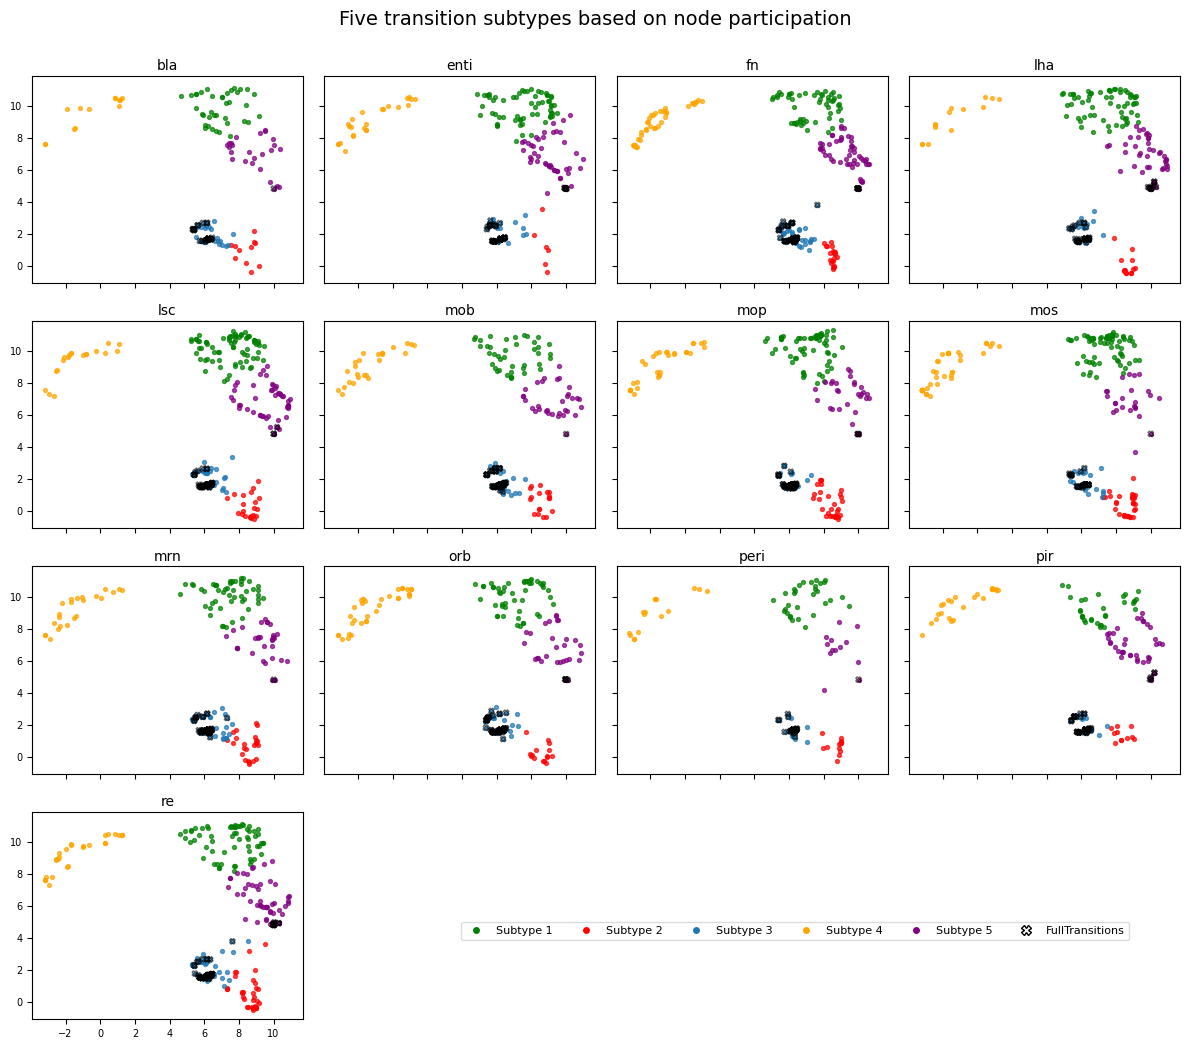

In [10]:
# supplementary 4.1
n_networks = len(embeddings)
n_cols = 4  # number of plots per row
n_rows = 4

# Standard A4 Landscape dimensions in inches: 11.69 x 8.27
# (Use figsize=(8.27, 11.69) if you prefer Portrait orientation)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (embed, labels, ax, f_embed) in enumerate(zip(embeddings, network_labels, axes, full_embeddings)):
    for cluster_id in np.unique(labels):
        cluster_points = embed[labels == cluster_id]
        # Scaled down marker size for A4 (from 60 to 12)
        ax.scatter(cluster_points[:,0], cluster_points[:,1],
                   c=colors[cluster_id], s=8, alpha=0.7)
        
    # Scaled down full embedding marker size (from 120 to 30)
    ax.scatter(f_embed[:,0], f_embed[:,1], s=15, marker='X', facecolors='none', edgecolors='k', alpha=0.6)

    # Subplot Titles (Scaled down to 10pt)
    network_name = Path(file_full[i]).stem.rsplit("_", 1)[-1]
    ax.set_title(f"{network_name}", fontsize=10, pad=4)
    
    # Tick Labels (Scaled down to 7pt)
    ax.tick_params(axis='both', labelsize=7)

# Hide unused axes if networks < n_rows*n_cols
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# Main Figure Title: Scaled down to 14pt (bold) for A4 paper size
fig.suptitle("Five transition subtypes based on node participation", fontsize=14, y=0.93)

legend_handles = []

legend_handles = []

for cluster_id in sorted(colors.keys()):
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=colors[cluster_id], 
               markersize=6, label=f'Subtype {cluster_id + 1}')
    )
legend_handles.append(
    Line2D([0], [0], marker='X', color='w', 
           markerfacecolor='none', markeredgecolor='k', 
           markersize=7, label='FullTransitions')
)
fig.legend(
    handles=legend_handles,
    loc='lower right',
    bbox_to_anchor=(0.95, 0.15), 
    ncol=len(legend_handles),  # Dynamically sets columns to make it landscape
    fontsize=8,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray'
)
# ---------------------------------------------------------

plt.tight_layout(rect=[0, 0.06, 1, 0.93], h_pad=1.2, w_pad=1.2)

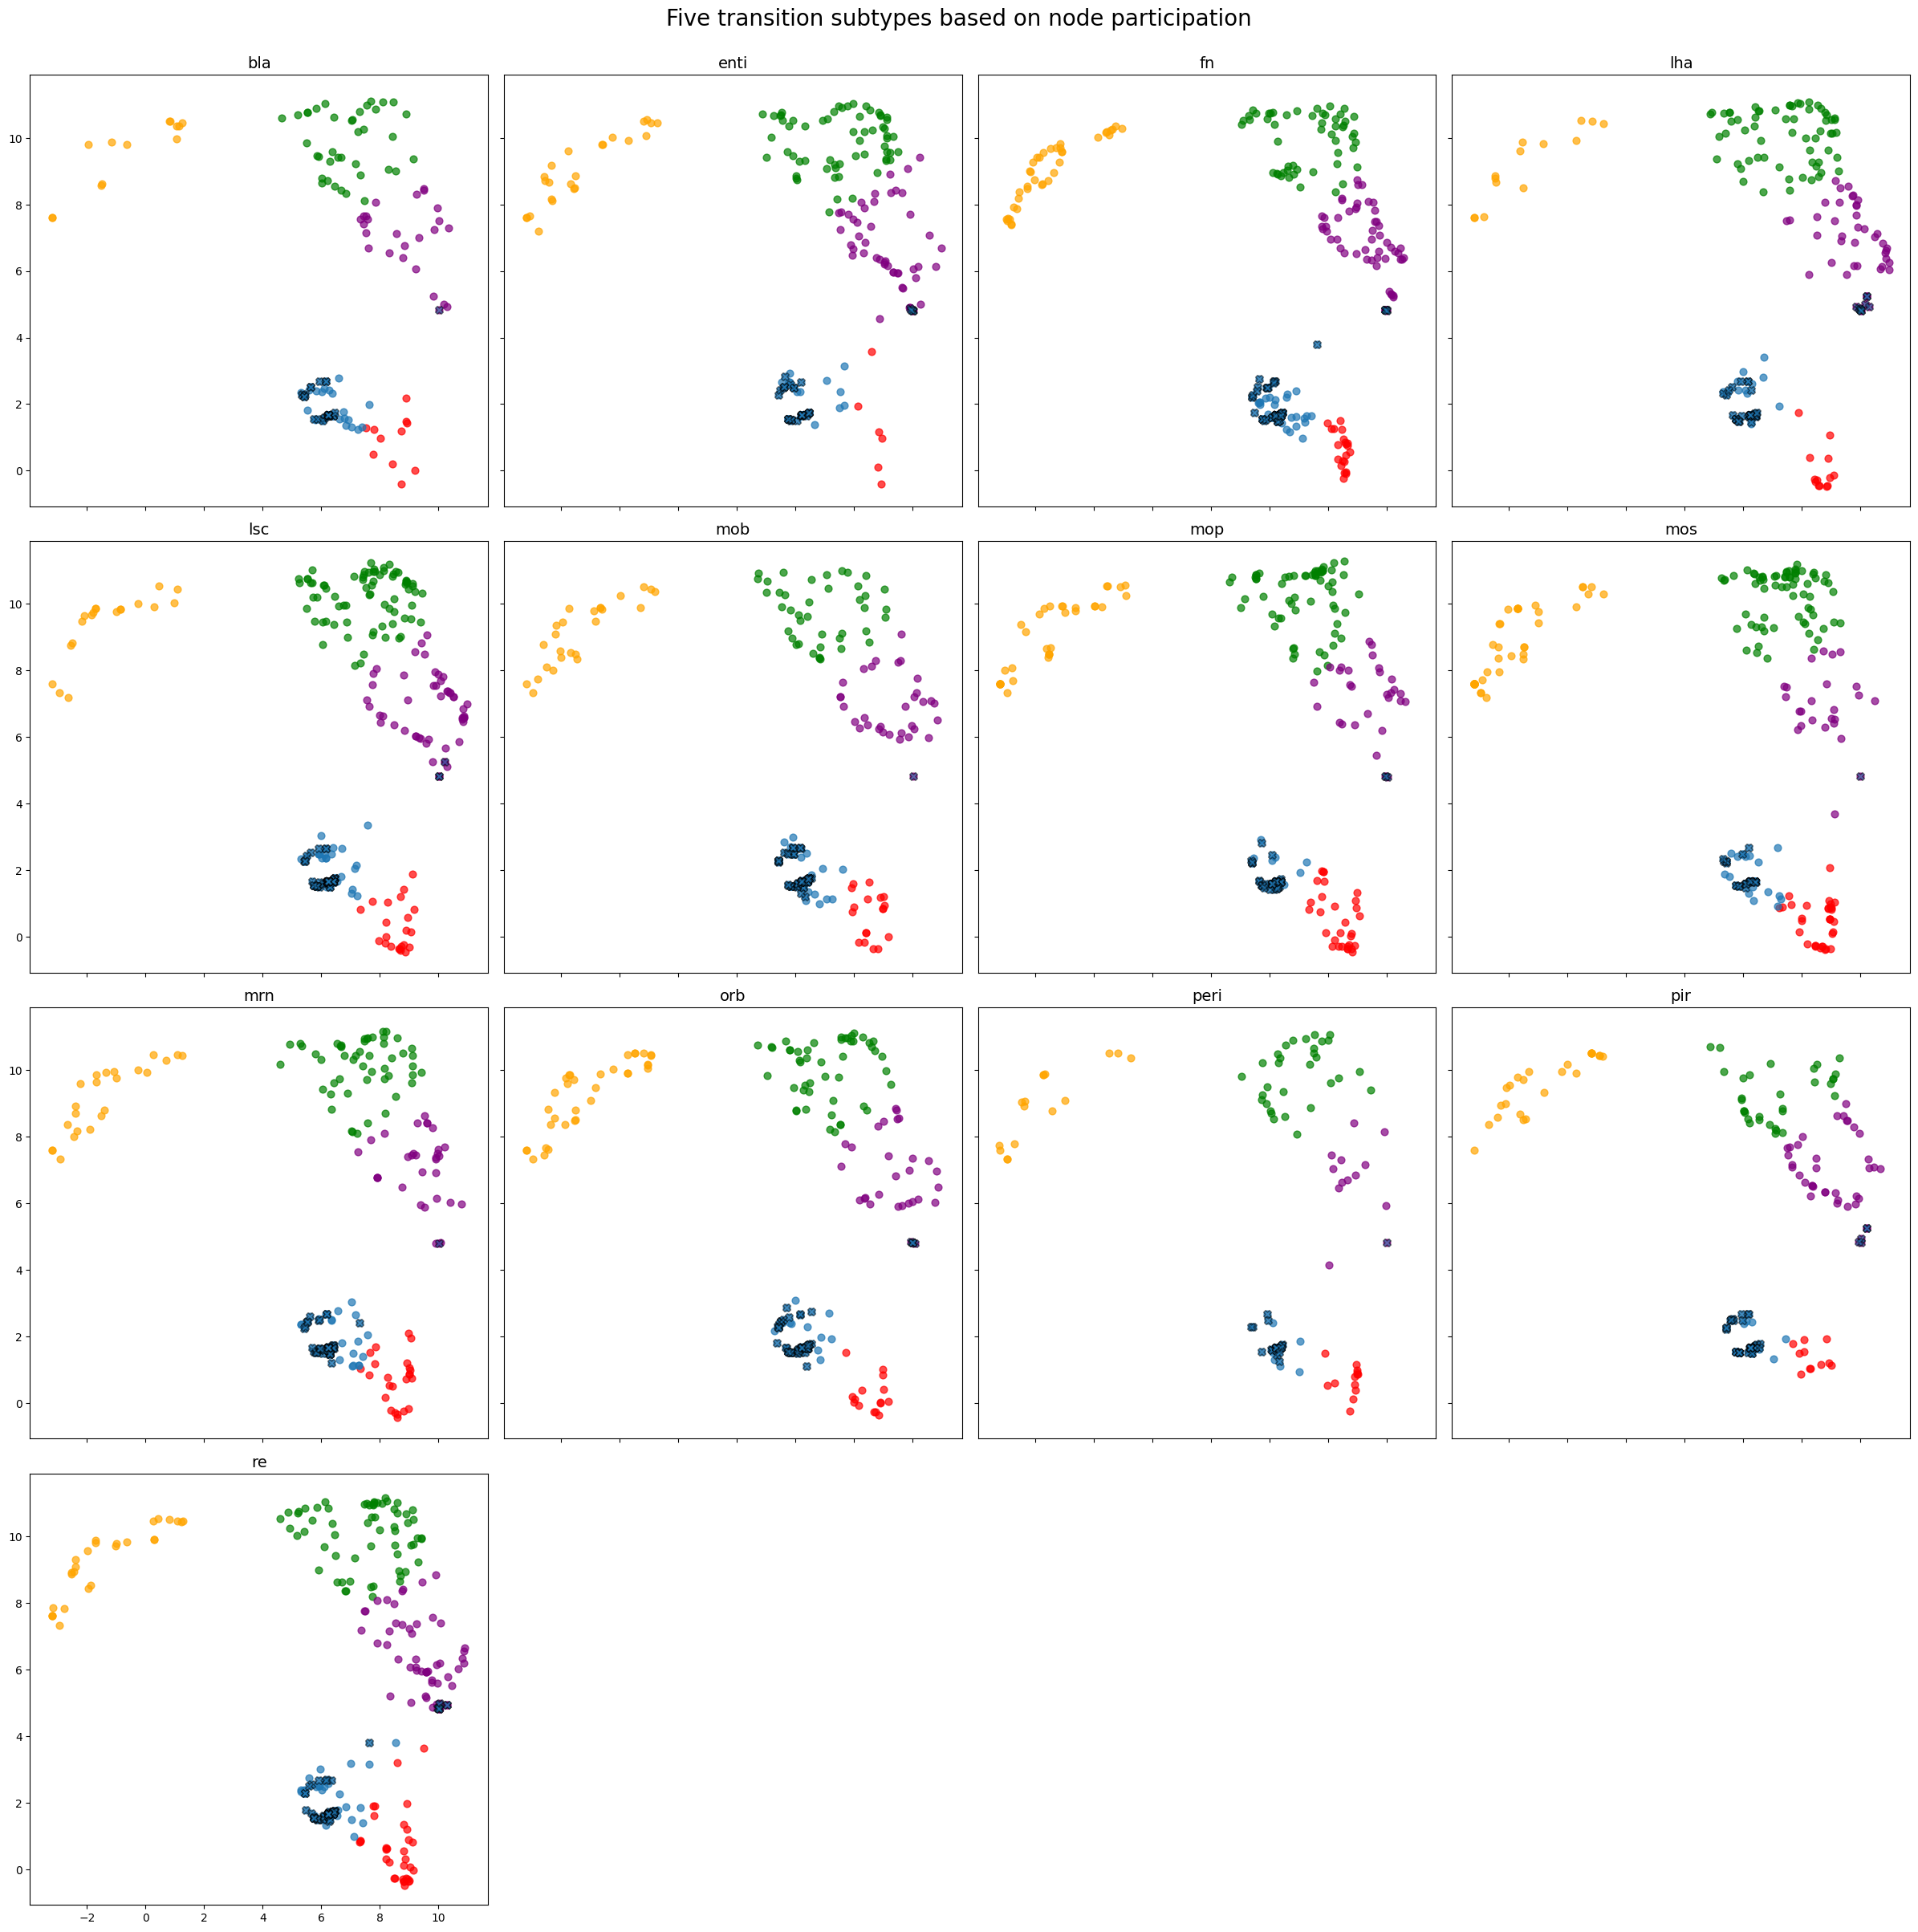

In [10]:
n_networks = len(embeddings)
n_cols = 4  # number of plots per row
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows), sharex=True, sharey=True)

axes = axes.flatten()

for i, (embed, labels, ax, f_embed) in enumerate(zip(embeddings, network_labels, axes, full_embeddings)):
    for cluster_id in np.unique(labels):
        cluster_points = embed[labels == cluster_id]
        ax.scatter(cluster_points[:,0], cluster_points[:,1],
                   c=colors[cluster_id], s=40, alpha=0.7)
        
        
    # ax.scatter(ref_centroids[:,0], ref_centroids[:,1],
    #            c="gray", marker="X", s=300)
    
    # plot full embedding to see where it lies
    ax.scatter(f_embed[:,0],f_embed[:,1], s=50,marker='X',facecolors=None,edgecolors='k', alpha=0.5)

    network_name = Path(file_full[i]).stem.rsplit("_", 1)[-1]
    ax.set_title(f"{network_name}", fontsize=14)

# Hide unused axes if networks < n_rows*n_cols
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# plt.suptitle("UMAP Embeddings with Consistent KMeans Clusters", fontsize=5)
fig.suptitle("Five transition subtypes based on node participation", fontsize=20,y=1.001)
plt.tight_layout()
# plt.savefig('../../data/results/fig_5_clusters.pdf',format='pdf')


Find the ratio of points in a specific cluster to all the points in the partial network

In [11]:
# df_par= reader.data_read_bz2('raw/workstation/pca_results/pca_part_df_fn')
# df_full=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_fn')

def compute_cluster_count_ratio(df_par,network):

    # removing NaN if any 
    df_par.dropna(inplace=True)

    embedding_part = _reducer.transform(df_par.values)
    part_network_labels = assign_clusters(embedding_part,ref_centroids)
    # print(len(part_network_labels))

    # Assigning cluster labels to data points

    df_embed = pd.DataFrame(embedding_part)

    df_embed['cluster'] = part_network_labels

    df_count = df_embed.groupby('cluster').count()
    cluster_count = df_count[0]
    # print(cluster_count)
    total_count = df_count.sum()[0]
    # print(total_count)
    ratio=cluster_count/total_count
    ratio=ratio.to_frame()
    ratio.columns=[network]
    return ratio


In [12]:
df_cluster_count = pd.DataFrame()
for f_part in file_part:
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    # print(f_part)
    data_part = compute_cluster_count_ratio(df_part,f_part.split('_')[-1])
    df_cluster_count=pd.concat([df_cluster_count,data_part],axis=1)
df_cluster_count

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.355140,0.410596,0.284946,0.450000,0.401070,0.310606,0.390244,0.370968,0.344595,0.360294,0.397436,0.290909,0.315
1,0.102804,0.039735,0.112903,0.092857,0.117647,0.136364,0.182927,0.177419,0.162162,0.110294,0.166667,0.100000,0.165
2,0.196262,0.086093,0.129032,0.085714,0.122995,0.121212,0.054878,0.086022,0.128378,0.080882,0.076923,0.072727,0.140
3,0.121495,0.158940,0.204301,0.100000,0.101604,0.189394,0.207317,0.236559,0.155405,0.250000,0.205128,0.218182,0.135
4,0.224299,0.304636,0.268817,0.271429,0.256684,0.242424,0.164634,0.129032,0.209459,0.198529,0.153846,0.318182,0.245


Save above dataframe for data of fig4B plot  
- results/figures/fig4b_data.pkl

In [ ]:
# df_cluster_count.to_pickle('../../data/results/figures/fig4b_data.pkl',compression='bz2')

Text(0, 0.5, 'ratio')

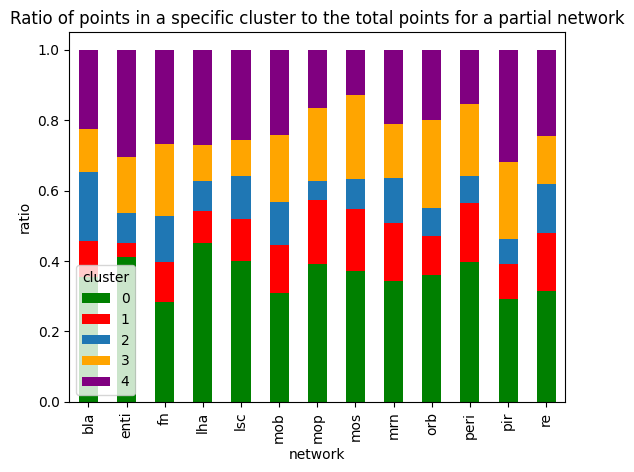

In [13]:

df_cluster_count.T.plot(kind='bar',color=colors, stacked=True)
plt.title('Ratio of points in a specific cluster to the total points for a partial network')
plt.xlabel('network')
plt.ylabel('ratio')

Find ratio of full to partial in a given cluster for a specific network

In [14]:
# df_par= reader.data_read_bz2('raw/workstation/pca_results/pca_part_df_fn')
# df_full=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_fn')

def compute_full_part_ratio(df_full,df_par,network):
    expected_clusters=[0,1,2,3,4]
    df_par.dropna(inplace=True)
    df_combined = pd.concat([df_full,df_par],axis=0)

    embedding_full=_reducer.transform(df_full.values)
    embedding_part = _reducer.transform(df_par.values)

    whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)

    # assign cluster labels
    whole_cluster_labels = assign_clusters(whole_embedding,ref_centroids)

    df_embed = pd.DataFrame(whole_embedding)
    df_embed['cluster']=whole_cluster_labels

    df_full_cluster = df_embed.iloc[0:df_full.shape[0]]
    df_full_cluster_count = df_full_cluster.groupby('cluster').count()
    fc_count = df_full_cluster_count[0].to_frame()
    fc_count=fc_count.reindex(expected_clusters,fill_value=0)
    # print(fc_count)


    df_part_cluster = df_embed.iloc[df_full.shape[0]:]
    df_part_cluster_count = df_part_cluster.groupby('cluster').count()
    fp_count = df_part_cluster_count[0].to_frame()
    fp_count=fp_count.reindex(expected_clusters,fill_value=0)
    # print(fp_count)

    ratio = (fc_count/fp_count) # ratio of full to partial
    ratio_full_tot =fc_count/(fc_count+fp_count) # ratio of full to total
    ratio.columns=[network]
    ratio_full_tot.columns=[network]
    # return ratio
    return {'ratio':ratio,'r_f_t':ratio_full_tot}
# ratio.columns=[network]



In [15]:
df_parfull_ratio = pd.DataFrame()
# dataframe for full to total ratio
df_fulltot_ratio=pd.DataFrame()
for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    # df_part.dropna(inplace=True)
    # print(f_part)
    data = compute_full_part_ratio(df_full,df_part,f_part.split('_')[-1])
    data_part=data['ratio']
    df_parfull_ratio=pd.concat([df_parfull_ratio,data_part],axis=1)

    data_full=data['r_f_t']
    df_fulltot_ratio=pd.concat([df_fulltot_ratio,data_full],axis=1)
df_parfull_ratio

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2.380952,3.923077,4.041667,3.666667,4.086957,5.81250,7.666667,2.562500,4.105263,8.090909,7.666667,7.750000,2.964286
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.041667,0.130435,0.120000,0.289474,0.062500,0.03125,0.111111,0.041667,0.032258,0.185185,0.083333,0.142857,0.183673


plot full to partial ratio

Text(0, 0.5, 'ratio')

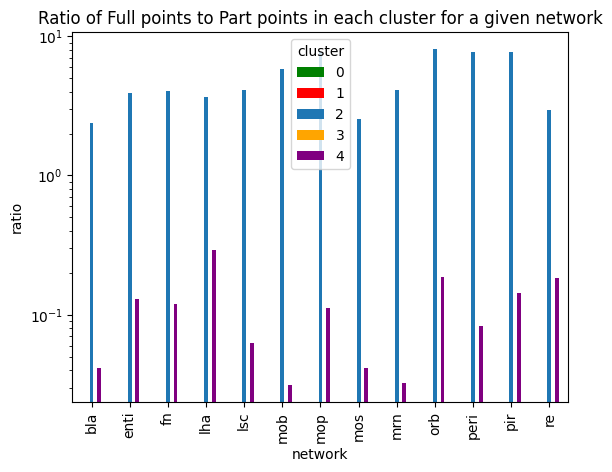

In [16]:

df_parfull_ratio.T.plot(kind='bar',color=colors,logy=True)
plt.title('Ratio of Full points to Part points in each cluster for a given network')
plt.xlabel('network')
plt.ylabel('ratio')

plot full to total ratio

In [32]:
df_fulltot_ratio['fn'].T

cluster
0    0.000000
1    0.000000
2    0.801653
3    0.000000
4    0.107143
Name: fn, dtype: float64

Text(0, 0.5, 'ratio')

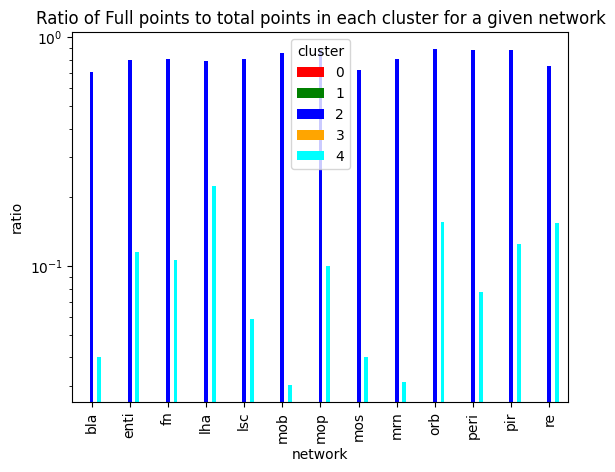

In [17]:
df_fulltot_ratio.T.plot(kind='bar',color=colors,logy=True)
plt.title('Ratio of Full points to total points in each cluster for a given network')
plt.xlabel('network')
plt.ylabel('ratio')

Save full to total

In [29]:
df_fulltot_ratio

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
2,0.704225,0.796875,0.801653,0.785714,0.803419,0.853211,0.884615,0.719298,0.804124,0.89000,0.884615,0.885714,0.747748
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
4,0.040000,0.115385,0.107143,0.224490,0.058824,0.030303,0.100000,0.040000,0.031250,0.15625,0.076923,0.125000,0.155172


In [28]:
df_fulltot_ratio.to_pickle('../../data/results/figures/fig5a_data.pkl',compression='bz2')

Find cluster community wise mean

In [17]:

def compute_cluster_comm_partcptn(df_f,df_p,n):
    df_p.dropna(inplace=True)
    df_combined = pd.concat([df_f,df_p],axis=0)
    # print(df_f.shape)
    # print(df_p.shape)
    # print(df_combined.shape)

    df_combined['cluster']=network_labels[n]
    # print(df_combined.shape)

    # removing df_full rows from combined
    df_work=df_combined.iloc[df_f.shape[0]:,:]
    # print(df_work.shape)
    # df_work.head()

    # take average clusterwise for each column

    communities = list(df_work.columns[:-1])
    # print(communities)
    cluster_data = pd.DataFrame()
    for comm in communities:
        # print(comm)
        df_cluster = df_work.groupby('cluster')[comm].mean()
        cluster_data=pd.concat([cluster_data,df_cluster],axis=1)

    # Plot bar chart using cluster data
    # take avg of each cluster excluding hind
    # print(cluster_data)
    avg_0 = cluster_data.loc[0][:-1].mean()
    avg_1 = cluster_data.loc[1][:-1].mean()
    avg_2 = cluster_data.loc[2][:-1].mean()

    # comment when using 3 clusters only
    avg_3 = cluster_data.loc[3][:-1].mean()
    avg_4 = cluster_data.loc[4][:-1].mean()

    # Normalizing each cluster 
    c_0 = cluster_data.loc[0]/avg_0
    c_1 = cluster_data.loc[1]/avg_1
    c_2 = cluster_data.loc[2]/avg_2

    # comment when using 3 clusters
    c_3 = cluster_data.loc[3]/avg_3
    c_4 = cluster_data.loc[4]/avg_4

    # print(cluster_data.head(3))
    # Updating cluster data to plot
    cluster_data.loc[0]=c_0
    cluster_data.loc[1]=c_1
    cluster_data.loc[2]=c_2

    # comment when using 3 clusters
    cluster_data.loc[3]=c_3
    cluster_data.loc[4]=c_4
    
    # cluster_data.head(3)
    cluster_plot = cluster_data.copy()

    # cluster_plot.head()
    # print(cluster_plot)
    return cluster_plot
    



Supplementary 4.6

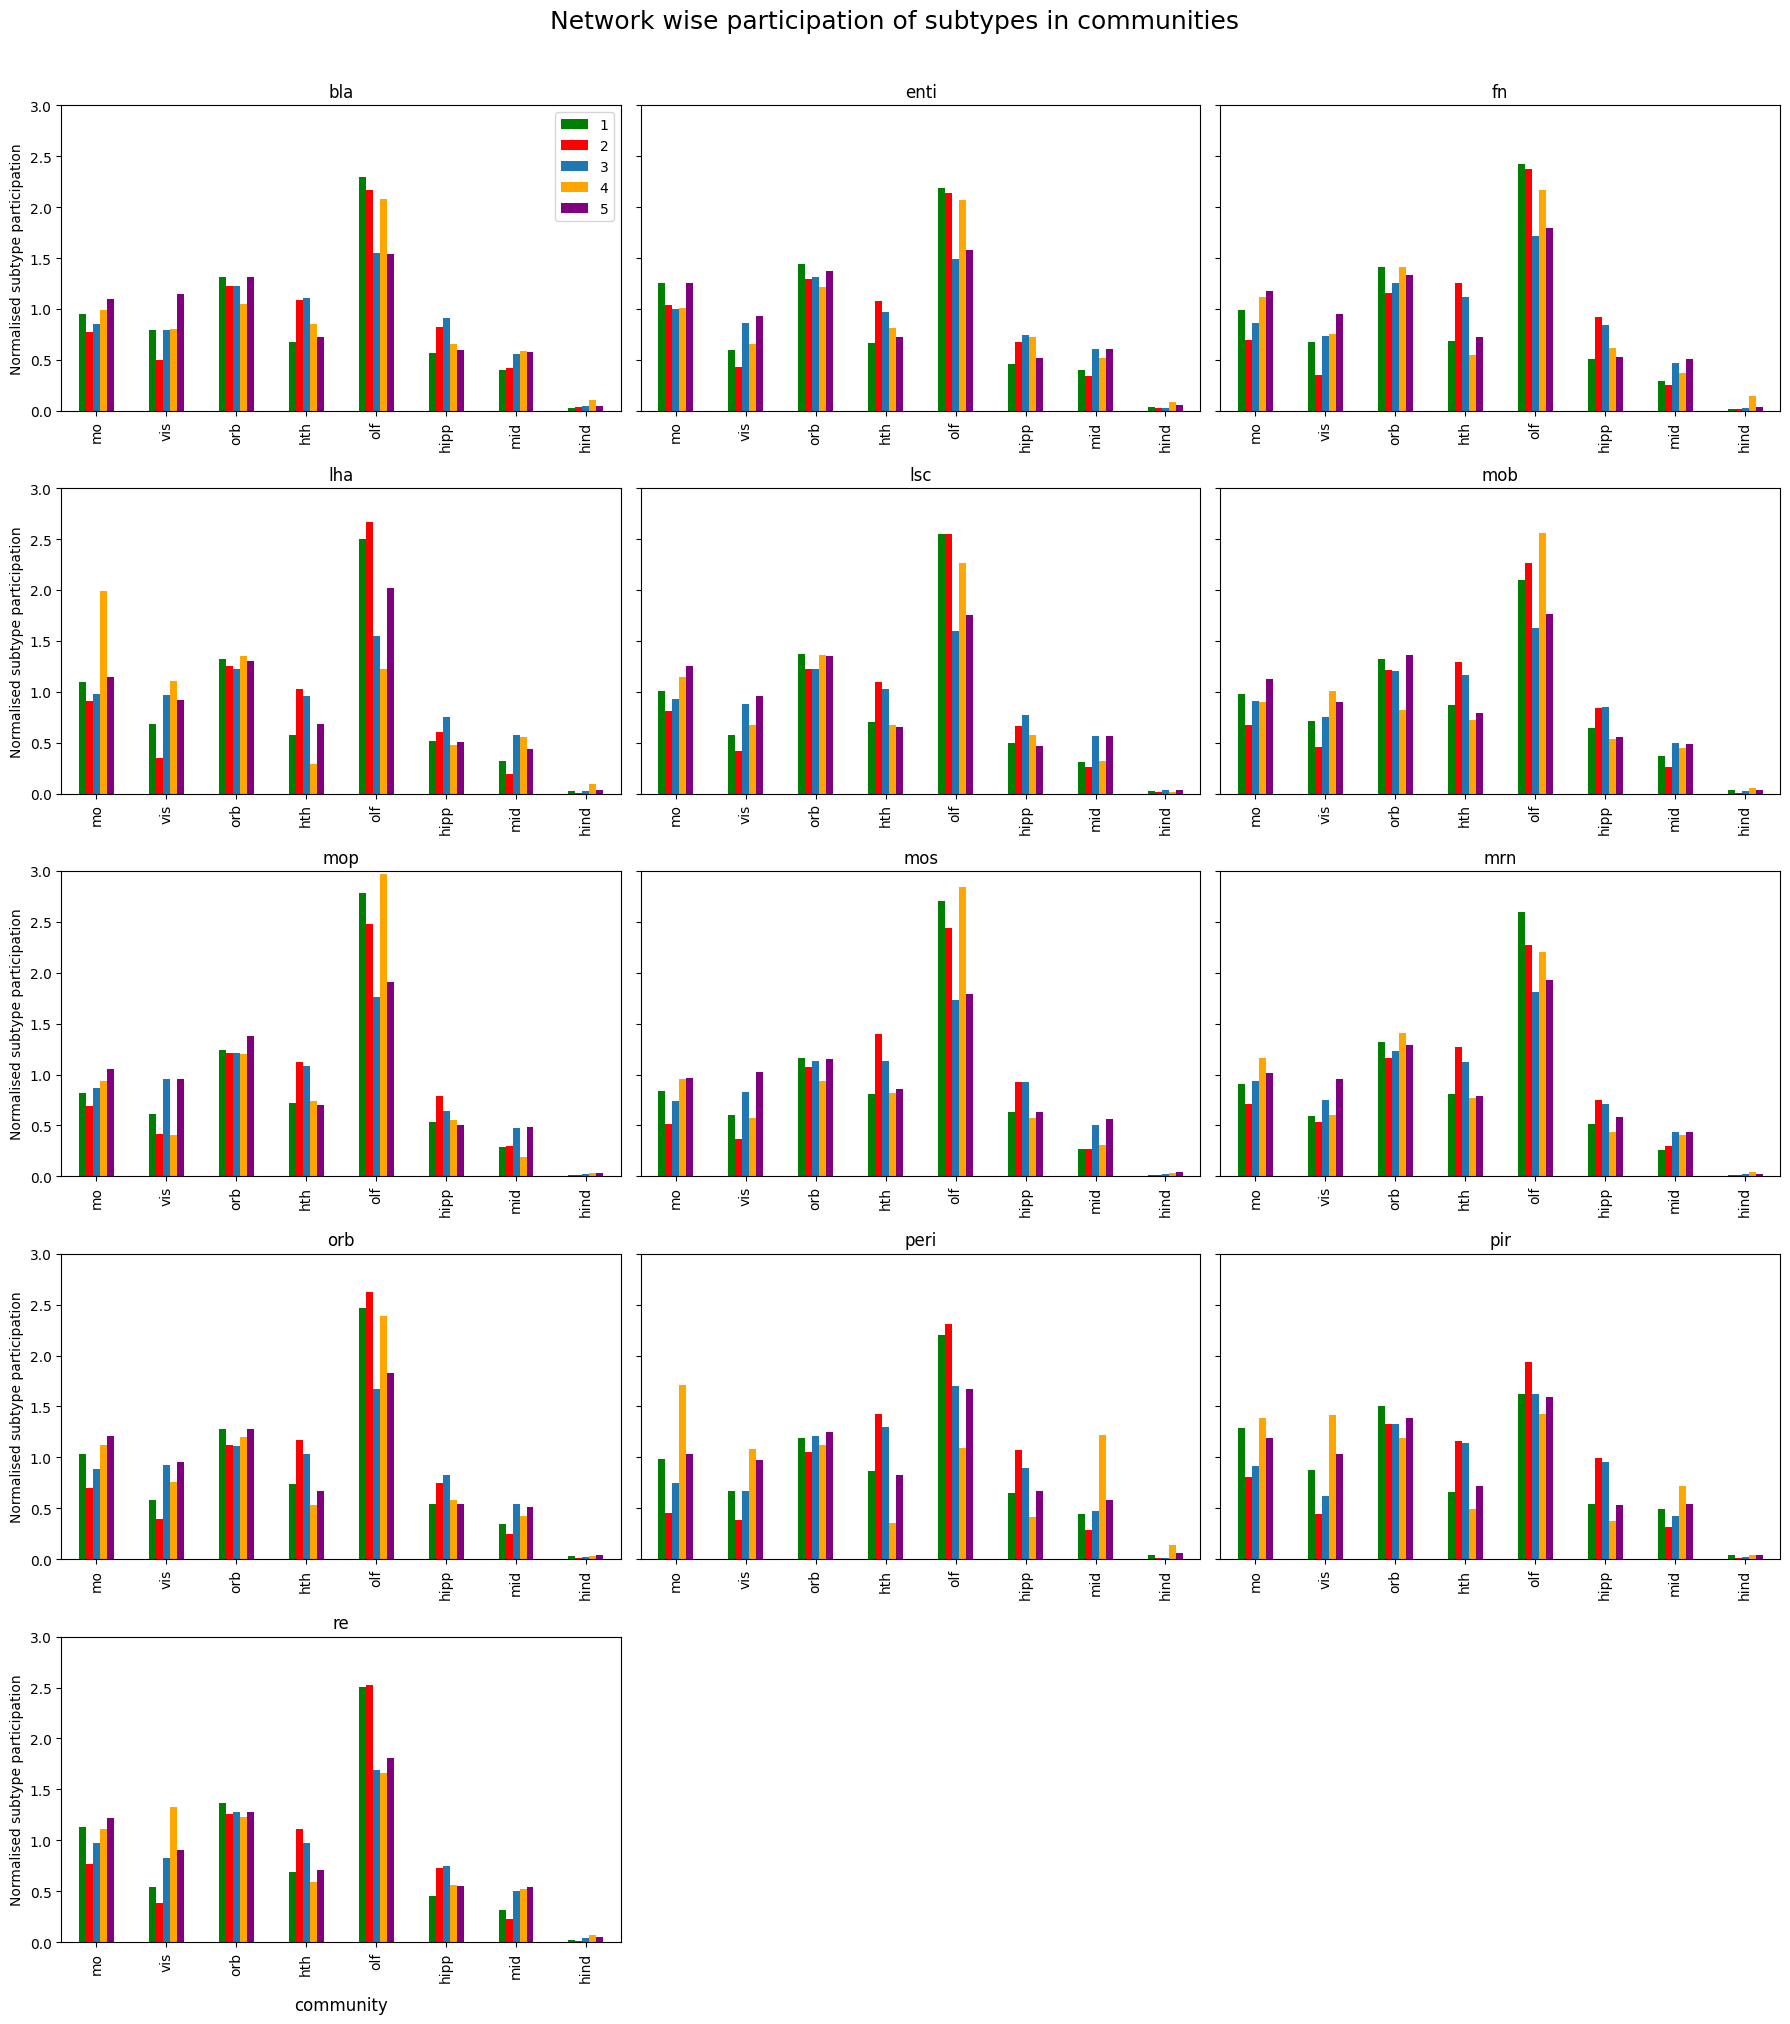

In [20]:
import math
import matplotlib.pyplot as plt
import pandas as pd

n_files = len(file_full)   # should be 13
n_cols = 3                 # number of columns you want
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

cluster_colors = {1: "green", 2: "red", 3: "C0", 4: "orange", 5: "purple"}
data_dict = {}

for n, (f_full, f_part, ax) in enumerate(zip(file_full, file_part, axes)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    
    # set cluster labels explicitly
    clusterData.index = [1, 2, 3, 4, 5]
    
    # plot
    plot_obj = clusterData.T.plot(
        kind='bar',
        ax=ax,
        color=[cluster_colors.get(c, "gray") for c in clusterData.T.columns],
        legend=(n == 0)   # legend only for the first subplot
    )
    
    # Only set 'community' label on the very last valid file subplot
    if n == n_files - 1:
        ax.set_xlabel('community', fontsize=12, labelpad=10)
    else:
        ax.set_xlabel('')
        
    # Keep y-label and y-tick labels ONLY for the left-most plots (Column 0)
    if n % n_cols == 0:
        ax.set_ylabel('Normalised subtype participation')
    else:
        ax.set_ylabel('')          # Remove y-axis title string
        ax.set_yticklabels([])     # Remove y-tick text labels (numbers)

    ax.set_ylim(0, 3)
    ax.set_title(file_full[n].split('_')[-1])

    # flatten with MultiIndex labels
    labels = [(comm, clus) for comm in clusterData.index for clus in clusterData.columns]
    cl_data = pd.Series(clusterData.values.flatten(), index=pd.MultiIndex.from_tuples(labels))
    nw = file_full[n].split('_')[-1]
    data_dict[nw] = cl_data

# Hide unused subplots completely from the canvas
for ax in axes[n_files:]:
    ax.set_visible(False)

plt.suptitle('Network wise participation of subtypes in communities', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

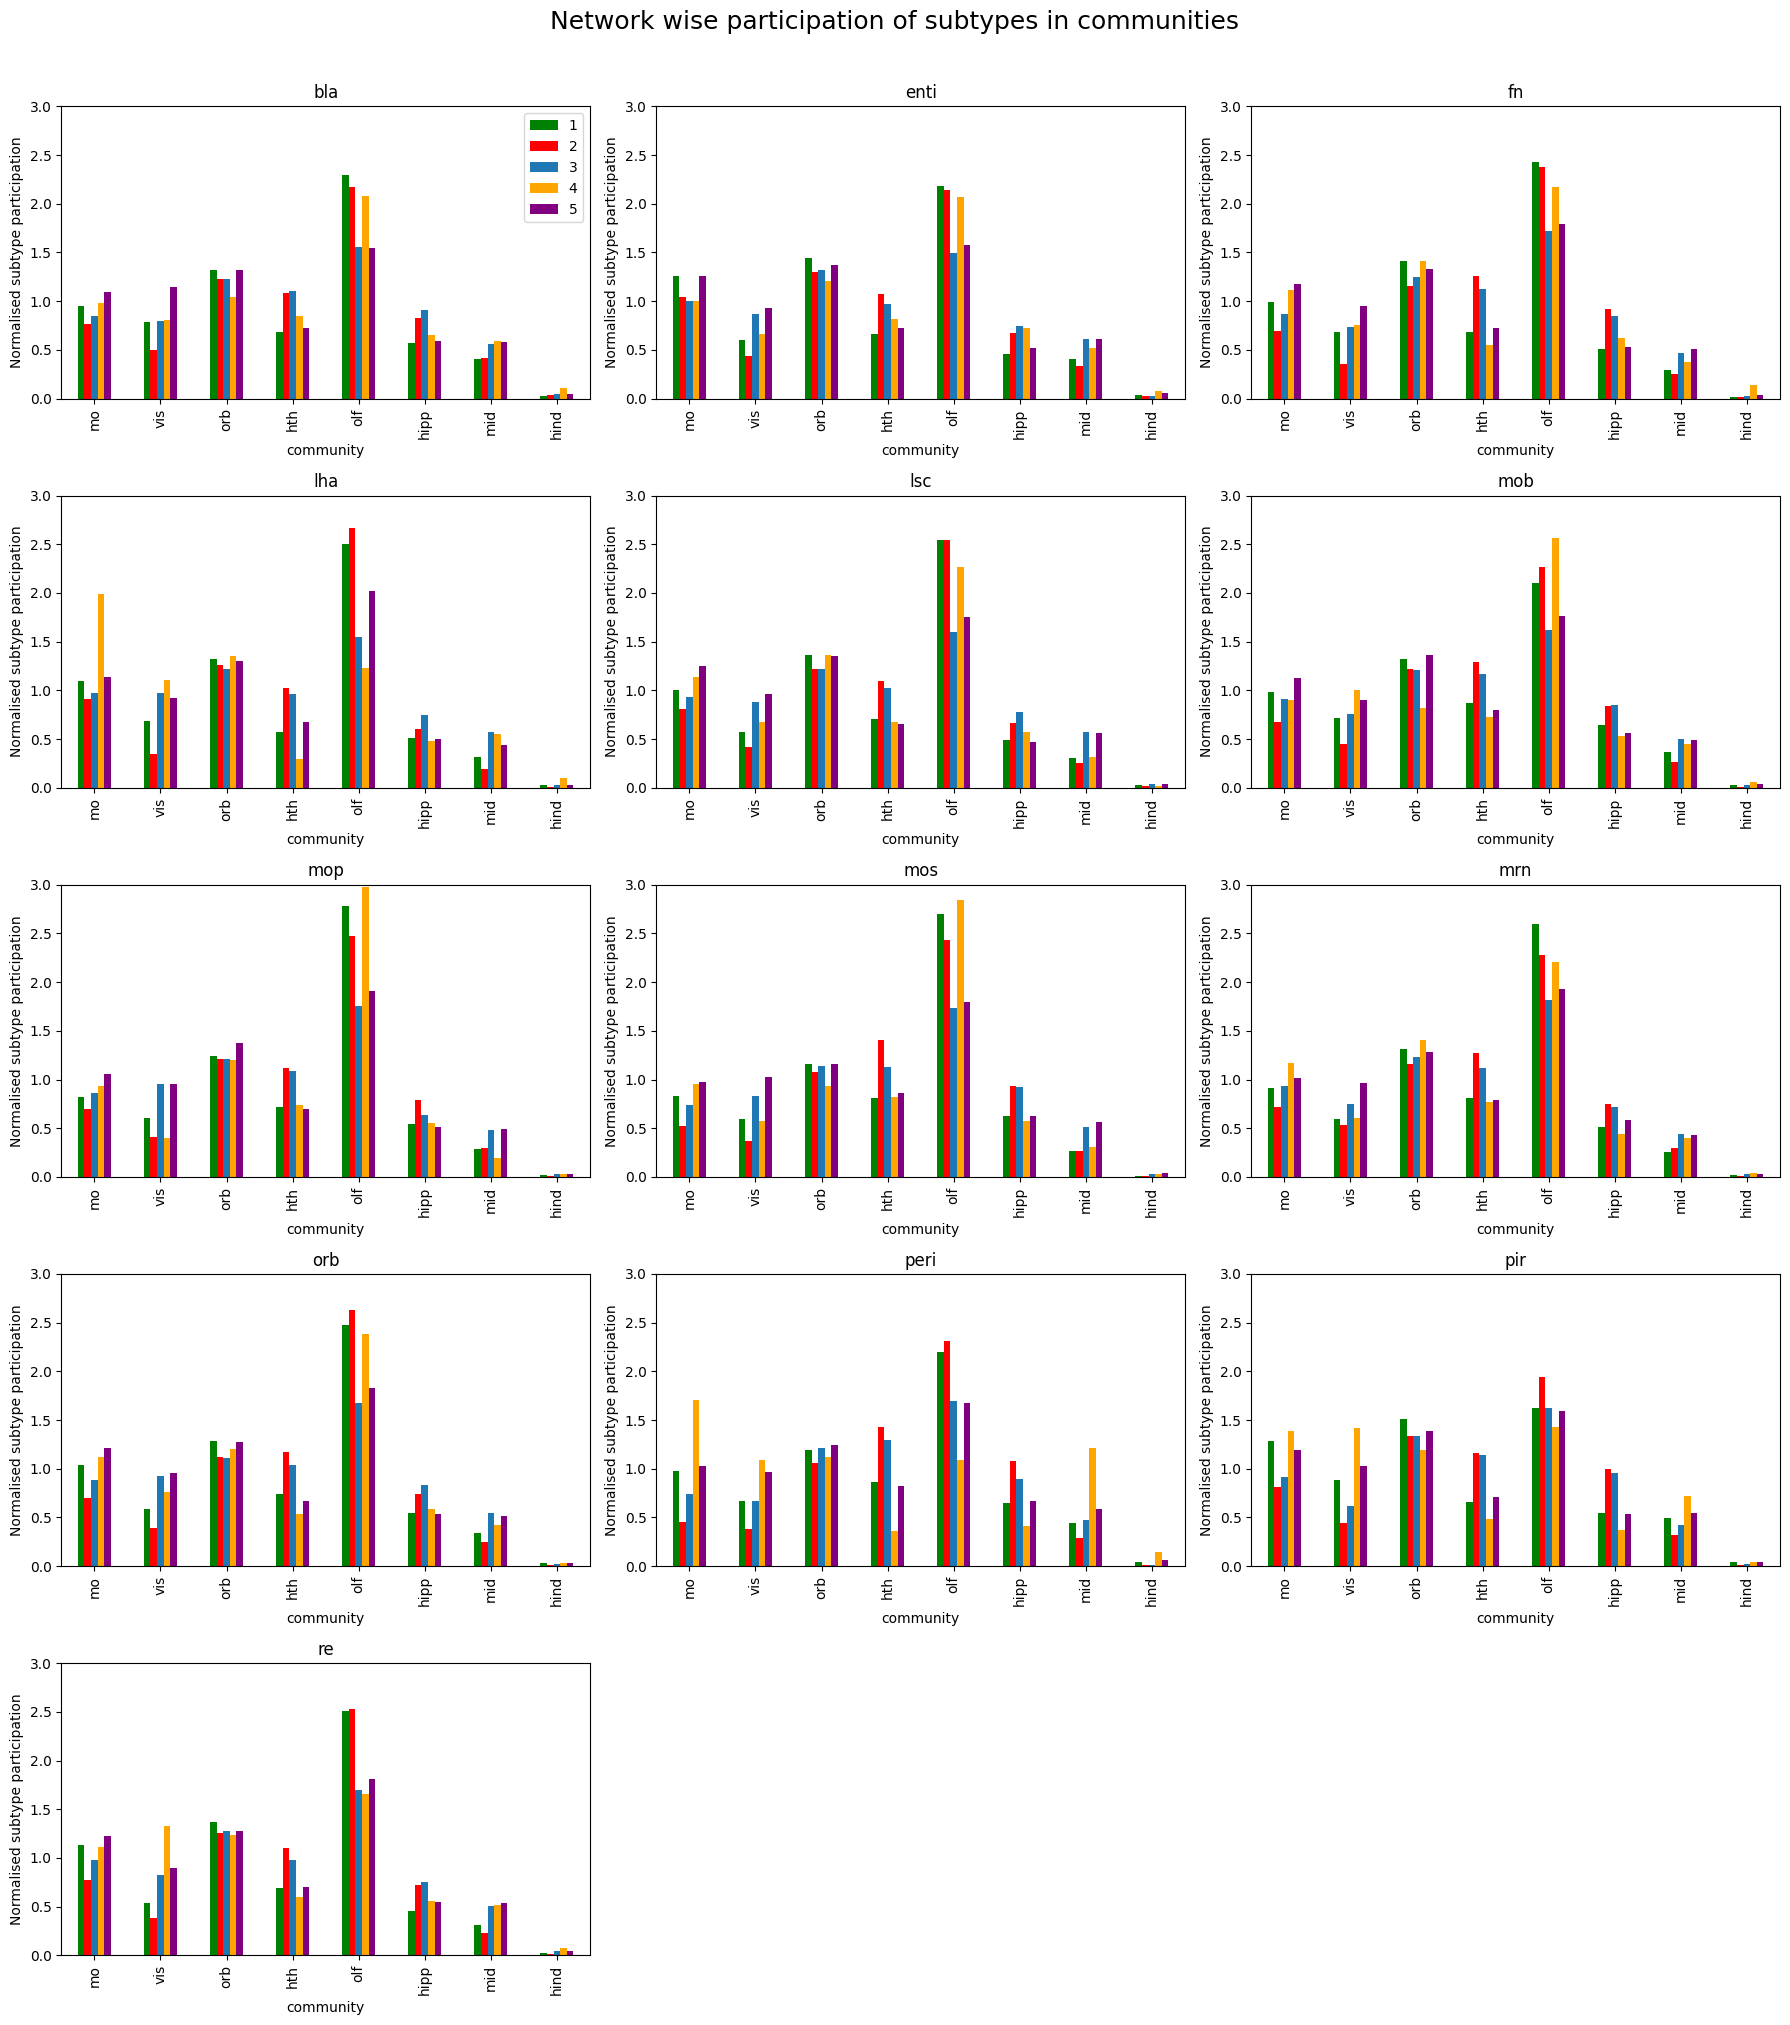

In [18]:
import math
import matplotlib.pyplot as plt
import pandas as pd

n_files = len(file_full)   # should be 13
n_cols = 3                 # number of columns you want
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

cluster_colors = {1: "green", 2: "red", 3: "C0", 4: "orange", 5: "purple"}
data_dict = {}

for n, (f_full, f_part, ax) in enumerate(zip(file_full, file_part, axes)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    
    # set cluster labels explicitly
    clusterData.index = [1, 2, 3, 4, 5]
    
    # plot
    plot_obj = clusterData.T.plot(
        kind='bar',
        ax=ax,
        color=[cluster_colors.get(c, "gray") for c in clusterData.T.columns],
        legend=(n == 0)   # legend only for the first subplot
    )
    
    ax.set_xlabel('community')
    ax.set_ylabel('Normalised subtype participation')
    ax.set_ylim(0, 3)
    ax.set_title(file_full[n].split('_')[-1])

    # flatten with MultiIndex labels
    labels = [(comm, clus) for comm in clusterData.index for clus in clusterData.columns]
    cl_data = pd.Series(clusterData.values.flatten(), index=pd.MultiIndex.from_tuples(labels))
    nw = file_full[n].split('_')[-1]
    data_dict[nw] = cl_data

# Hide unused subplots
for ax in axes[n_files:]:
    ax.set_visible(False)
plt.suptitle('Network wise participation of subtypes in communities',fontsize=18, y=1.01)
plt.tight_layout()
plt.show()


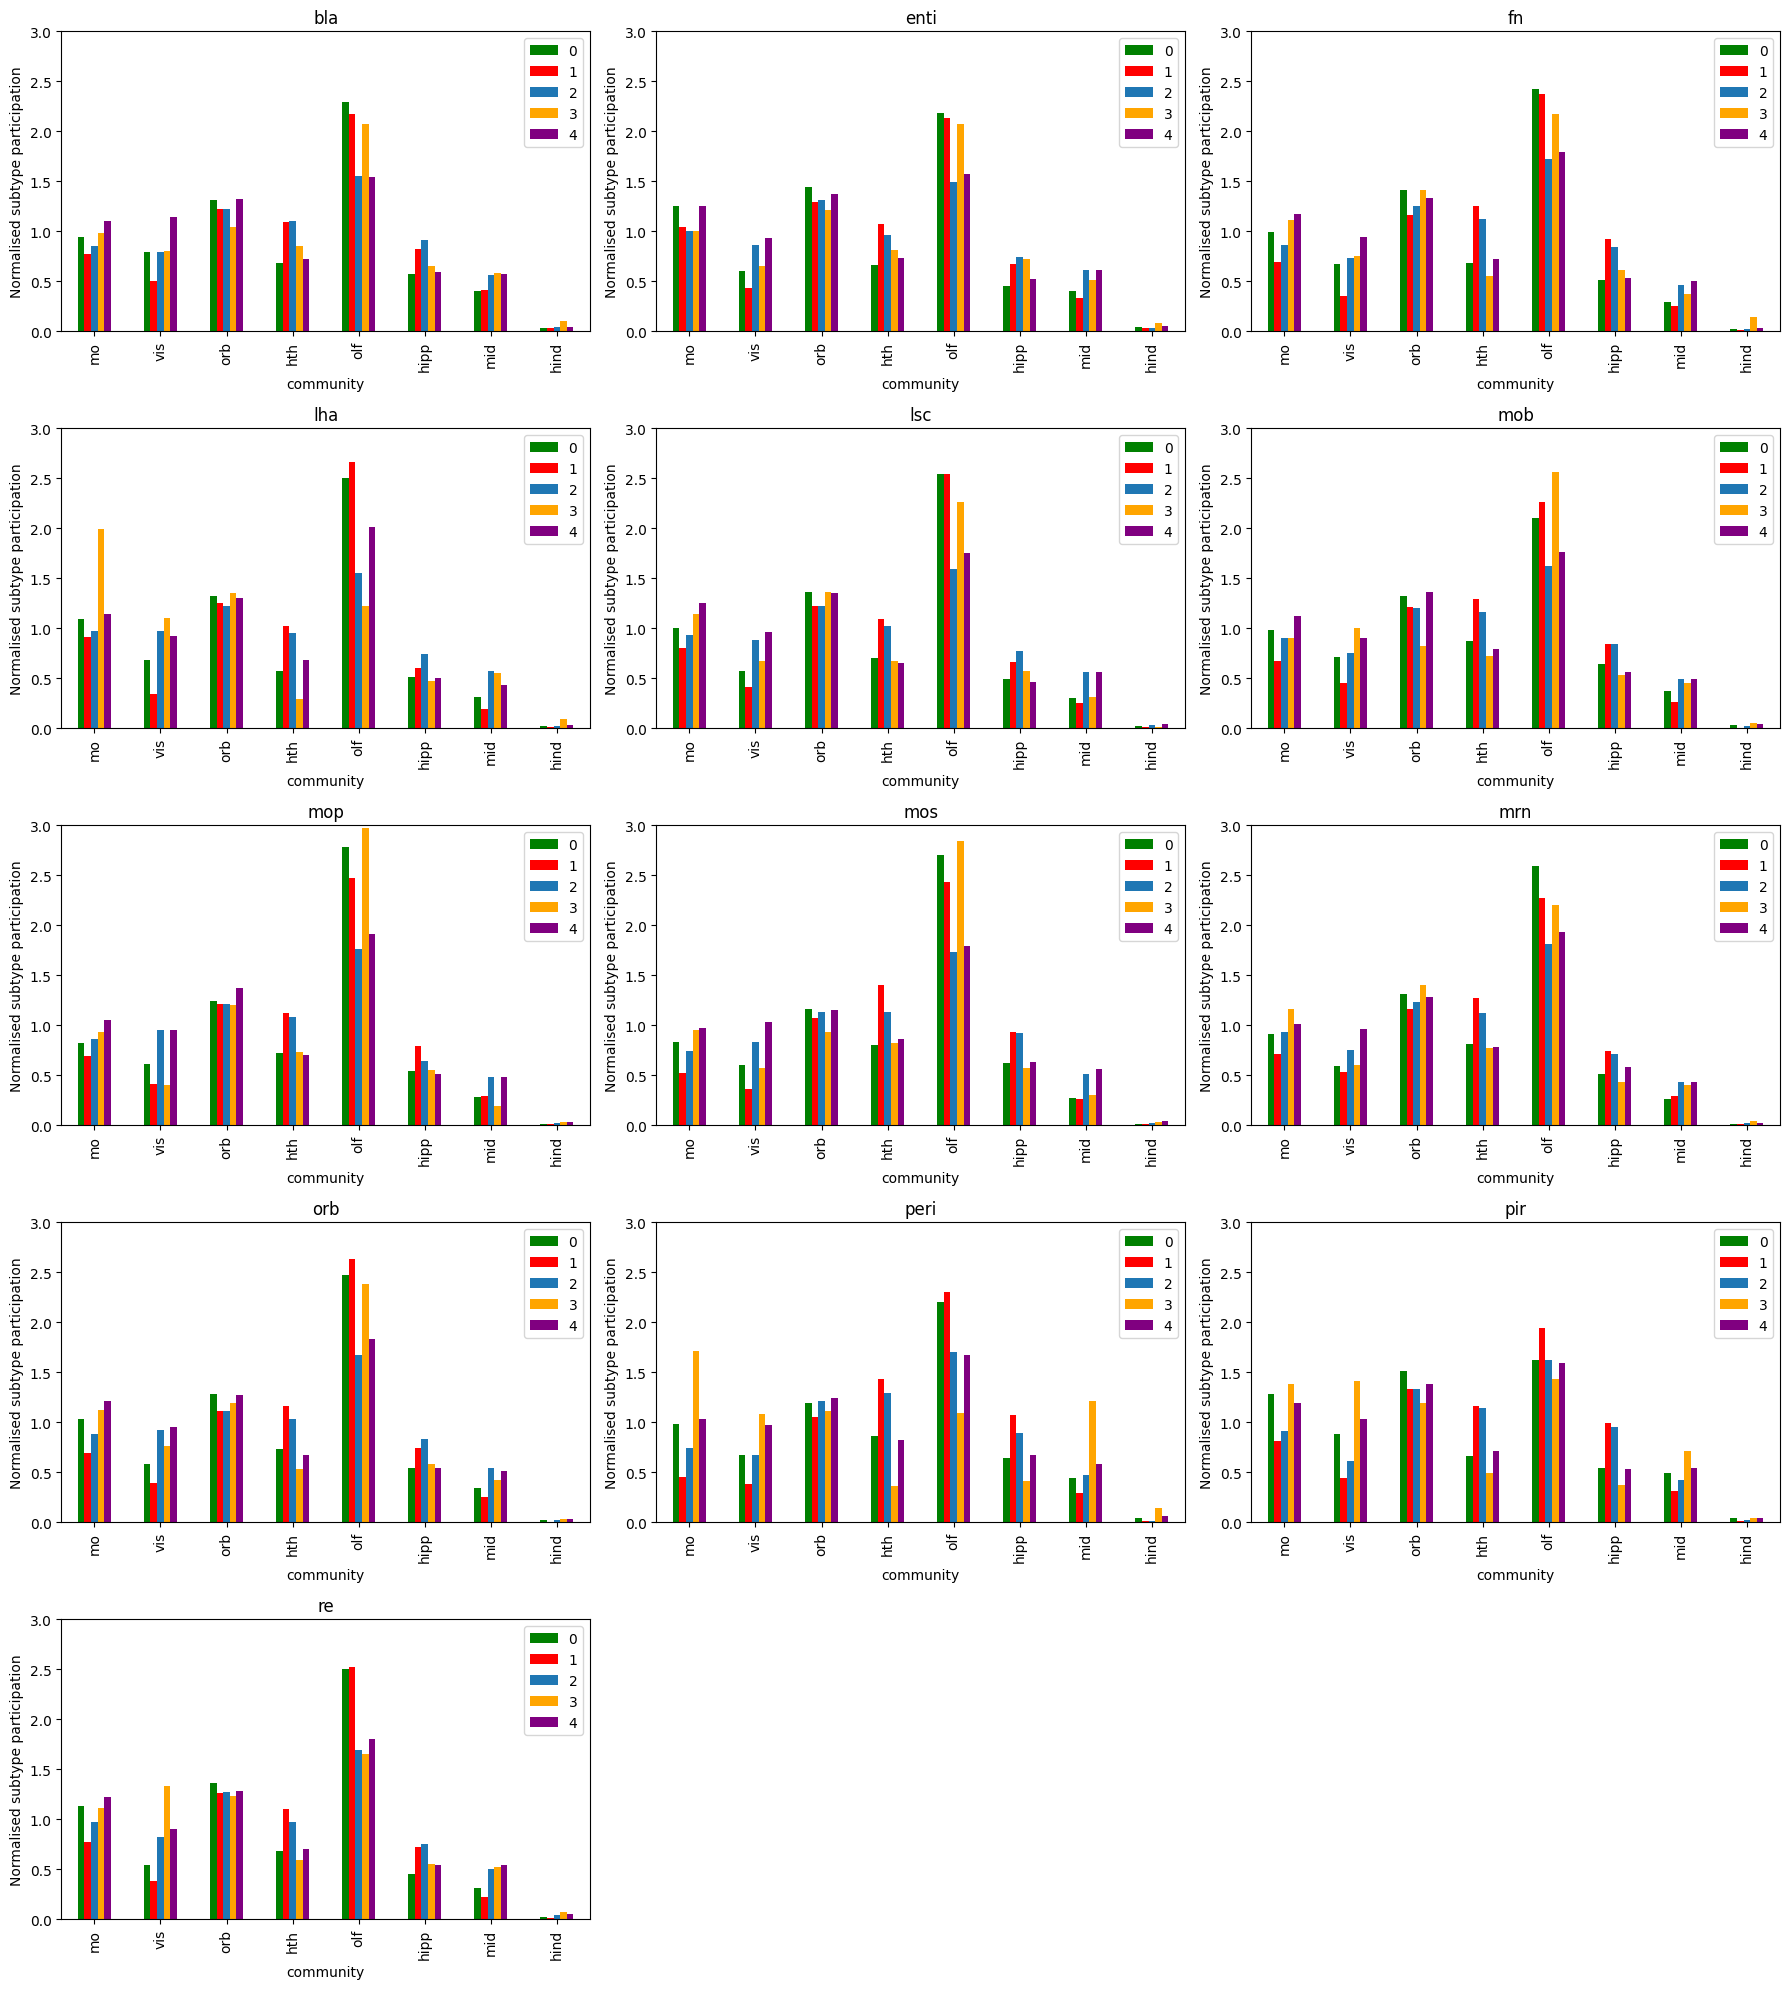

In [21]:
import math

n_files = len(file_full)   # should be 13
n_cols = 3                 # number of columns you want
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()   # flatten to 1D array for easy looping

cluster_colors =  {0: "green", 1: "red", 2: "C0",3:"orange",4:"purple"}
data_dict ={}

for n, (f_full, f_part, ax) in enumerate(zip(file_full, file_part, axes)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    
    clusterData.T.plot(
        kind='bar',
        ax=ax,
        color=[cluster_colors.get(c, "gray") for c in clusterData.T.columns]
    )
    
    ax.set_xlabel('community')
    ax.set_ylabel('Normalised subtype participation')
    ax.set_ylim(0,3)
    ax.set_title(file_full[n].split('_')[-1])

    # storing cluster data as flattened 8x5 for each network  
    # cl_data=clusterData.values.flatten()
    # nw=file_full[n].split('_')[-1]
    # data_dict[nw]=cl_data

    # with col labels
    # Create MultiIndex labels
    clusterData.index=[1,2,3,4,5]
    labels = [(comm, clus) for comm in clusterData.index for clus in clusterData.columns]
    cl_data = pd.Series(clusterData.values.flatten(), index=pd.MultiIndex.from_tuples(labels))

    nw = file_full[n].split('_')[-1]
    data_dict[nw] = cl_data


# Hide any unused subplots if n_files doesn’t fill the grid
for ax in axes[n_files:]:
    ax.set_visible(False)

plt.tight_layout()

# plt.savefig('../../data/results/fig_5_cluster_bar.pdf',format='pdf')


Make data for fig 4 D

In [25]:
df_out = pd.DataFrame.from_dict(data_dict, orient='index')
df_out.to_pickle('../../data/results/figures/fig4d_data.pkl',compression='bz2')
# convert above dataframe to ndarray and do umap/pca

In [23]:
df_out

0                                                              \
            mo       vis       orb       hth       olf      hipp       mid   
bla   0.946027  0.790222  1.315748  0.679832  2.293980  0.569710  0.404481   
enti  1.257179  0.599361  1.439222  0.661568  2.186557  0.454208  0.401906   
fn    0.993989  0.678284  1.416082  0.684669  2.423625  0.511457  0.291894   
lha   1.093092  0.685441  1.320350  0.570927  2.502703  0.512058  0.315430   
lsc   1.002861  0.575773  1.367462  0.706469  2.547664  0.492780  0.306991   
mob   0.979523  0.712642  1.321307  0.873694  2.101735  0.639470  0.371628   
mop   0.821761  0.610196  1.240884  0.723040  2.778786  0.538973  0.286359   
mos   0.835596  0.598804  1.162153  0.805413  2.700909  0.627684  0.269439   
mrn   0.911909  0.596253  1.316891  0.808545  2.593021  0.513201  0.260179   
orb   1.037653  0.582054  1.283048  0.737487  2.472195  0.546333  0.341231   
peri  0.980700  0.669339  1.193225  0.861694  2.200957  0.648167  0.445917   
pir   1.286971  0.880327  1.509181  0.660397  1.623403  0.542993  0.496729   
re    1.130122  0.540029  1.365142  0.687445  2.508249  0.454010  0.315004   

                       1            ...         3                   4  \
          hind        mo       vis  ...       mid      hind        mo   
bla   0.030669  0.769758  0.501367  ...  0.587057  0.108361  1.098843   
enti  0.041159  1.039782  0.434212  ...  0.515478  0.082343  1.255840   
fn    0.019842  0.691751  0.350546  ...  0.374762  0.142710  1.173763   
lha   0.024017  0.910082  0.345501  ...  0.553347  0.096767  1.141286   
lsc   0.024914  0.808391  0.417801  ...  0.315441  0.017996  1.251526   
mob   0.030643  0.671688  0.453883  ...  0.448612  0.058341  1.125194   
mop   0.015224  0.692878  0.412196  ...  0.192013  0.030234  1.057835   
mos   0.014000  0.518986  0.367910  ...  0.304861  0.030780  0.970222   
mrn   0.015049  0.713710  0.532160  ...  0.403055  0.041081  1.018145   
orb   0.027185  0.697519  0.396727  ...  0.421390  0.034539  1.211736   
peri  0.043353  0.457646  0.384273  ...  1.215637  0.141885  1.030980   
pir   0.038752  0.809543  0.446738  ...  0.716601  0.039305  1.194261   
re    0.024423  0.769259  0.387666  ...  0.518903  0.073115  1.222930   

                                                                            
           vis       orb       hth       olf      hipp       mid      hind  
bla   1.145185  1.318454  0.720158  1.544235  0.595067  0.578058  0.046287  
enti  0.933083  1.376045  0.728862  1.576173  0.519163  0.610834  0.055703  
fn    0.946917  1.328486  0.723473  1.790217  0.528919  0.508224  0.037680  
lha   0.921314  1.302976  0.678812  2.016950  0.501724  0.436939  0.030026  
lsc   0.961880  1.348677  0.652408  1.754532  0.466562  0.564414  0.038604  
mob   0.901966  1.365013  0.794217  1.763736  0.559007  0.490867  0.039692  
mop   0.957098  1.378036  0.701050  1.908680  0.509044  0.488258  0.029592  
mos   1.029197  1.154940  0.861050  1.791578  0.629859  0.563154  0.040951  
mrn   0.960861  1.286125  0.785019  1.933662  0.583094  0.433095  0.026338  
orb   0.955023  1.276472  0.673382  1.833163  0.539118  0.511106  0.036400  
peri  0.969549  1.245447  0.822234  1.674280  0.671363  0.586147  0.063685  
pir   1.029934  1.387789  0.714179  1.597006  0.534466  0.542364  0.044498  
re    0.899394  1.280498  0.704648  1.806134  0.546958  0.539439  0.049367  

[13 rows x 40 columns]

In [42]:
labels=list(df_out.index)
labels

['bla',
 'enti',
 'fn',
 'lha',
 'lsc',
 'mob',
 'mop',
 'mos',
 'mrn',
 'orb',
 'peri',
 'pir',
 're']

In [57]:
umap_cluster = umap.UMAP(n_neighbors=5,min_dist=0.05,n_components=2,random_state=42)


_reducer = umap_cluster.fit(df_out.values)

# transforming using reducer
clus_data_tf = _reducer.transform(df_out.values)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


do kmeans

In [70]:
kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clus_data_tf)

(7.0, 10.5)

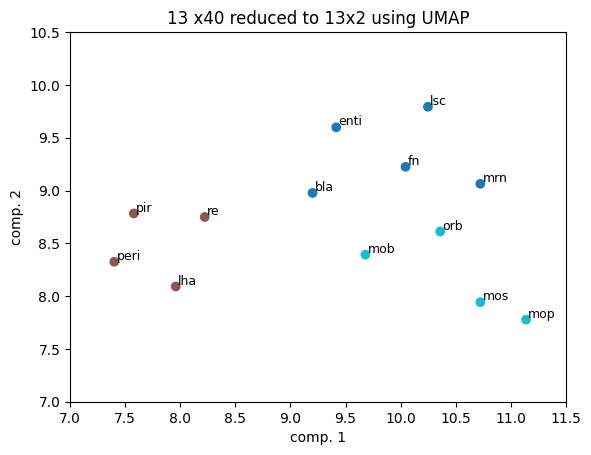

In [ ]:

plt.scatter(clus_data_tf[:,0],clus_data_tf[:,1],c=clus_pl,cmap='tab10')
for i, label in enumerate(labels):
    plt.text(clus_data_tf[i,0]+0.02, clus_data_tf[i,1]+0.02, label, fontsize=9)

plt.ylabel('comp. 2')
plt.xlabel('comp. 1')
plt.title('13 x40 reduced to 13x2 using UMAP')
plt.xlim(7,11.5)
plt.ylim(7,10.5)





Using PCA

Text(0.5, 1.0, '13 x40 reduced to 13x2 using PCA')

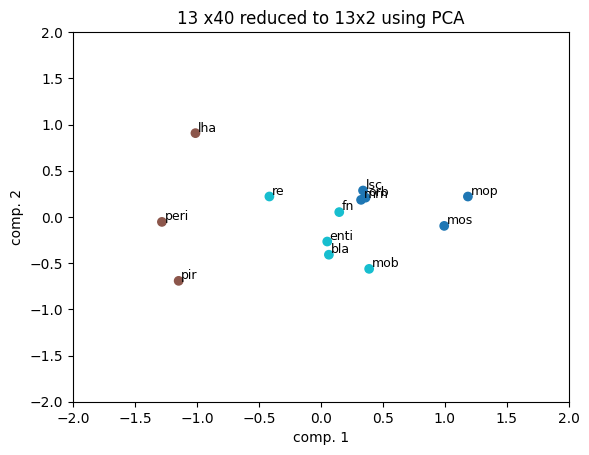

In [ ]:
from sklearn.decomposition import PCA
reducer_pca=PCA(n_components=2,random_state=42)
reducer_pca.fit(df_out.values)
clu_tf_pca=reducer_pca.transform(df_out.values)

kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clu_tf_pca)

plt.scatter(clu_tf_pca[:,0],clu_tf_pca[:,1],c=clus_pl,cmap='tab10')
for i, label in enumerate(labels):
    plt.text(clu_tf_pca[i,0]+0.02, clu_tf_pca[i,1]+0.02, label, fontsize=9)

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.ylabel('comp. 2')
plt.xlabel('comp. 1')
plt.title('13 x40 reduced to 13x2 using PCA')

In [20]:
cluster_part=[]
network_names=[]

# to store avg community participation for a cluster


for n,(f_full,f_part) in enumerate(zip(file_full,file_part)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    network_names.append(f_full.split('_')[-1])
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    cluster_part.append(clusterData.values)

column_header = clusterData.columns
print(network_names)


    


    


['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']


In [21]:
# from each network cluster, extract communities

c_0_parcptn=pd.DataFrame()
c_1_parcptn=pd.DataFrame()
c_2_parcptn=pd.DataFrame()
c_3_parcptn=pd.DataFrame()
c_4_parcptn=pd.DataFrame()

for clus_data,nw in zip(cluster_part,network_names):
    df_clus = pd.DataFrame(clus_data)
    df_clus.columns = column_header

    
    # for cluster 0
    row_c0=df_clus.loc[0].to_frame().T
    row_c0.index=[nw]
    c_0_parcptn=pd.concat([c_0_parcptn,row_c0],axis=0)
    

    #for cluster 1
    row_c1=df_clus.loc[1].to_frame().T
    row_c1.index=[nw]
    c_1_parcptn=pd.concat([c_1_parcptn,row_c1],axis=0)

    #for cluster 2
    row_c2=df_clus.loc[2].to_frame().T
    row_c2.index=[nw]
    c_2_parcptn=pd.concat([c_2_parcptn,row_c2],axis=0)
    
    #for cluster 3
    row_c3=df_clus.loc[3].to_frame().T
    row_c3.index=[nw]
    c_3_parcptn=pd.concat([c_3_parcptn,row_c3],axis=0)

    #for cluster 4
    row_c4=df_clus.loc[4].to_frame().T
    row_c4.index=[nw]
    c_4_parcptn=pd.concat([c_4_parcptn,row_c4],axis=0)



        


In [22]:
dfs_part=[c_2_parcptn,c_4_parcptn]

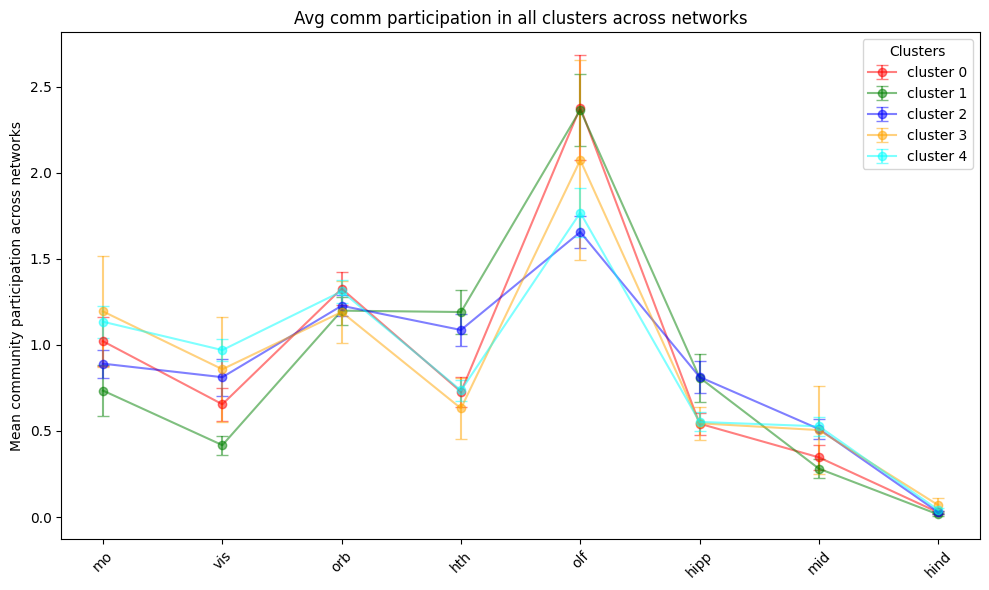

In [23]:


# Your cluster DataFrames
dfs = [c_0_parcptn, c_1_parcptn, c_2_parcptn, c_3_parcptn, c_4_parcptn]

# Define cluster colors
cluster_colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}

plt.figure(figsize=(10,6))

for i, df in enumerate(dfs, start=0):
    # Vertical mean (row-wise mean for each column)
    mean_vals = df.mean(axis=0)
    # Vertical standard deviation
    std_vals = df.std(axis=0)

    # Plot with error bars, using your chosen cluster color
    plt.errorbar(df.columns, mean_vals, yerr=std_vals,
                 label=f'cluster {i}',
                 color=cluster_colors[i],
                 capsize=4, marker='o', linestyle='-', alpha=0.5)

plt.xticks(rotation=45)
plt.ylabel("Mean community participation across networks")
plt.title("Avg comm participation in all clusters across networks")
plt.legend(title="Clusters")
plt.tight_layout()
plt.show()




In [58]:
dfs[0]

,mo,vis,orb,hth,olf,hipp,mid,hind
bla,0.946027,0.790222,1.315748,0.679832,2.293980,0.569710,0.404481,0.030669
enti,1.257179,0.599361,1.439222,0.661568,2.186557,0.454208,0.401906,0.041159
fn,0.993989,0.678284,1.416082,0.684669,2.423625,0.511457,0.291894,0.019842
lha,1.093092,0.685441,1.320350,0.570927,2.502703,0.512058,0.315430,0.024017
lsc,1.002861,0.575773,1.367462,0.706469,2.547664,0.492780,0.306991,0.024914
mob,0.979523,0.712642,1.321307,0.873694,2.101735,0.639470,0.371628,0.030643
mop,0.821761,0.610196,1.240884,0.723040,2.778786,0.538973,0.286359,0.015224
mos,0.835596,0.598804,1.162153,0.805413,2.700909,0.627684,0.269439,0.014000
mrn,0.911909,0.596253,1.316891,0.808545,2.593021,0.513201,0.260179,0.015049
orb,1.037653,0.582054,1.283048,0.737487,2.472195,0.546333,0.341231,0.027185


Save clusterwise participation dtaframes list to use for figure 4c plot  
results/figures/fig4c_data.pkl  

In [57]:
reader.data_dump_pkl('results/figures/fig4c_data.pkl',dfs)

#### Finding clusterwise similar to above plot, for full transitions separately - consider only cluster 2 and 4

In [24]:

def compute_cluster_comm_partcptn(df_f,n):
    # df_p.dropna(inplace=True)
    # df_combined = pd.concat([df_f,df_p],axis=0)
    # print(df_f.shape)
    # print(df_p.shape)
    # print(df_combined.shape)

    df_f['cluster']=full_nw_labels[n]
    # print(df_combined.shape)

    # removing df_full rows from combined
    df_work=df_f.copy()
    # print(df_work.shape)
    # df_work.head()

    # take average clusterwise for each column

    communities = list(df_work.columns[:-1])
    # print(communities)
    cluster_data = pd.DataFrame()
    for comm in communities:
        # print(comm)
        df_cluster = df_work.groupby('cluster')[comm].mean()
        cluster_data=pd.concat([cluster_data,df_cluster],axis=1)

    # Plot bar chart using cluster data
    # take avg of each cluster excluding hind
    # print(cluster_data)
    # avg_0 = cluster_data.loc[0][:-1].mean()
    # avg_1 = cluster_data.loc[1][:-1].mean()
    avg_2 = cluster_data.loc[2][:-1].mean()

    # comment when using 3 clusters only
    # avg_3 = cluster_data.loc[3][:-1].mean()
    avg_4 = cluster_data.loc[4][:-1].mean()

    # Normalizing each cluster 
    # c_0 = cluster_data.loc[0]/avg_0
    # c_1 = cluster_data.loc[1]/avg_1
    c_2 = cluster_data.loc[2]/avg_2

    # # comment when using 3 clusters
    # c_3 = cluster_data.loc[3]/avg_3
    c_4 = cluster_data.loc[4]/avg_4

    # print(cluster_data.head(3))
    # Updating cluster data to plot
    # cluster_data.loc[0]=c_0
    # cluster_data.loc[1]=c_1
    cluster_data.loc[2]=c_2

    # comment when using 3 clusters
    # cluster_data.loc[3]=c_3
    cluster_data.loc[4]=c_4
    
    # cluster_data.head(3)
    cluster_plot = cluster_data.copy()

    # cluster_plot.head()
    # print(cluster_plot)
    return cluster_plot
    



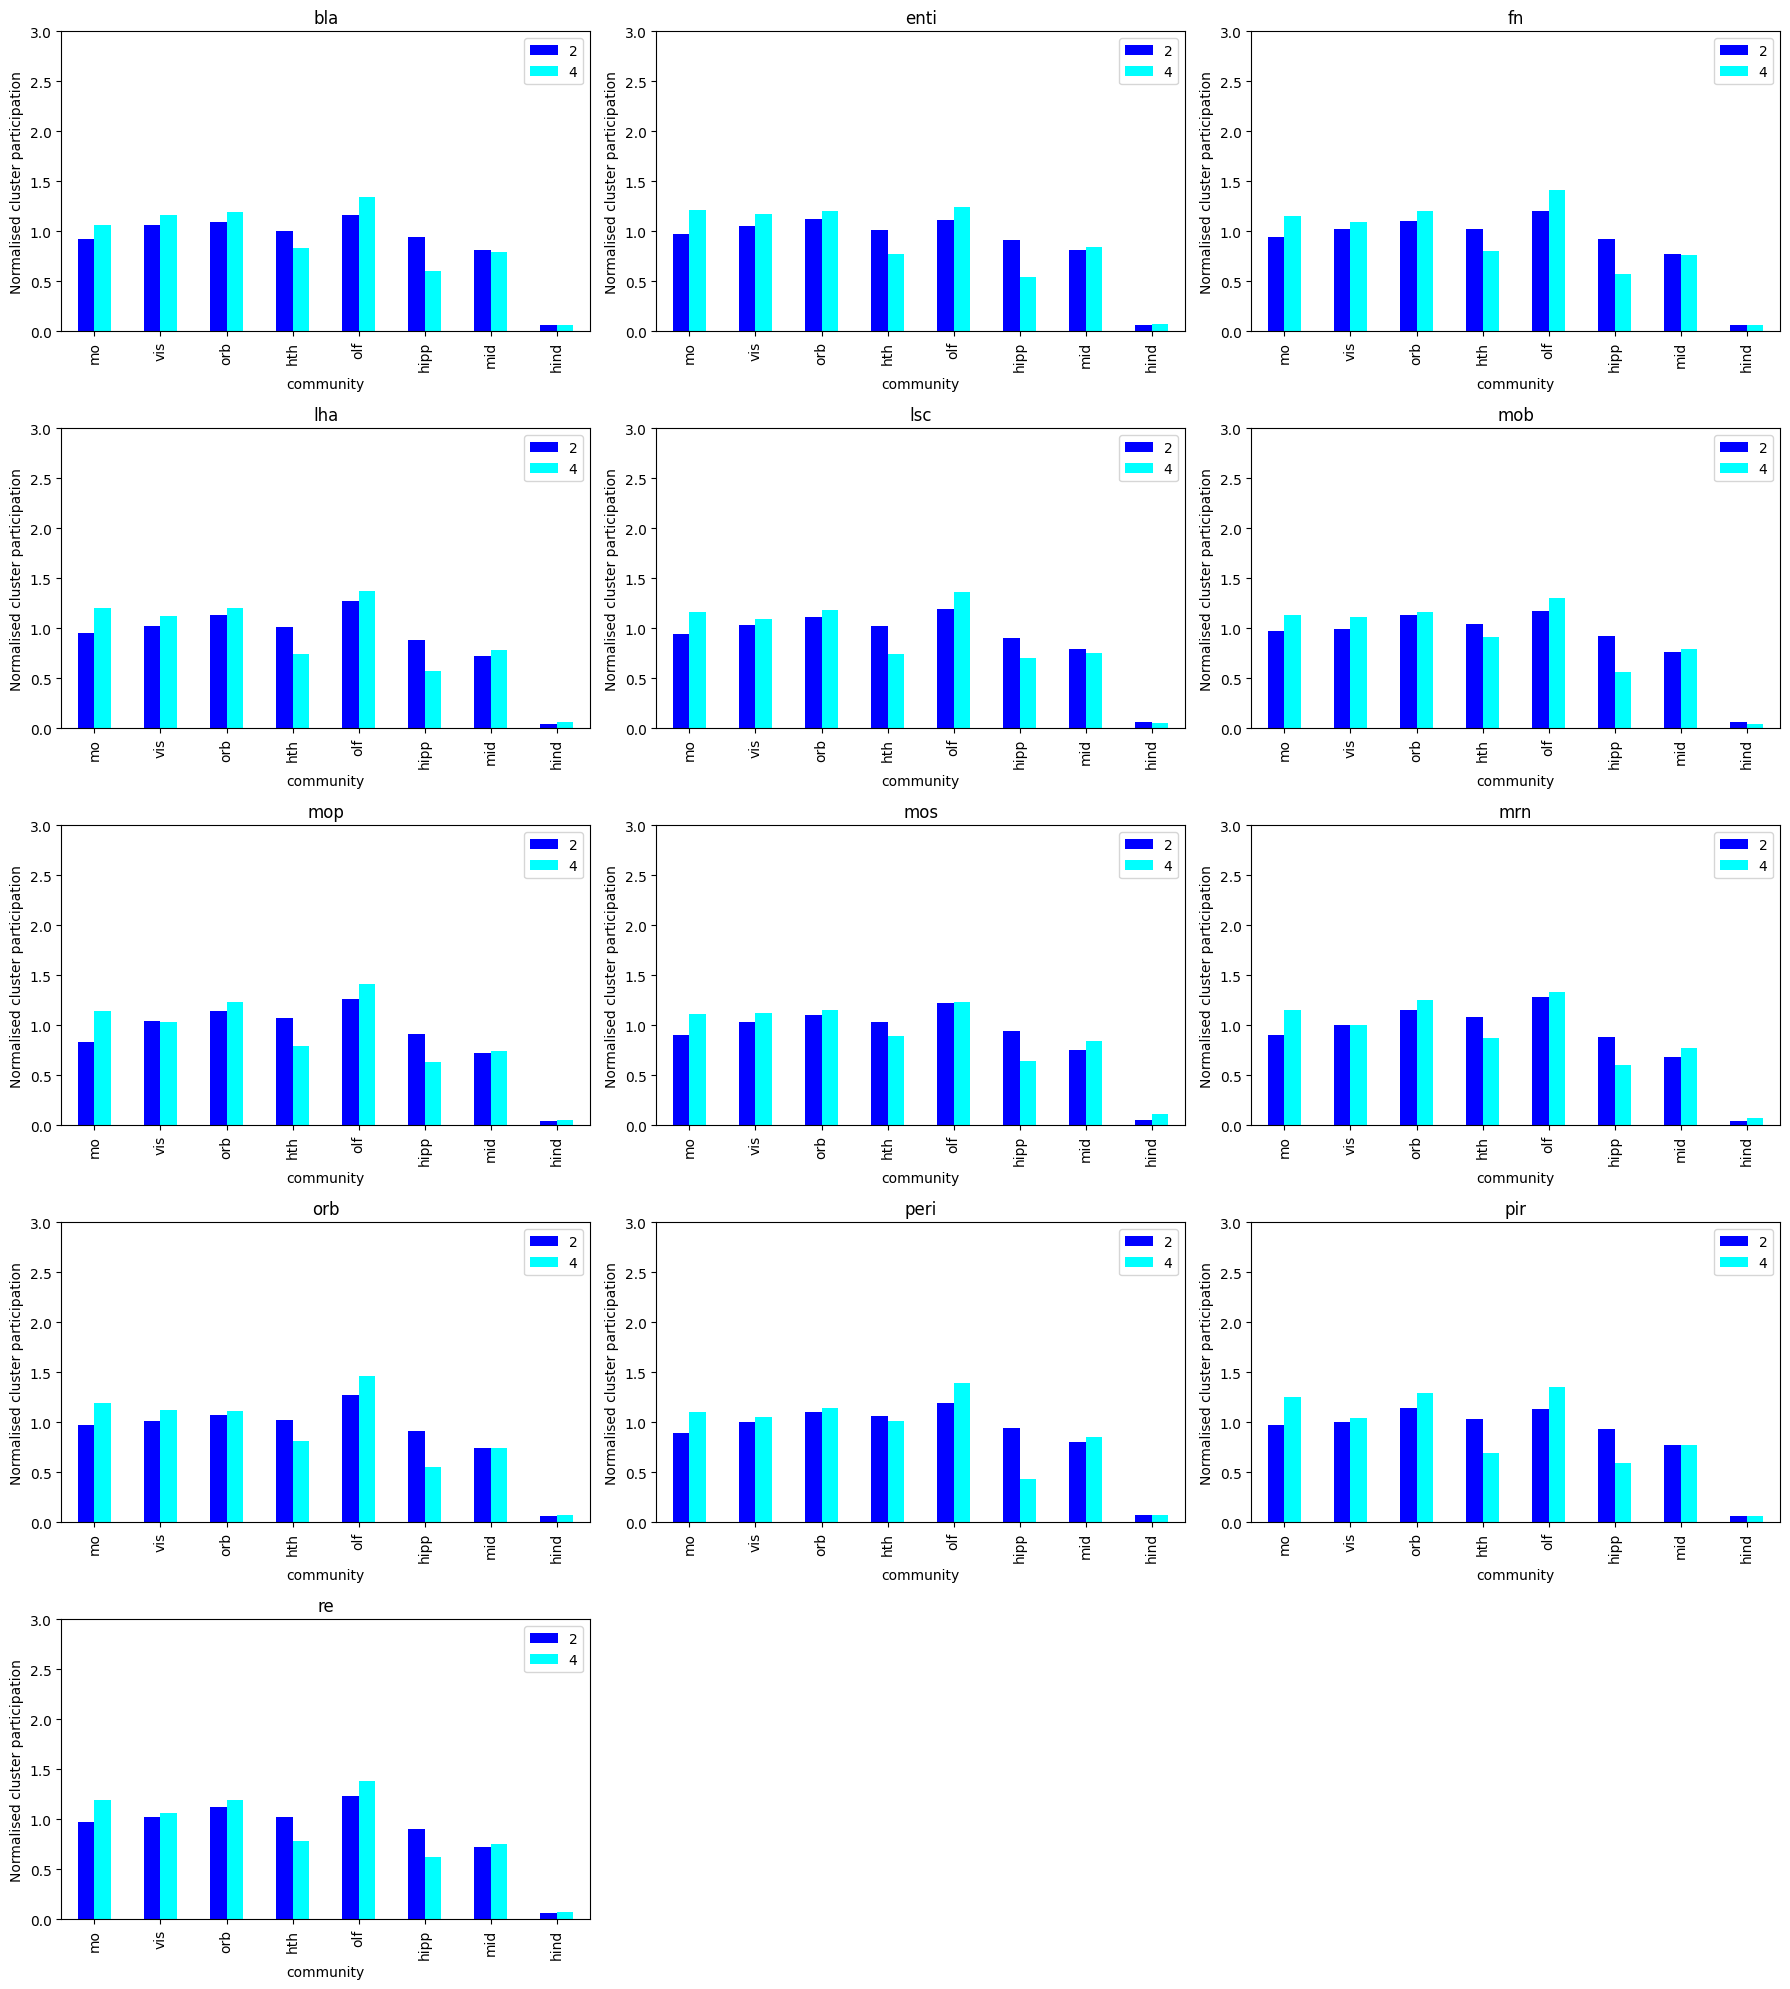

In [25]:
import math

n_files = len(file_full)   # should be 13
n_cols = 3                 # number of columns you want
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()   # flatten to 1D array for easy looping

cluster_colors = {2: "blue", 4: "cyan"}
data_dict ={}

for n, (f_full, ax) in enumerate(zip(file_full, axes)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    
    
    clusterData = compute_cluster_comm_partcptn(df_f, n)
    
    clusterData.T.plot(
        kind='bar',
        ax=ax,
        color=[cluster_colors.get(c, "gray") for c in clusterData.T.columns]
    )
    
    ax.set_xlabel('community')
    ax.set_ylabel('Normalised cluster participation')
    ax.set_ylim(0,3)
    ax.set_title(file_full[n].split('_')[-1])

    # storing cluster data as flattened 8x5 for each network  
    # cl_data=clusterData.values.flatten()
    # nw=file_full[n].split('_')[-1]
    # data_dict[nw]=cl_data

    # with col labels
    # Create MultiIndex labels
    labels = [(comm, clus) for comm in clusterData.index for clus in clusterData.columns]
    cl_data = pd.Series(clusterData.values.flatten(), index=pd.MultiIndex.from_tuples(labels))

    nw = file_full[n].split('_')[-1]
    data_dict[nw] = cl_data


# Hide any unused subplots if n_files doesn’t fill the grid
for ax in axes[n_files:]:
    ax.set_visible(False)

plt.tight_layout()

# plt.savefig('../../data/results/fig_5_cluster_bar.pdf',format='pdf')


In [27]:
cluster_full=[]
network_names=[]

# to store avg community participation for a cluster


for n,f_full in enumerate(file_full):
    df_f = pd.read_pickle(f_full, compression='bz2')
    
    
    network_names.append(f_full.split('_')[-1])
    clusterData = compute_cluster_comm_partcptn(df_f, n)
    cluster_full.append(clusterData.values)

column_header = clusterData.columns
print(network_names)


    


    


['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']


In [28]:
# from each network cluster, extract communities


c_2_parcptn=pd.DataFrame()

c_4_parcptn=pd.DataFrame()

# plot full
for clus_data,nw in zip(cluster_full,network_names):
    df_clus = pd.DataFrame(clus_data)
    df_clus.columns = column_header
    df_clus.index=[2,4]

    
    
    

    

    #for cluster 2
    row_c2=df_clus.loc[2].to_frame().T
    row_c2.index=[nw]
    c_2_parcptn=pd.concat([c_2_parcptn,row_c2],axis=0)
    
    

    #for cluster 4
    row_c4=df_clus.loc[4].to_frame().T
    row_c4.index=[nw]
    c_4_parcptn=pd.concat([c_4_parcptn,row_c4],axis=0)



        


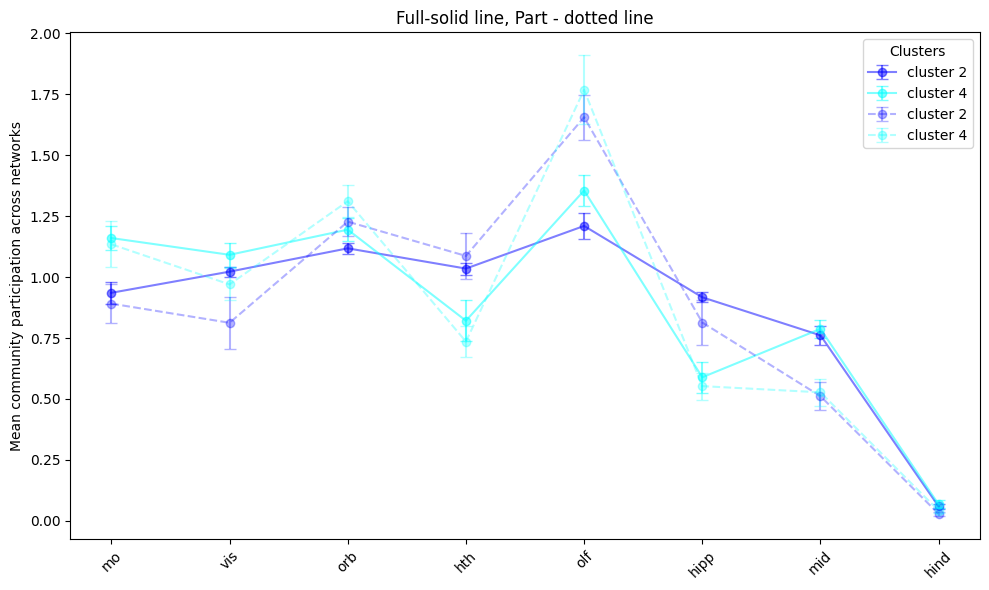

In [ ]:


# Your cluster DataFrames
dfs = [c_2_parcptn, c_4_parcptn]

# Define cluster colors
cluster_colors = {2: "blue",  4: "cyan"}

plt.figure(figsize=(10,6))

for i, df in zip([2,4],dfs):
    # Vertical mean (row-wise mean for each column)
    mean_vals = df.mean(axis=0)
    # Vertical standard deviation
    std_vals = df.std(axis=0)

    # Plot with error bars, using your chosen cluster color
    plt.errorbar(df.columns, mean_vals, yerr=std_vals,
                 label=f'cluster {i}',
                 color=cluster_colors[i],
                 capsize=4, marker='o', linestyle='-', alpha=0.5)


# plot part stored in dfs_part
for i, df in zip([2,4],dfs_part):
    # Vertical mean (row-wise mean for each column)
    mean_vals = df.mean(axis=0)
    # Vertical standard deviation
    std_vals = df.std(axis=0)

    # Plot with error bars, using your chosen cluster color
    plt.errorbar(df.columns, mean_vals, yerr=std_vals,
                 label=f'cluster {i}',
                 color=cluster_colors[i],
                 capsize=4, marker='o', linestyle='--', alpha=0.3)

plt.xticks(rotation=45)
plt.ylabel("Mean community participation across networks")
plt.title("Full-solid line, Part - dotted line")
plt.legend(title="Clusters")
plt.tight_layout()
plt.show()




In [21]:
dfs[0]

,mo,vis,orb,hth,olf,hipp,mid,hind
bla,0.918787,1.058789,1.098237,1.007483,1.162870,0.943193,0.810641,0.064445
enti,0.977770,1.053415,1.118780,1.008927,1.114197,0.910342,0.816569,0.066082
fn,0.944599,1.018583,1.107842,1.027872,1.204647,0.924630,0.771827,0.063272
lha,0.956841,1.020386,1.132498,1.008882,1.269999,0.887993,0.723400,0.048284
lsc,0.941729,1.034008,1.112271,1.021389,1.196501,0.905228,0.788875,0.062194
mob,0.972238,0.992459,1.130845,1.042329,1.174835,0.921948,0.765346,0.063140
mop,0.829025,1.039459,1.147192,1.071463,1.266630,0.918133,0.728097,0.040418
mos,0.900378,1.033491,1.106351,1.038060,1.222281,0.941439,0.758001,0.057398
mrn,0.908134,1.001787,1.150022,1.084534,1.288036,0.882712,0.684776,0.040578
orb,0.972701,1.009532,1.068664,1.022565,1.273377,0.908855,0.744306,0.060378


## Compute clusterwise params

Use this file which contains iteration number and the transition in it for every network  
Saved in 'results/comm_umap_results/part_full_comm_ind.pkl'

- Network based iteration number and index result
- Tuple index is row number of your 'trans x 8' file
- Tuple 1st element is iteration number
- Tuple 2nd element is the index number of the transition in that iteration

In [40]:
nw_itr= reader.data_read_pkl('results/comm_umap_results/part_full_comm_ind.pkl')

Peek inside above file

In [32]:
# nw_itr.keys()    
# ['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']
# nw_itr['bla'].keys()
# ['part_ind', 'full_ind']
# nw_itr['bla']['full_ind']    
# list of tuples

Define function which labels each transition by it's cluster  
INPUT: trans x 8, nw_itr, _reducer, ref_centroids  
OUTPUT:   Cluster indices i.e row index of trans x 8  

In [33]:
df_par= reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')

In [ ]:
def compute_cluster_indices(df,nw_itr,_reducer, ref_centroids, nw, trans_type):
    """Compute index of rows of df specific to a cluster

    Args:
        df (dataframe): number of transitions x 8 (Community wise participation for each transition)
        nw_itr (dict): Contains iteration number and the transition in it for all networks (Partial and Full transitions both)
        _reducer (UMAP): UMAP reduced on partial FN data
        ref_centroids (nd array): Centroids as per FN data after clustering
        nw (string): ['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']
        trans_type (string): ['part_ind', 'full_ind']

    Returns:
        dictionary: keys: 'cluster_ind',''new_ind'
    """
    i_part=nw_itr[nw][trans_type].copy()
    # find NaN rows index of entries x 8 vector space
    nan_indices = df.index[df.isnull().any(axis=1)].tolist()

    # removing the NaN row
    if not nan_indices:
        pass
        new_ind=i_part
    else:
        # dropping NaN value
        df.dropna(inplace = True)
        # removing nan entries from nw_itr of given network
        
        for i in nan_indices:
            new_ind = [val for i, val in enumerate(i_part) if i not in nan_indices]

    

    embedding = _reducer.transform(df.values)
    network_labels = assign_clusters(embedding,ref_centroids)

    # assigning cluster labels to our 186 x2 vector space  
    df_embed = pd.DataFrame(embedding)
    df_embed['cluster'] = network_labels

    cluster_indices = {c: df_embed.index[df_embed['cluster'] == c].tolist() for c in df_embed['cluster'].unique()}
    
    return {'cluster_ind':cluster_indices,'nw_new':new_ind}



   

In [35]:
l=compute_cluster_indices(df_par,nw_itr,_reducer,ref_centroids,'fn','full_ind')


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [36]:
l['cluster_ind'].keys()

dict_keys([2, 4])

Define function which computes parameters clusterwise

In [ ]:
def compute_cluster_params(cluster_indices,new_ind,df_go,df_nc):
    """Computes cluster wise params and stores them in dict

    Args:
        cluster_indices (_type_): _description_
        new_ind (_type_): _description_
        df_go (_type_): _description_
        df_nc (_type_): _description_

    Returns:
        _type_: _description_
    """
    clus_params={}
    for i in list(l['cluster_ind'].keys()):

        # saving clusterwise params data
        fpt=[]
        st=[]
        cov=[]
        tt=[]
        for ind in cluster_indices[i]:
            

            # getting actual iteration number
            itrn = new_ind[ind]
            
            # compute params
            pts=algo_umap.compute_parameters(df_go[itrn[0]])
            fpt_list=algo.compute_fpt(pts['start_points'].copy(),pts['stop_points'].copy())[itrn[1]]
            fpt.append(fpt_list)
            st_list = algo.compute_sync(pts['start_points'].copy(),pts['stop_points'].copy())
            if itrn[1]  < len(st_list):
                # consider case when transition doesn't falls back
                st.append(st_list[itrn[1]])
            
            cov_list = comm_ops.compute_individual_coverage_nc(df_nc.loc[itrn[0]], df_go[itrn[0]])[itrn[1]]
            cov.append(cov_list)
            tt_list = algo_umap.compute_transition_time(df_go[itrn[0]],pts['start_points'].copy())[itrn[1]]
            tt.append(tt_list)

        clus_params[i]={'fpt':fpt,'st':st, 'cov':cov, 'tt':tt}
    return clus_params
        

In [ ]:
df_go = reader.data_read_bz2('raw/workstation/tes_fn_go.bz2')
df_nc = reader.data_read_bz2('raw/workstation/tes_fn_nc.bz2')

In [ ]:
f_full=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

#### Compute for full params clusterwise

In [4]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))



In [ ]:
data_folder = Path('../../data/raw/workstation')
file_go =glob.glob(str(data_folder/'tes_*_go.bz2'))
file_nc=glob.glob(str(data_folder/'tes_*_nc.bz2'))

In [ ]:
f_name = file_full[0]

In [ ]:
f_name.split('_')[-1]

'bla'

In [ ]:
for f_full,f_part,f_go,f_nc in zip(file_full,file_part,file_go,file_nc):
    nw=f_full.split('_')[-1]
    
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_go=pd.read_pickle(f_go,compression='bz2')
    df_nc=pd.read_pickle(f_nc,compression='bz2')
    # computing full
    l=compute_cluster_indices(df_full,nw_itr,_reducer,ref_centroids,nw,'full_ind')
    f_full=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)
    # save
    # reader.data_dump_pkl(f'results/comm_umap_results/comm_wise_params/full_{nw}',f_full)


    #computing part
    l=compute_cluster_indices(df_part,nw_itr,_reducer,ref_centroids,nw,'part_ind')
    f_part=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)
    # reader.data_dump_pkl(f'results/comm_umap_results/comm_wise_params/part_{nw}',f_part)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

...

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell
this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell
this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


#### Read cluster wise params and plot

In [ ]:
def plot_params(data,label):
    """Plots violinplots for every parameter clusterwise

    Args:
        data (dictionary): cluster wise param data
        label (string): network name
    """

    fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(15, 15),sharey='row')
    key_list=['fpt', 'st', 'cov', 'tt']
    for i in list(data.keys()):              # outer loop cluster
        for j in range(4):
                    # inner loop (columns)
            ax = axes[j,i]         # select subplot
            plt_data = data[i][key_list[j]]  # get the data from dictionary

            # Example: violin plot
            if plt_data:
                ax.violinplot(plt_data, showmedians=True)
                ax.set_title(f"cluster {i}, {key_list[j]}")
            else:
                ax.text(0.5, 0.5, "Empty", ha='center')

    plt.suptitle(f'Cluster wise {label}')
    plt.tight_layout()
    # plt.savefig(f'../../data/results/comm_umap_results/comm_wise_params/cw_{label}.pdf', format='pdf')
    
    
    
    plt.show()


    

Folder where clusterwise params data is stored

In [3]:
data_folder = Path('../../data/results/comm_umap_results/comm_wise_params')
file_full = glob.glob(str(data_folder/'full_*'))
file_part = glob.glob(str(data_folder/'part_*'))



To count number of transitions for each cluster


In [4]:
data=reader.data_read_pkl('results/comm_umap_results/comm_wise_params/part_fn')

In [8]:
data.keys()

dict_keys([2, 4, 1, 0, 3])

In [7]:
data[2].keys()

dict_keys(['fpt', 'st', 'cov', 'tt'])

In [43]:
len(data[2]['tt'])

24

In [ ]:
# we count by counting entries in transition time  

def count_cw(data,cl):
    cl_count={}
    # cl=[0,1,2,3,4]
    
    for i in cl:
        cl_count[i]=len(data[i]['tt'])

    return cl_count
    

In [ ]:
# counting partial
clc_nw={}
for fp in file_part:
    with open(fp, "rb") as f:
        pkl_part = pickle.load(f)
    clc_nw[fp.split('_')[-1]]=count_cw(pkl_part,[0,1,2,3,4])

In [52]:
clc_nw

{'bla': {0: 38, 1: 11, 2: 21, 3: 13, 4: 24},
 'enti': {0: 62, 1: 6, 2: 13, 3: 24, 4: 46},
 'fn': {0: 53, 1: 21, 2: 24, 3: 38, 4: 50},
 'lha': {0: 63, 1: 13, 2: 12, 3: 14, 4: 38},
 'lsc': {0: 75, 1: 22, 2: 23, 3: 19, 4: 48},
 'mob': {0: 41, 1: 18, 2: 16, 3: 25, 4: 32},
 'mop': {0: 64, 1: 30, 2: 9, 3: 34, 4: 27},
 'mos': {0: 69, 1: 33, 2: 16, 3: 44, 4: 24},
 'mrn': {0: 51, 1: 24, 2: 19, 3: 23, 4: 31},
 'orb': {0: 49, 1: 15, 2: 11, 3: 34, 4: 27},
 'peri': {0: 31, 1: 13, 2: 6, 3: 16, 4: 12},
 'pir': {0: 32, 1: 11, 2: 8, 3: 24, 4: 35},
 're': {0: 63, 1: 33, 2: 28, 3: 27, 4: 49}}

In [ ]:
# counting full clusterwise
clc_fnw={}
for ff in file_full:
    with open(ff, "rb") as f:
        pkl_full = pickle.load(f)
    clc_fnw[ff.split('_')[-1]]=count_cw(pkl_full,[2,4])

In [7]:
clc_fnw

{'bla': {2: 50, 4: 1},
 'enti': {2: 51, 4: 6},
 'fn': {2: 97, 4: 6},
 'lha': {2: 44, 4: 11},
 'lsc': {2: 94, 4: 3},
 'mob': {2: 93, 4: 1},
 'mop': {2: 69, 4: 3},
 'mos': {2: 41, 4: 1},
 'mrn': {2: 78, 4: 1},
 'orb': {2: 89, 4: 5},
 'peri': {2: 46, 4: 1},
 'pir': {2: 62, 4: 5},
 're': {2: 83, 4: 9}}

In [7]:
# checking if count matches with without clusterwise count
fn_data = reader.data_read_pkl("results/calculate_final_params/final_fn.pkl")
fn_data[0]
# good news! It matches

{'n_part': 187,
 'n_full': 103,
 'n_total': 290,
 'itr_tran': [0,
  3,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  14,
  15,
  16,
  17,
  18,
  21,
  22,
  23,
  24,
  25,
  28,
  29,
  30,
  31,
  32,
  33,
  35,
  36,
  37,
  39,
  41,
  43,
  44,
  46,
  47,
  49,
  50,
  51,
  52,
  53,
  54,
  56,
  58,
  59,
  60,
  62,
  64,
  66,
  67,
  69,
  70,
  72,
  73,
  74,
  76,
  79,
  80,
  81,
  82,
  83,
  85,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  98,
  99,
  101,
  102,
  103,
  104,
  105,
  106,
  108,
  109,
  111,
  112,
  114,
  115,
  116,
  117,
  118,
  119,
  121,
  122,
  123,
  124,
  125,
  126,
  128,
  129,
  130,
  131,
  133,
  134,
  135,
  137,
  140,
  142,
  143,
  144,
  145,
  147,
  148,
  155,
  156,
  157,
  158,
  160,
  162,
  163,
  164,
  165,
  166,
  167,
  170,
  172,
  173,
  174,
  175,
  176,
  177,
  178,
  179,
  180,
  181,
  184,
  185,
  186,
  187,
  188,
  190,
  194,
  195,
  196,
  197,
  199]}

In [14]:
clc_nw['fn'][0]

53

In [26]:
# count clusterwise transitions
# uncomment and comment for full transition clusterwise params
def count_cw_t(data):
    # give data 'clc_nw' or 'clc_fw'
    # c0=[]
    # c1=[]
    c2=[]
    # c3=[]
    c4=[]
    for nw in data.keys():
        # c0.append(data[nw][0])
        # c1.append(data[nw][1])
        c2.append(data[nw][2])
        # c3.append(data[nw][3])
        c4.append(data[nw][4])
    # return {'c0':c0,'c1':c1,'c2':c2,'c3':c3,'c4':c4}
    return {'c2':c2,'c4':c4}

data of partial transitions clusterwise

In [25]:
f5b1=count_cw_t(clc_nw)

data of full transitions clusterwise  


In [27]:
f5c1=count_cw_t(clc_fnw)

In [28]:
data_c={'5b1':f5b1,'5c1':f5c1}

In [29]:
data_c

{'5b1': {'c0': [38, 62, 53, 63, 75, 41, 64, 69, 51, 49, 31, 32, 63],
  'c1': [11, 6, 21, 13, 22, 18, 30, 33, 24, 15, 13, 11, 33],
  'c2': [21, 13, 24, 12, 23, 16, 9, 16, 19, 11, 6, 8, 28],
  'c3': [13, 24, 38, 14, 19, 25, 34, 44, 23, 34, 16, 24, 27],
  'c4': [24, 46, 50, 38, 48, 32, 27, 24, 31, 27, 12, 35, 49]},
 '5c1': {'c2': [50, 51, 97, 44, 94, 93, 69, 41, 78, 89, 46, 62, 83],
  'c4': [1, 6, 6, 11, 3, 1, 3, 1, 1, 5, 1, 5, 9]}}

Store above data to make panel 1 for fig5b,c  

In [30]:
reader.data_dump_pkl('results/figures/fig5bc1_data.pkl',data_c)

Making data for figure 5b,c

Define function to compute mean params of a given network data clusterwise

In [ ]:
def compute_nw_clust_means(data):
    """Takes in clusterwise param data for a given network and then computes means clusterwise
    Input files at '../../data/results/comm_umap_results/comm_wise_params'

    Args:
        data (dictionary): contains clusterwise parameters for a given network
    Returns:
        dictionary: clusterwise parameter means
    """
# define dictionary to store clusterwise mean param for each network
    nw_data={}
    # dictionary to store each parameter for a cluster
    clus_param={}
    #iterating over clusters
    for k in data.keys():
        #iterating over params  
        for p in data[k].keys():
            # store mean of params in dictionary
            # remove zero values if any mostly in coverage
            data_=[x for x in data[k][p] if x>0]
            clus_param[p]=np.mean(data_)
        nw_data[k]=clus_param
        clus_param={}
    return nw_data
    


In [ ]:
# compute and store data for figure 5b (network wise partial transitions parameter means)
data_5b={}
for fp in file_part:
    with open(fp, "rb") as f:
        pkl_part = pickle.load(f)
    data_5b[fp.split('_')[-1]]=compute_nw_clust_means(pkl_part)

In [ ]:
# compute and store data for figure 5c (network wise full transitions parameter means)
data_5c={}
for ff in file_full:
    with open(ff, "rb") as f:
        pkl_full = pickle.load(f)
    data_5c[ff.split('_')[-1]]=compute_nw_clust_means(pkl_full)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [38]:
data_5b['fn'][4]

{'fpt': 448.9,
 'st': 127.17391304347827,
 'cov': 0.233860678480881,
 'tt': 55.89200000000001}

define function to get clusterwise params from data_5b,c

In [ ]:
def comp_clus_data(data,n):
    """Takes in data and gives clusterwise params

    Args:
        data (dictionary): data_5b,data_5c
        n (integer): cluster number 0,1,2,3,4
    Returns:
        dictionary: clusterwise mean params
    """
    fpt=[]
    st=[]
    tt=[]
    cov=[]
    for nw in data.keys():
       fpt.append(data[nw][n]['fpt'])
       st.append(data[nw][n]['st'])
       tt.append(data[nw][n]['tt'])
       cov.append(data[nw][n]['cov'])
    
    return {'fpt':fpt,'st':st,'tt':tt,'cov':cov}

In [ ]:
cluster_dt5b={}
for i in data_5b['fn'].keys():
    cluster_dt5b[i]=comp_clus_data(data_5b,i)


In [ ]:
cluster_dt5c={}
for i in data_5c['fn'].keys():
    cluster_dt5c[i]=comp_clus_data(data_5c,i)

Store data for figure 5b 5c

In [26]:
reader.data_dump_pkl('results/figures/fig5b_data.pkl',cluster_dt5b)
reader.data_dump_pkl('results/figures/fig5c_data.pkl',cluster_dt5c)

In [13]:
d=reader.data_read_pkl('results/comm_umap_results/comm_wise_params/part_fn')

In [10]:
fpt_med=[]
st_med =[]
cov_med =[]
tt_med=[]
def collect_data(d):
    key_list=['fpt', 'st', 'cov', 'tt']
    
    for clus in list(d.keys()):
        for j in range(4):
            data = d[clus][key_list[j]]
            if j==0:
                fpt_med.append(np.median(data))
            elif j==1:
                st_med.append(np.median(data))
            elif j==2:
                cov_med.append(np.median(data))
            else:
                tt_med.append(np.median(data))


In [ ]:
for f_full, f_part in zip(file_full,file_part):
    print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    collect_data(pkl_full)

    # with open(f_part, "rb") as f:
    #     pkl_part = pickle.load(f)

    # plot_params(pkl_part,f"part_{f_part.split('_')[-1]}")

    # print(f"full_{f_full.split('_')[-1]}")

full_bla
full_enti
full_fn
full_lha
full_lsc
full_mob
full_mop
full_mos
full_mrn
full_orb
full_peri
full_pir
full_re


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
collect_data(d)

In [12]:
tt_med

[76.15, 67.525]

full_bla


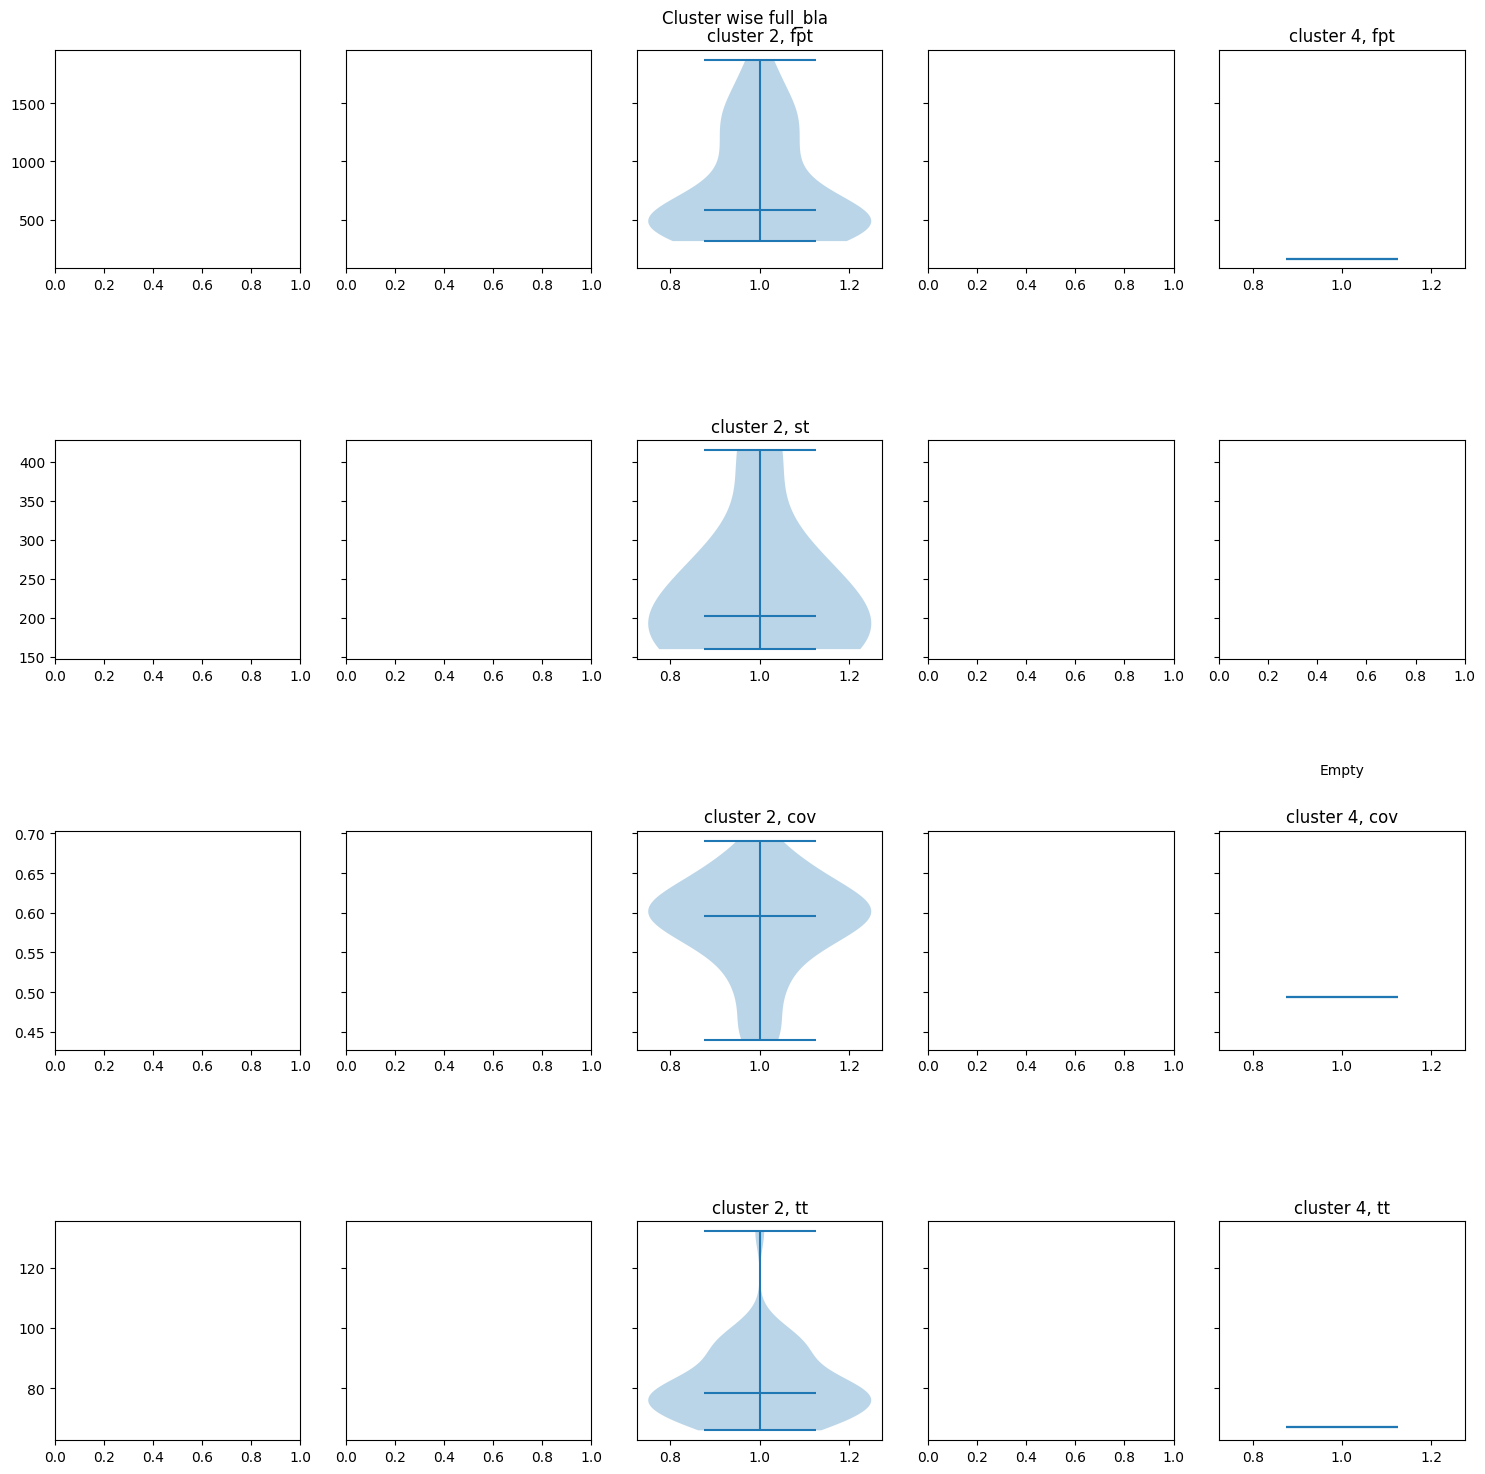

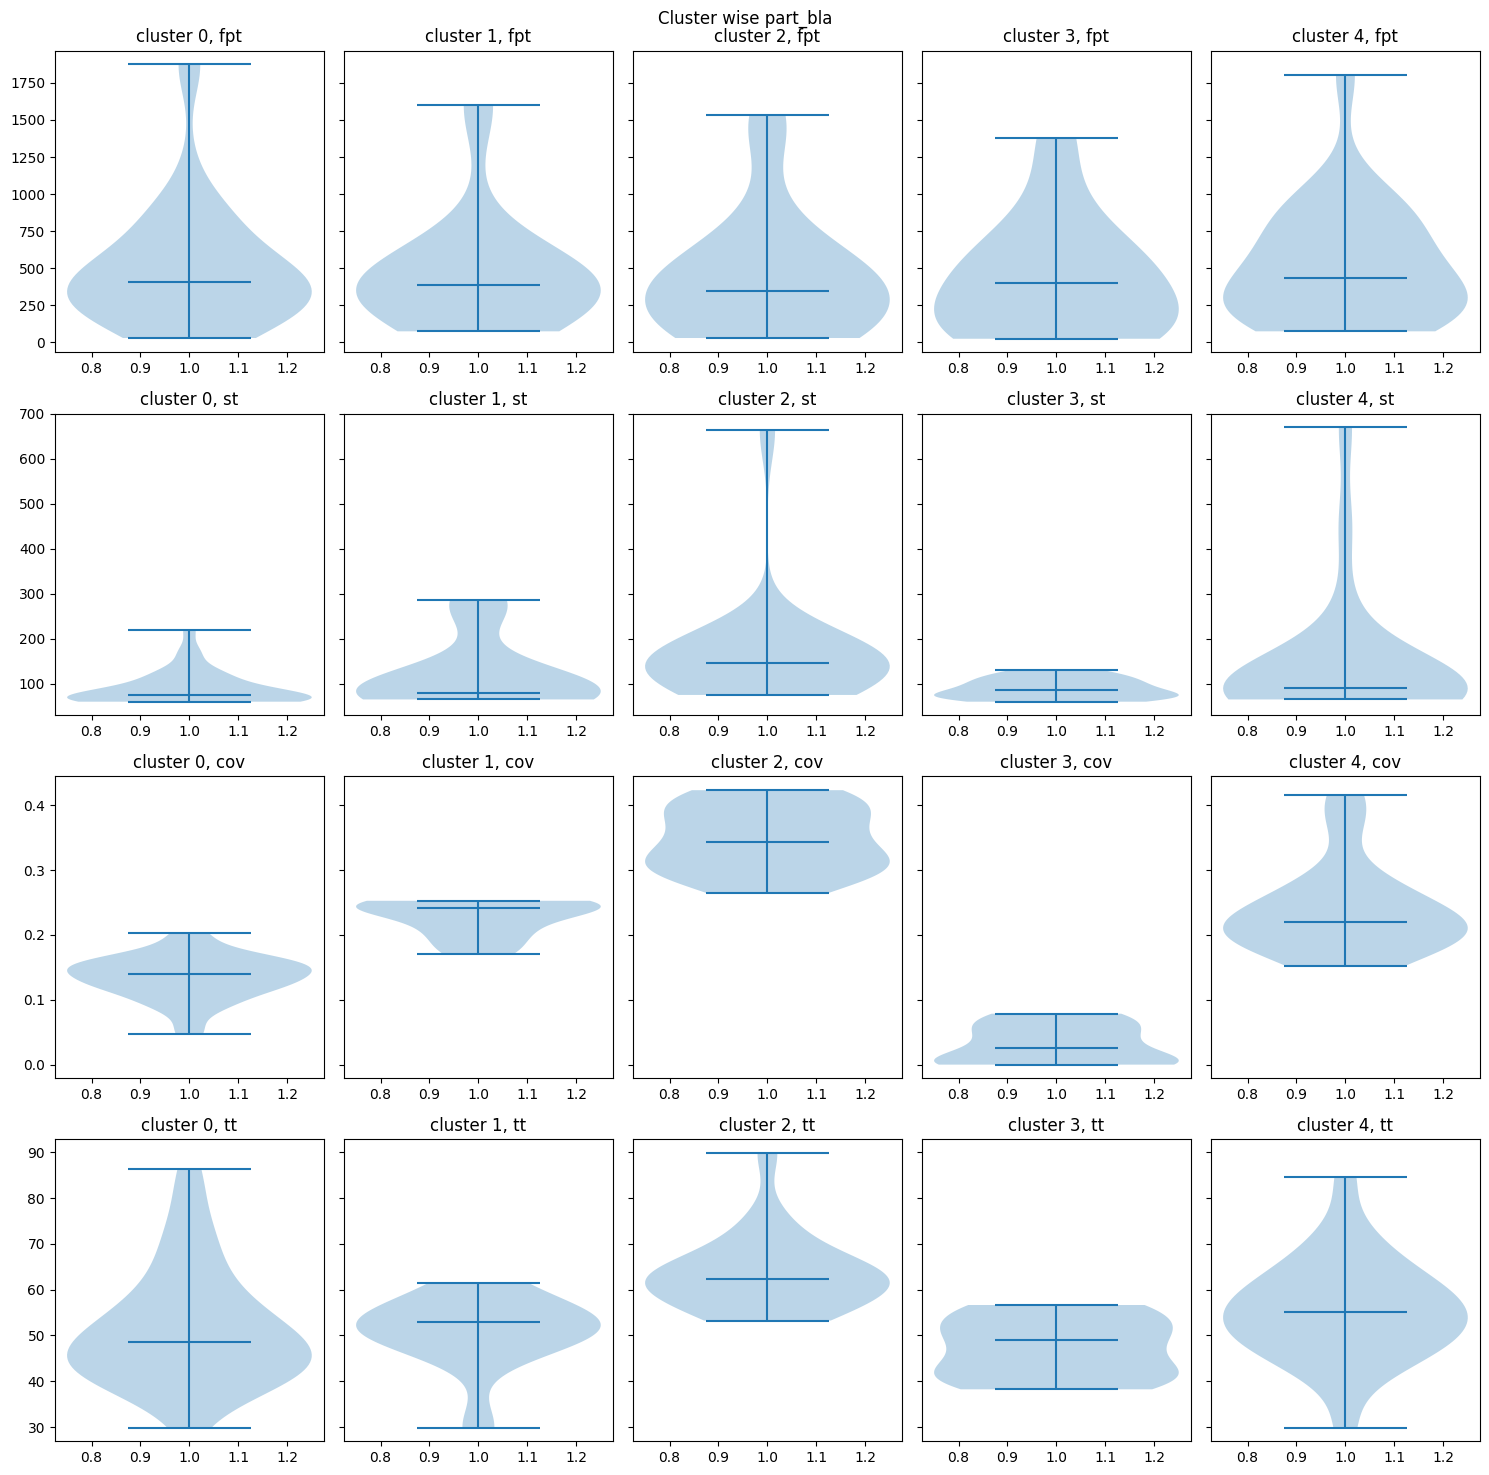

full_bla
full_enti


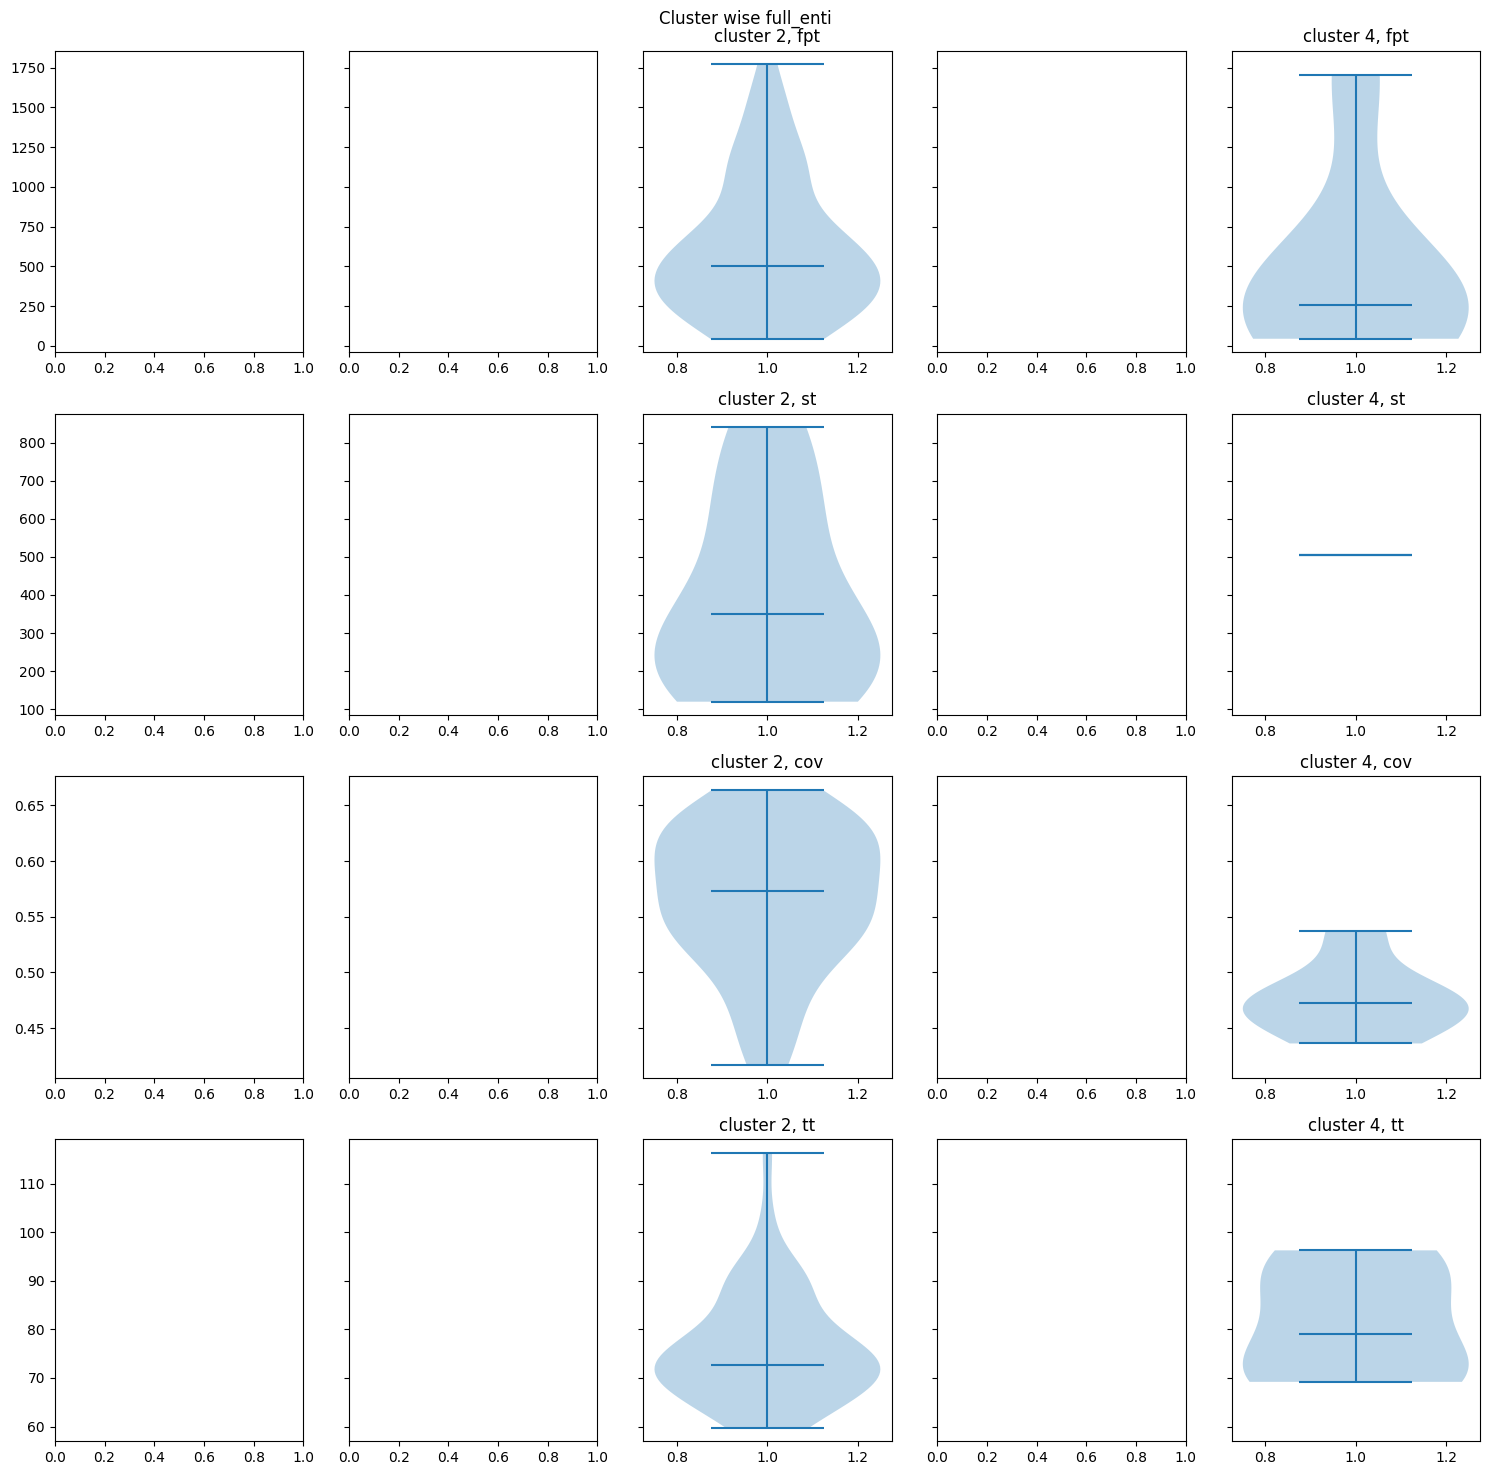

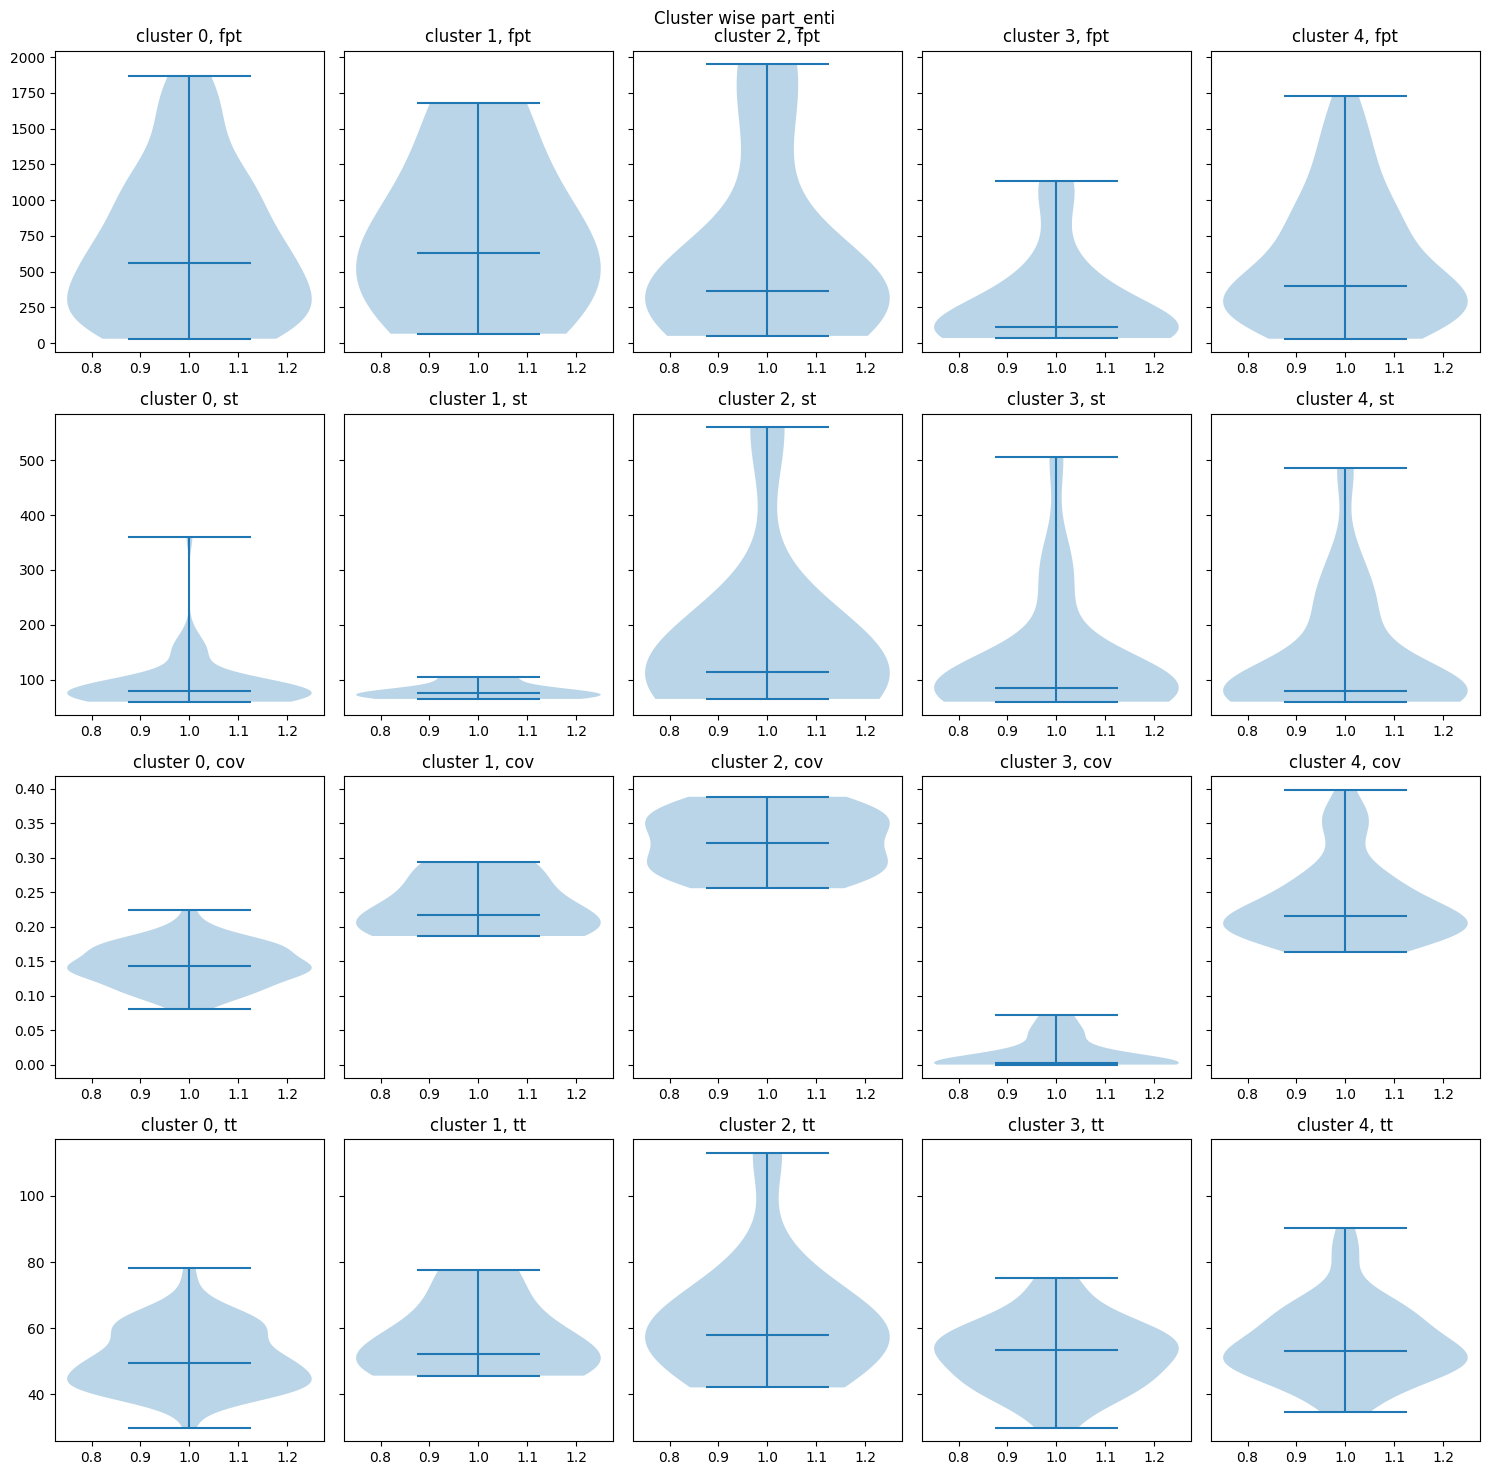

full_enti
full_fn


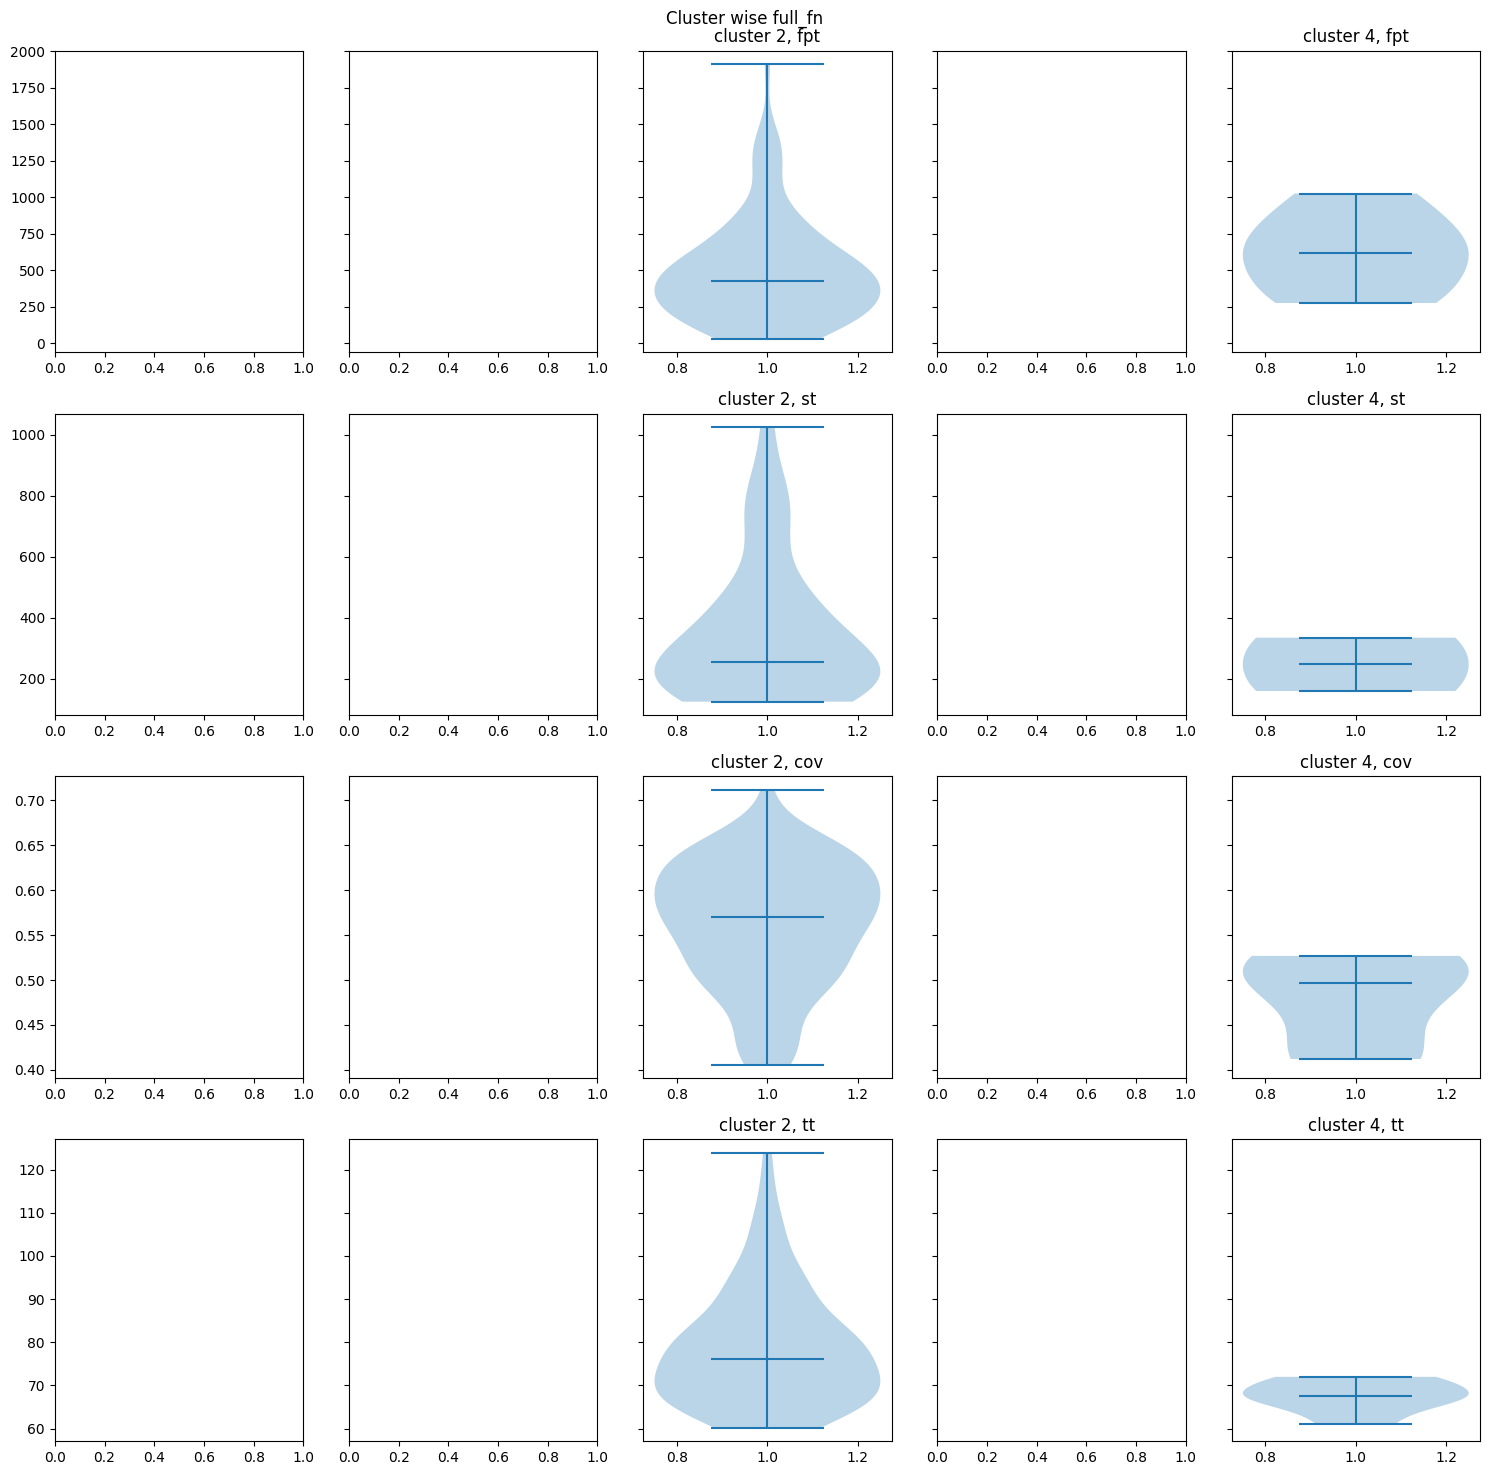

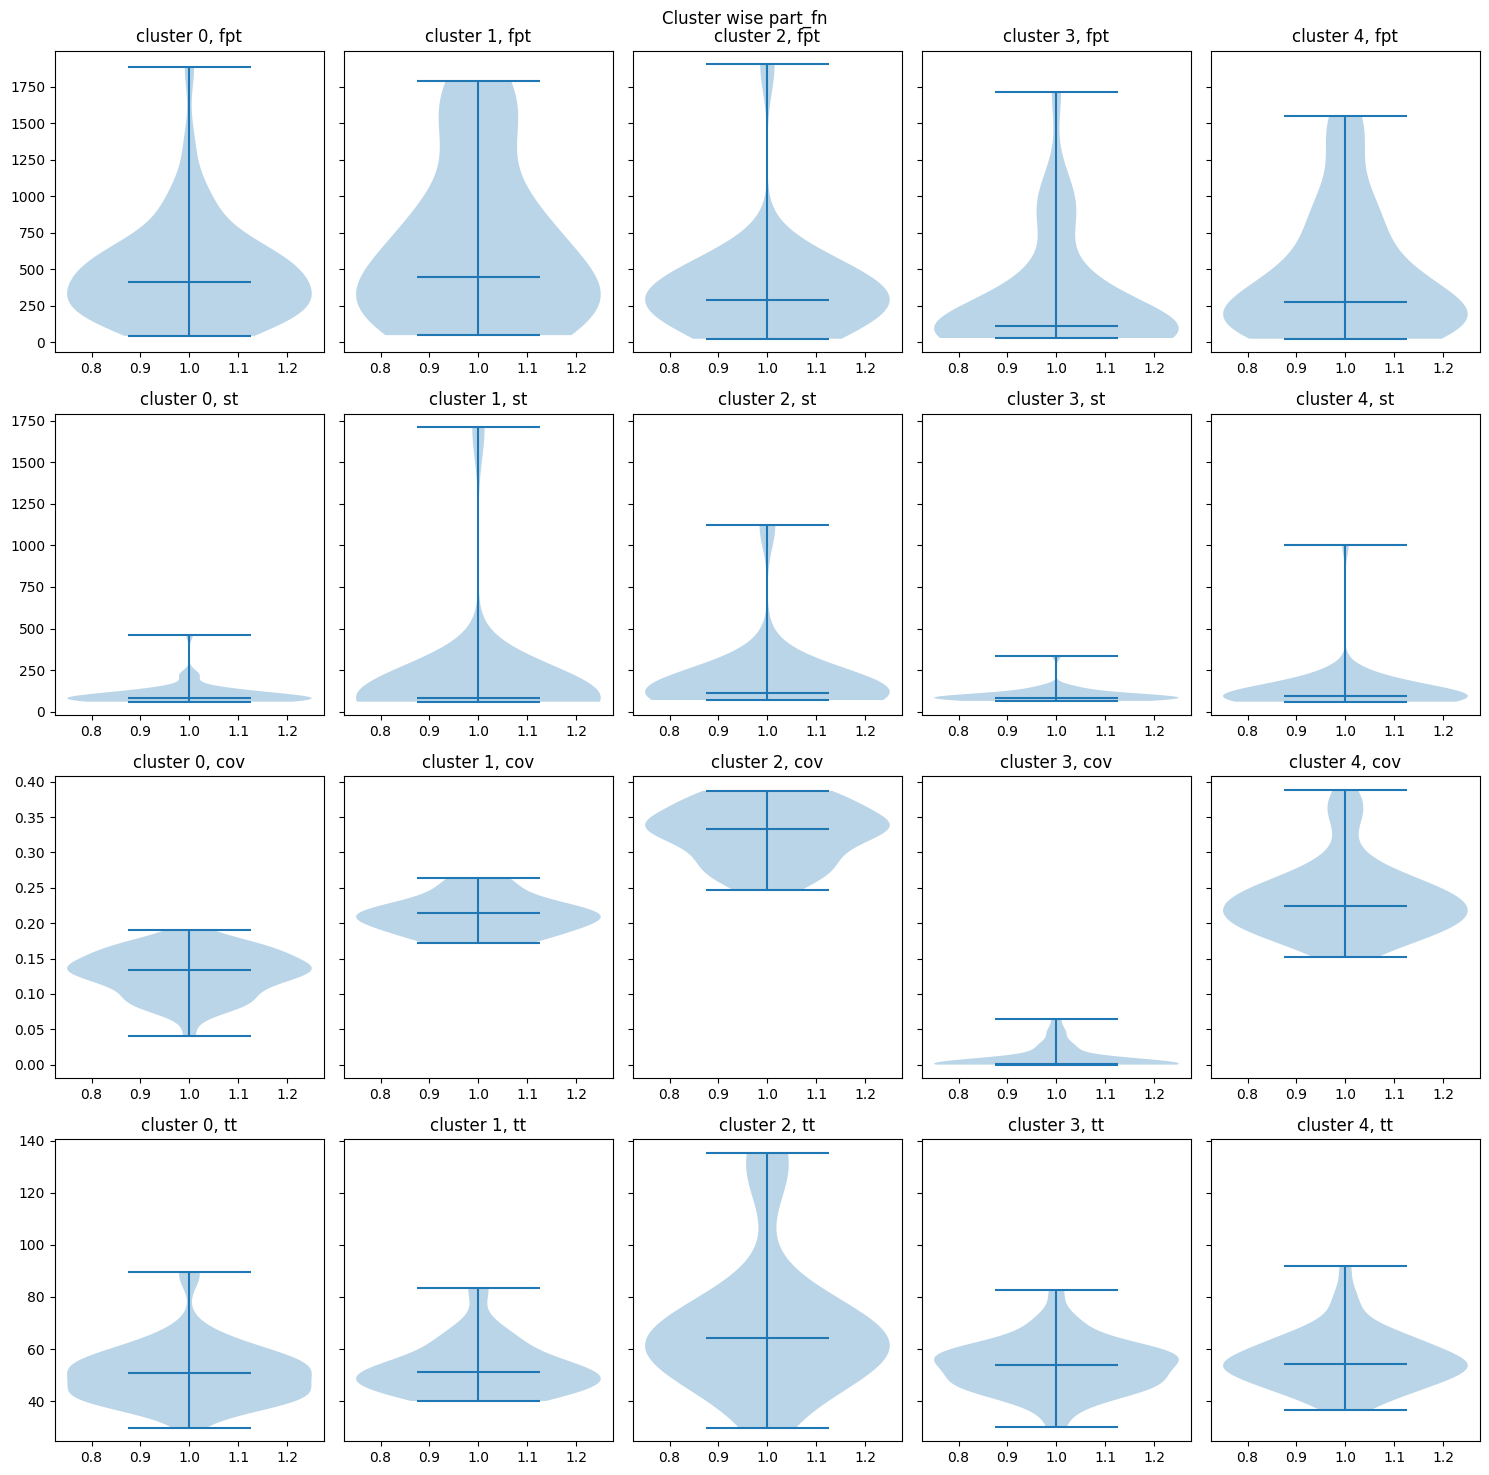

full_fn
full_lha


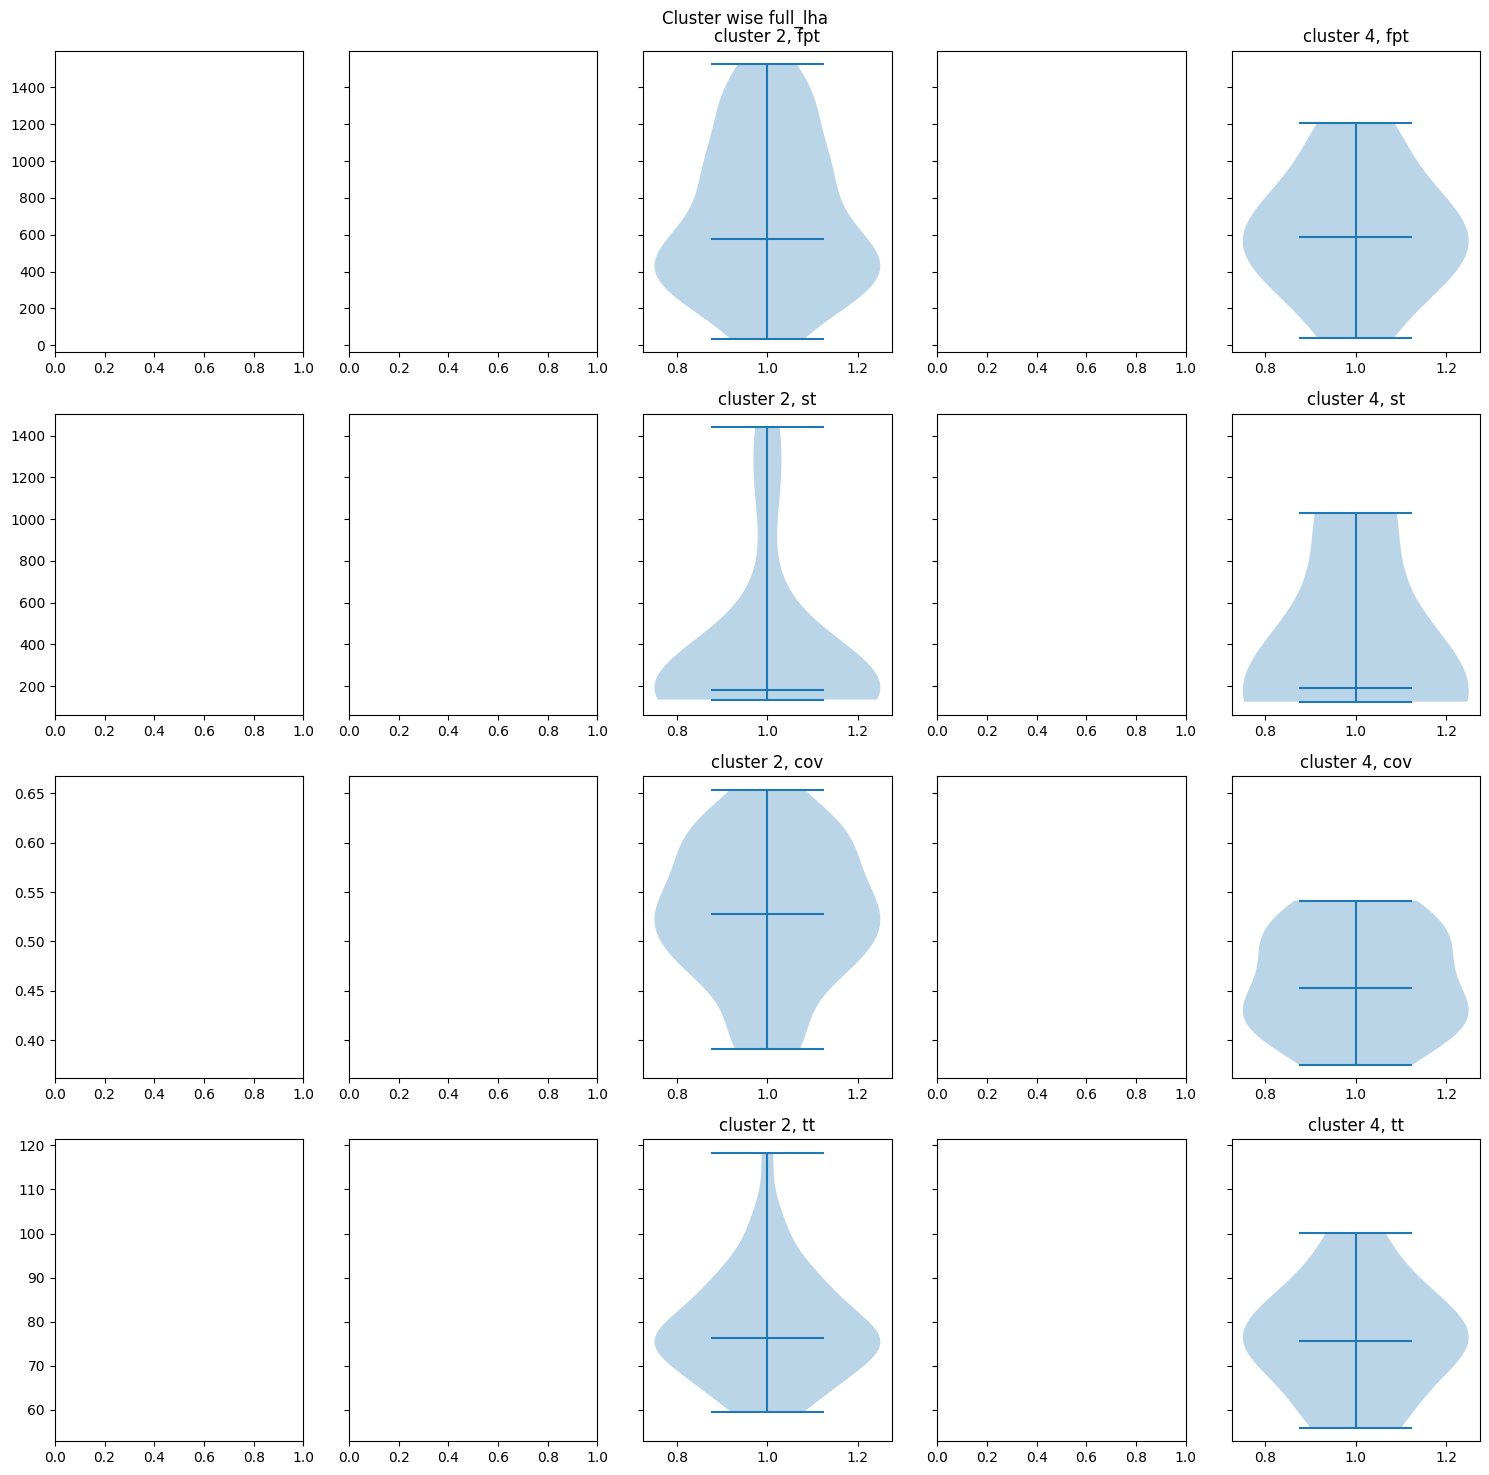

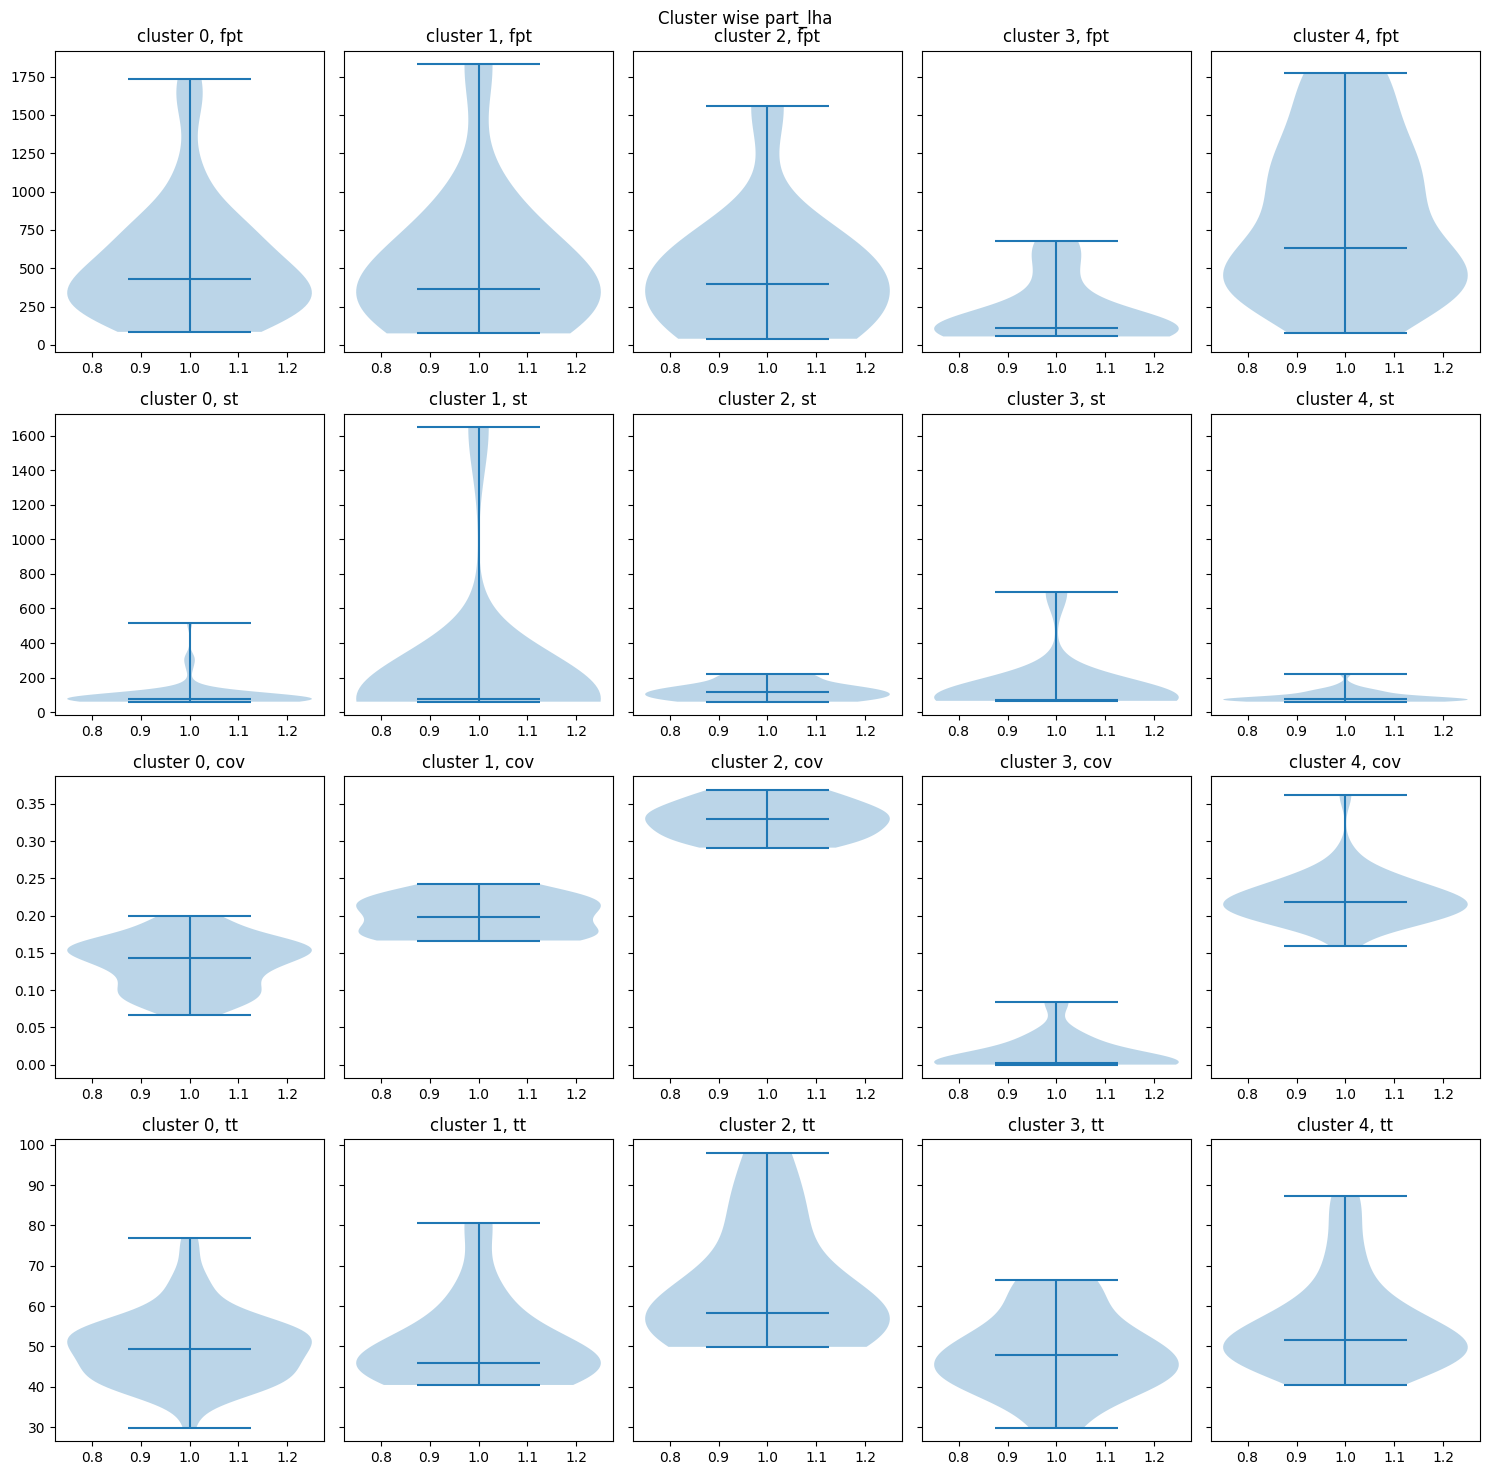

full_lha
full_lsc


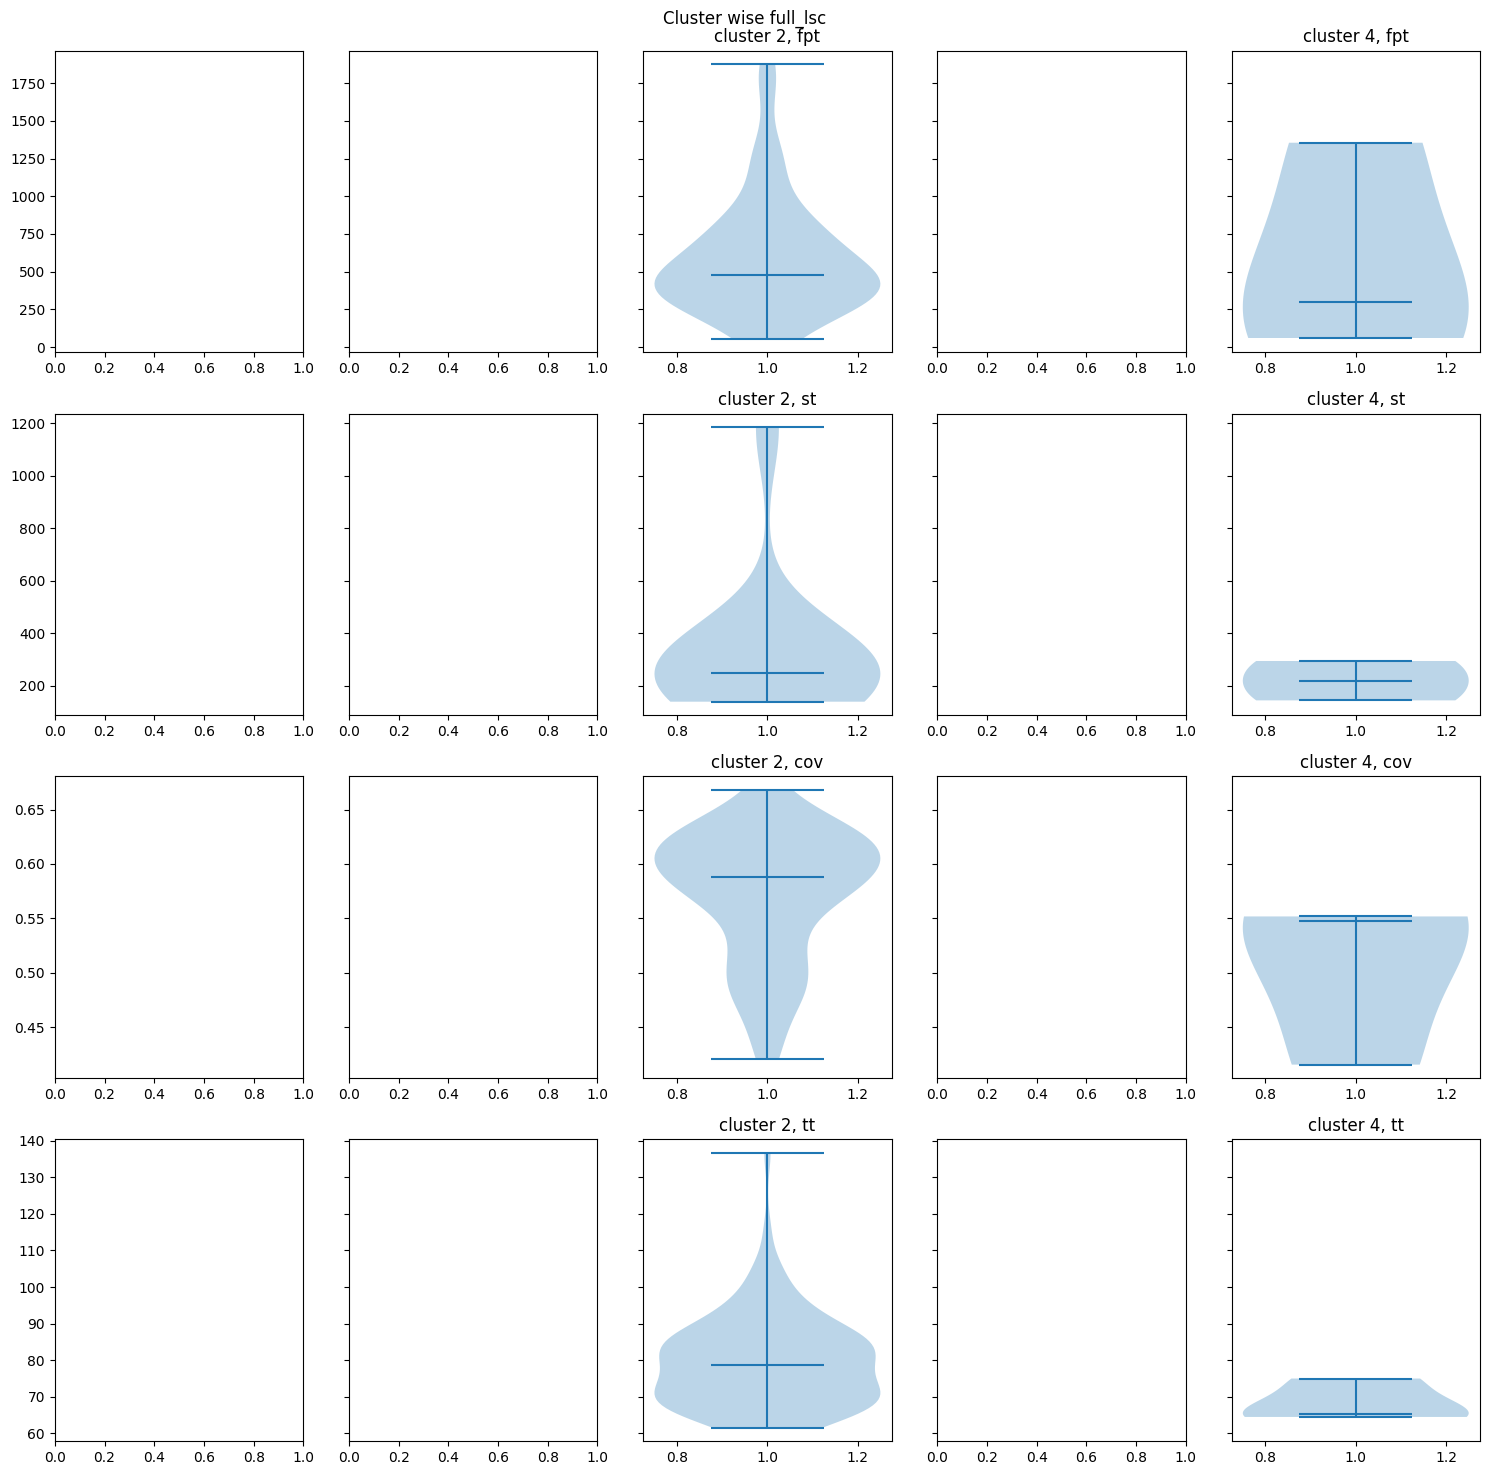

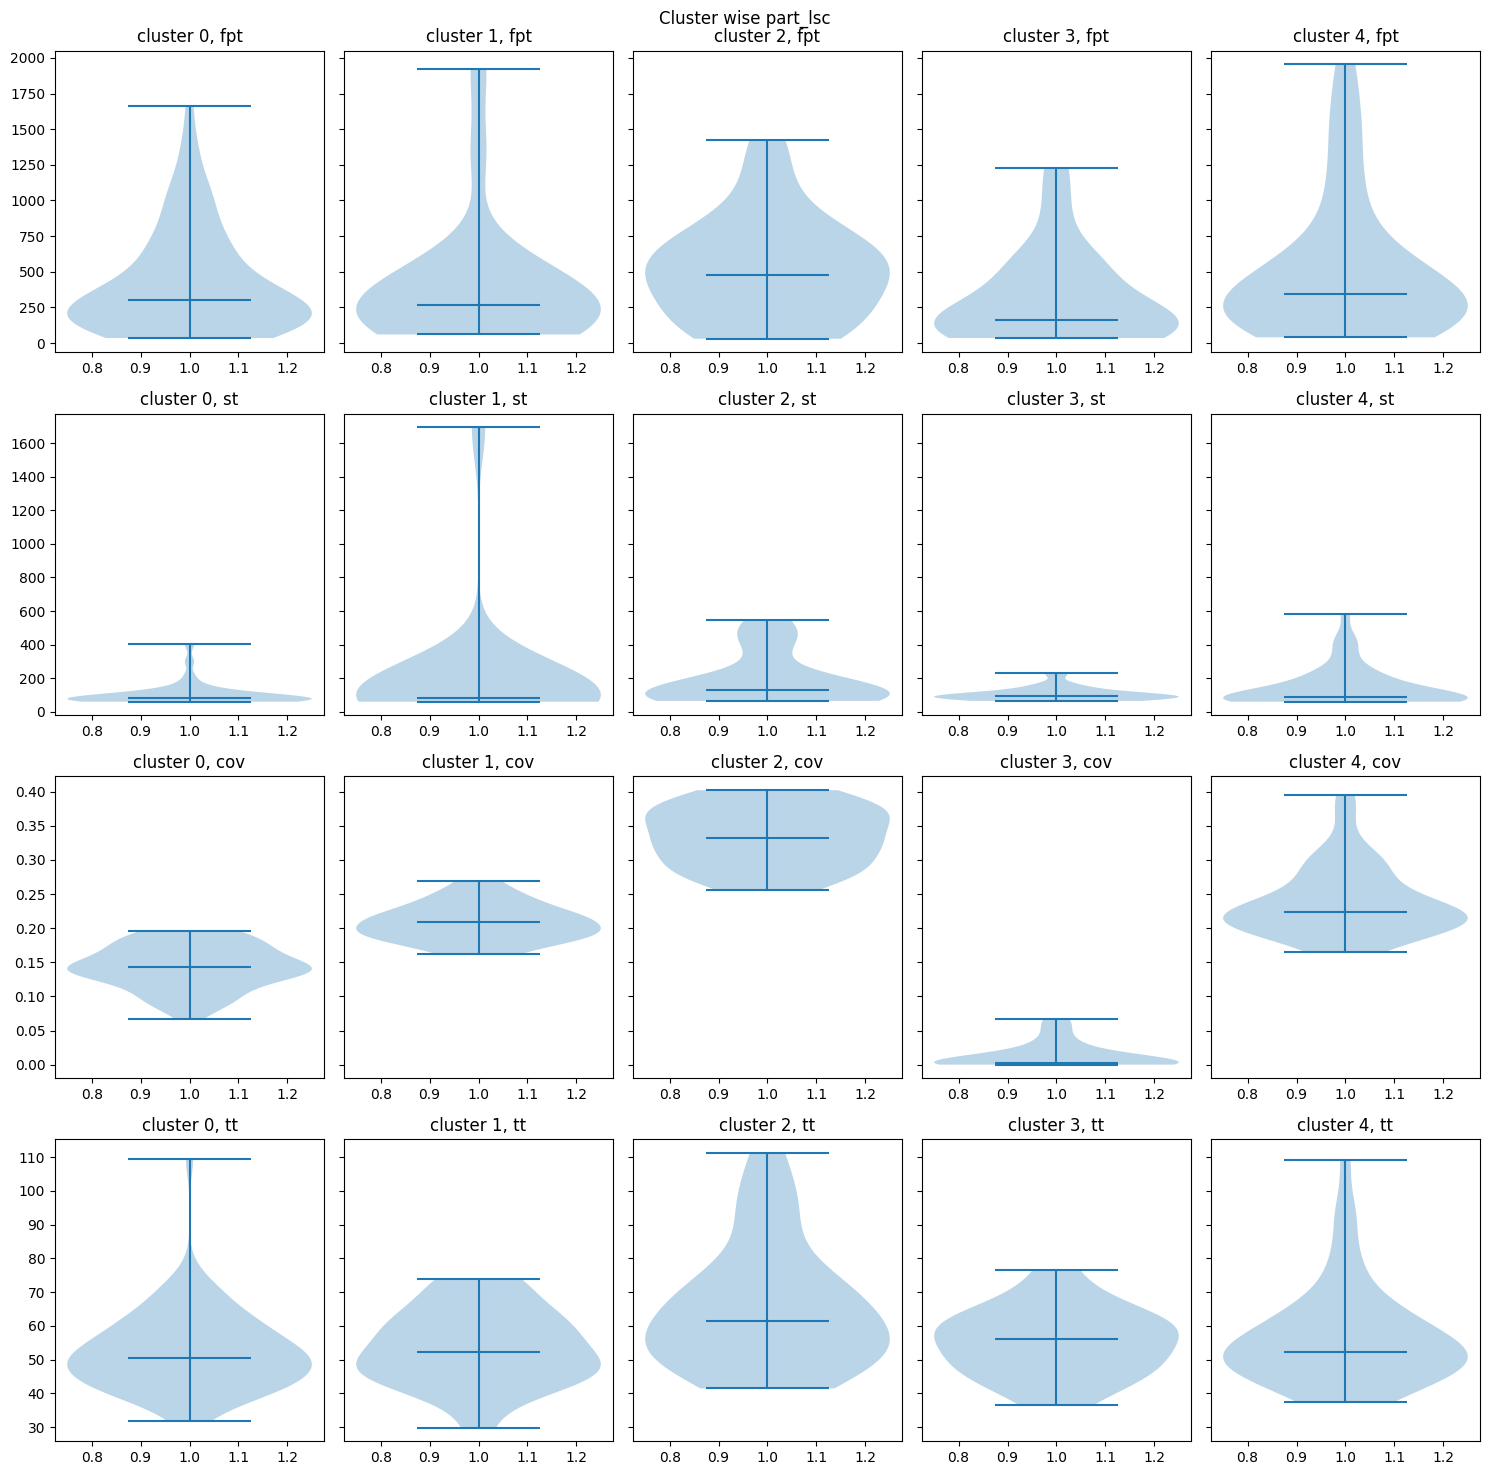

full_lsc
full_mob


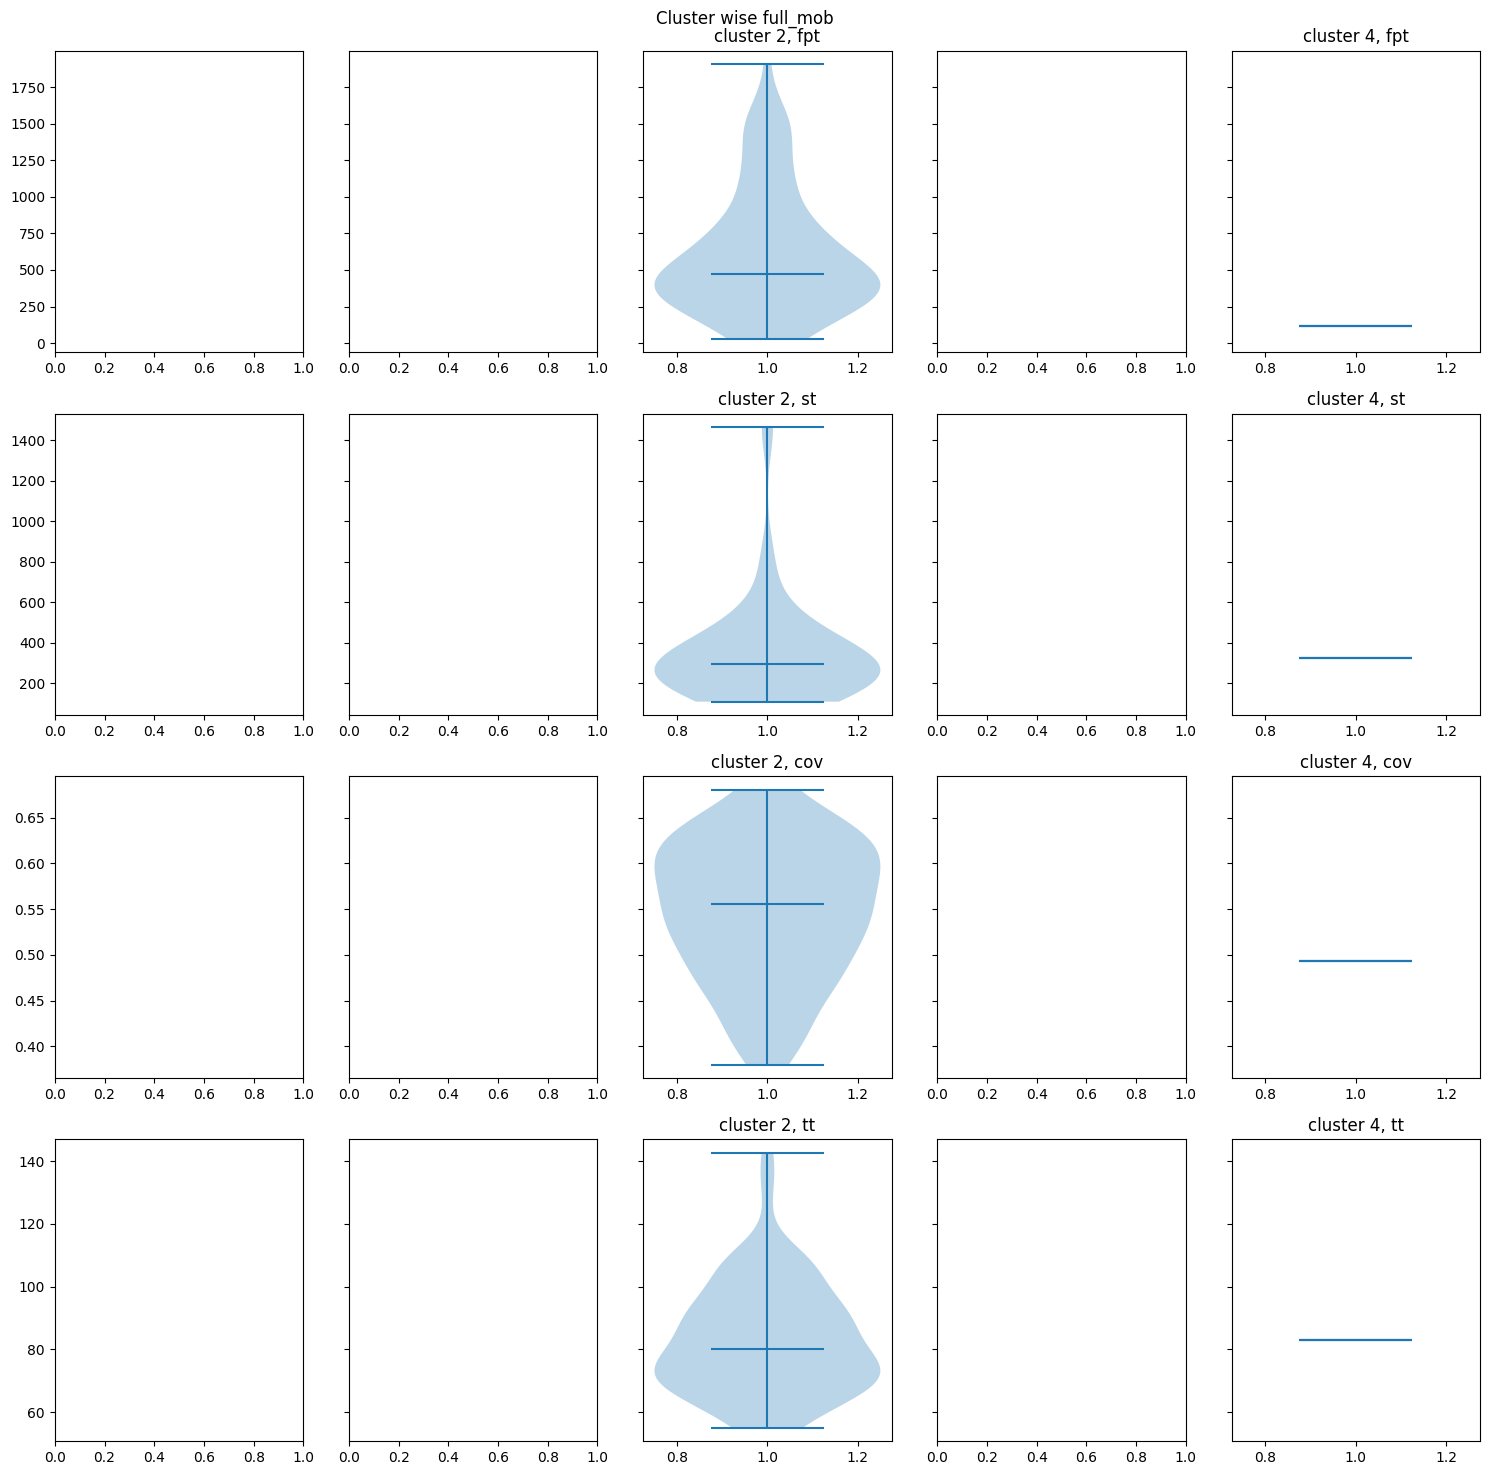

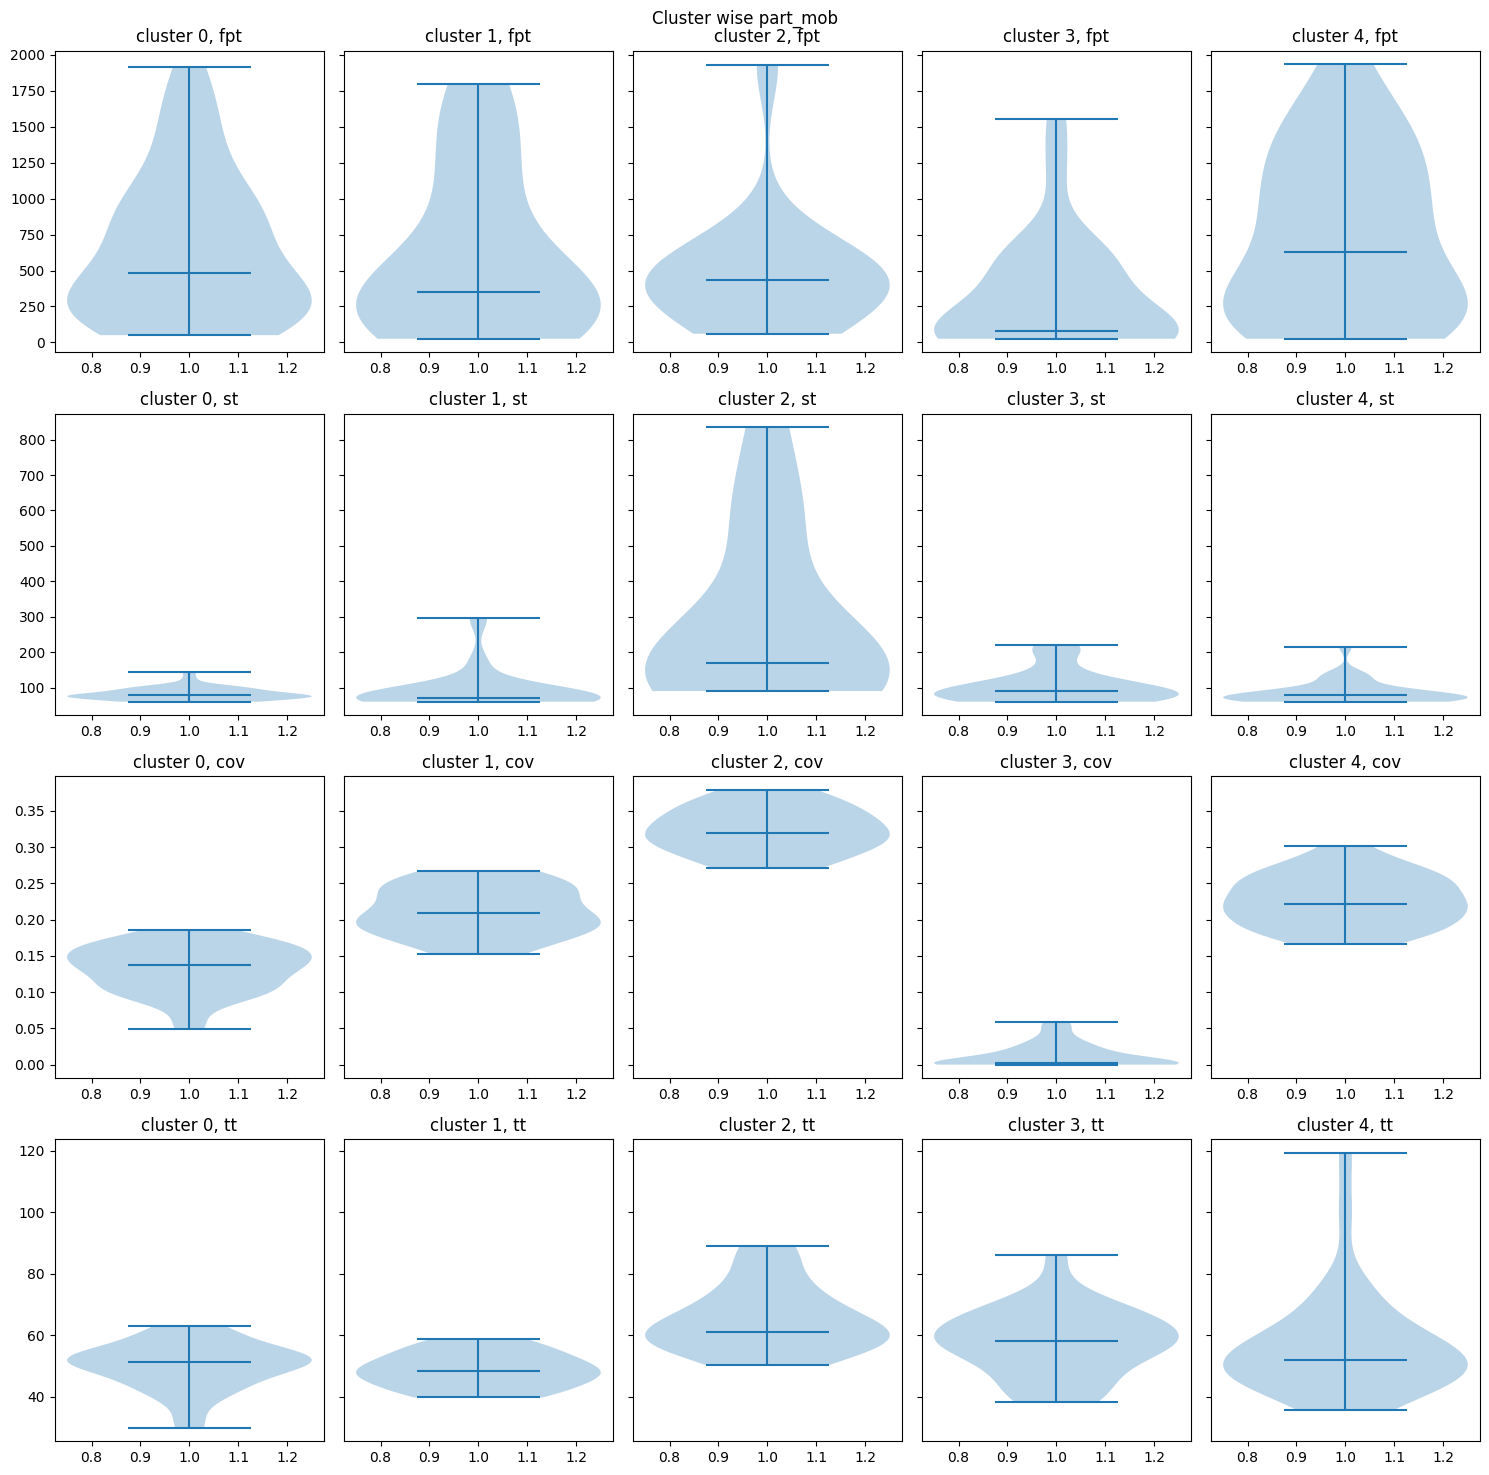

full_mob
full_mop


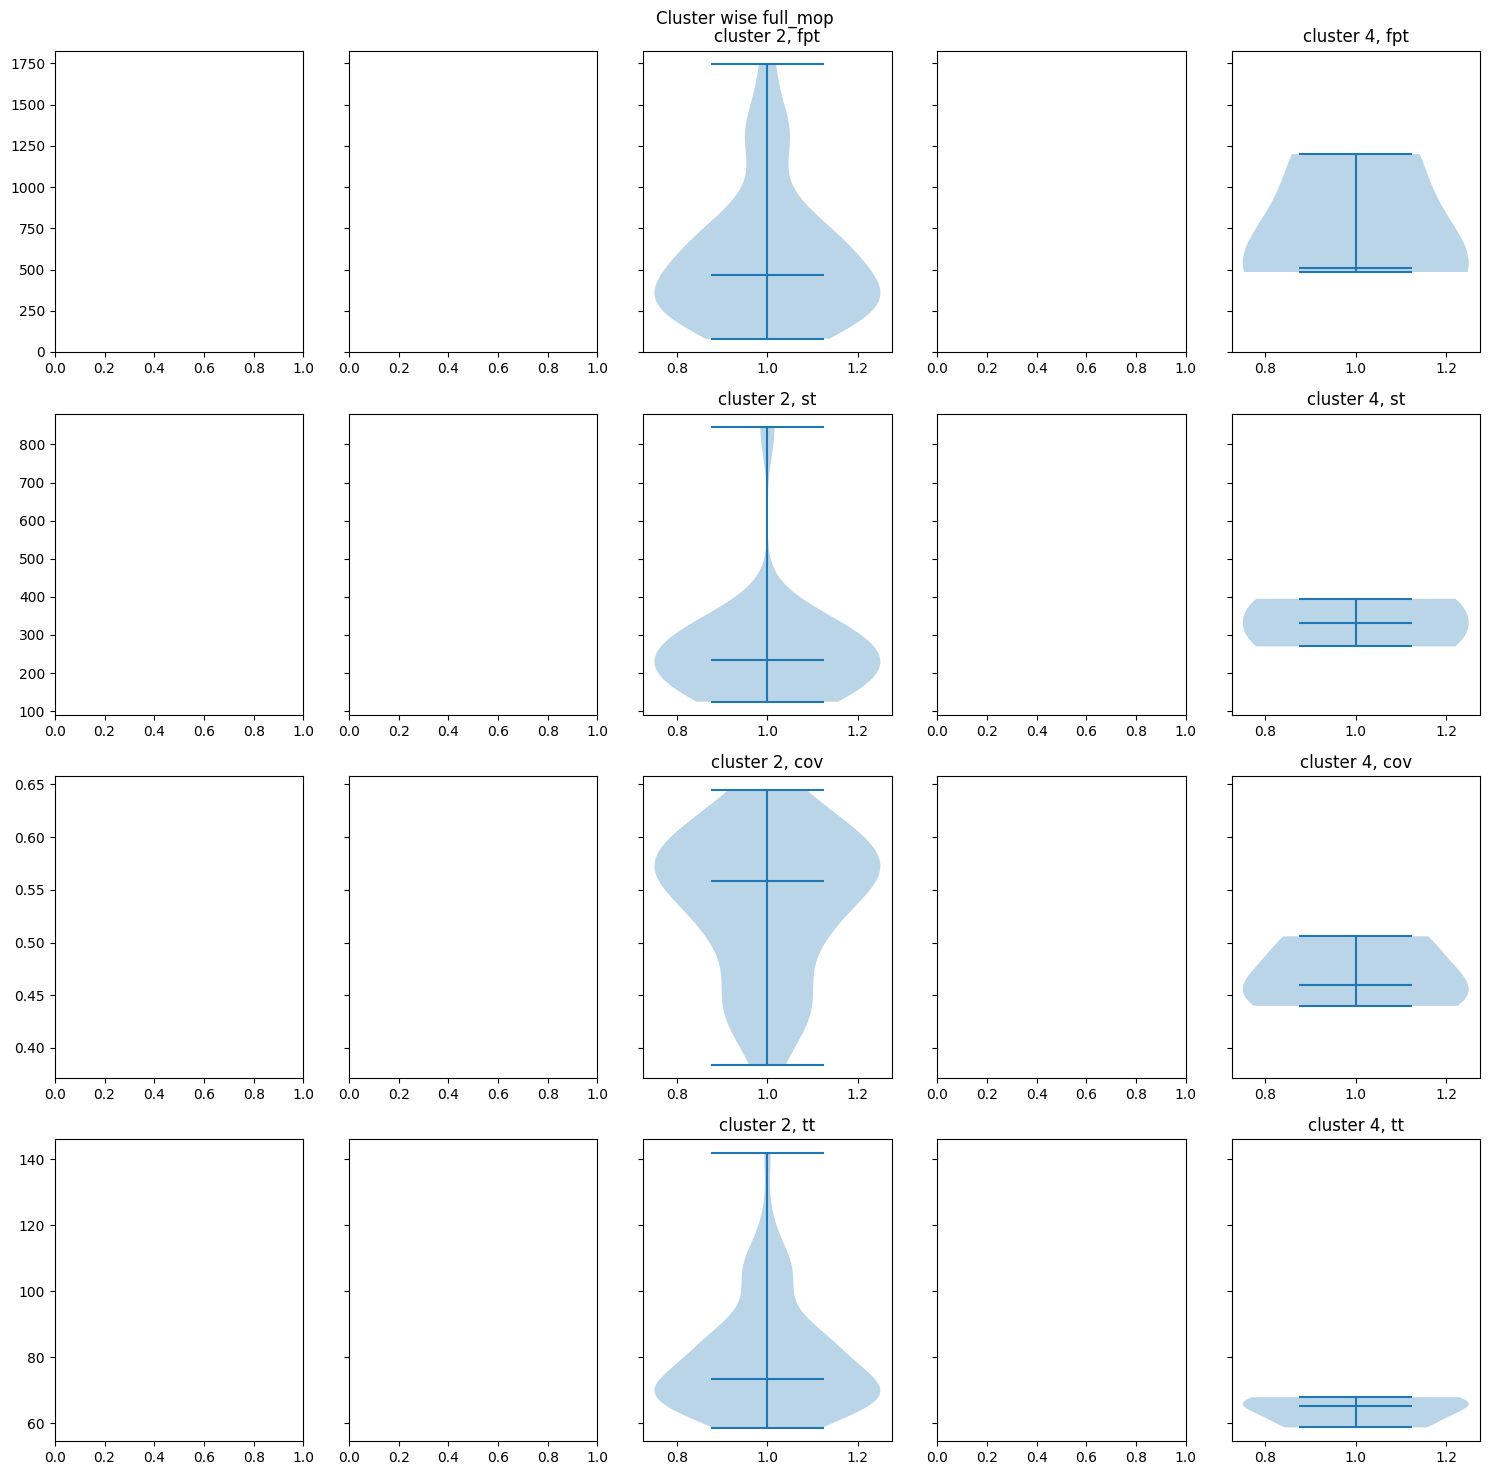

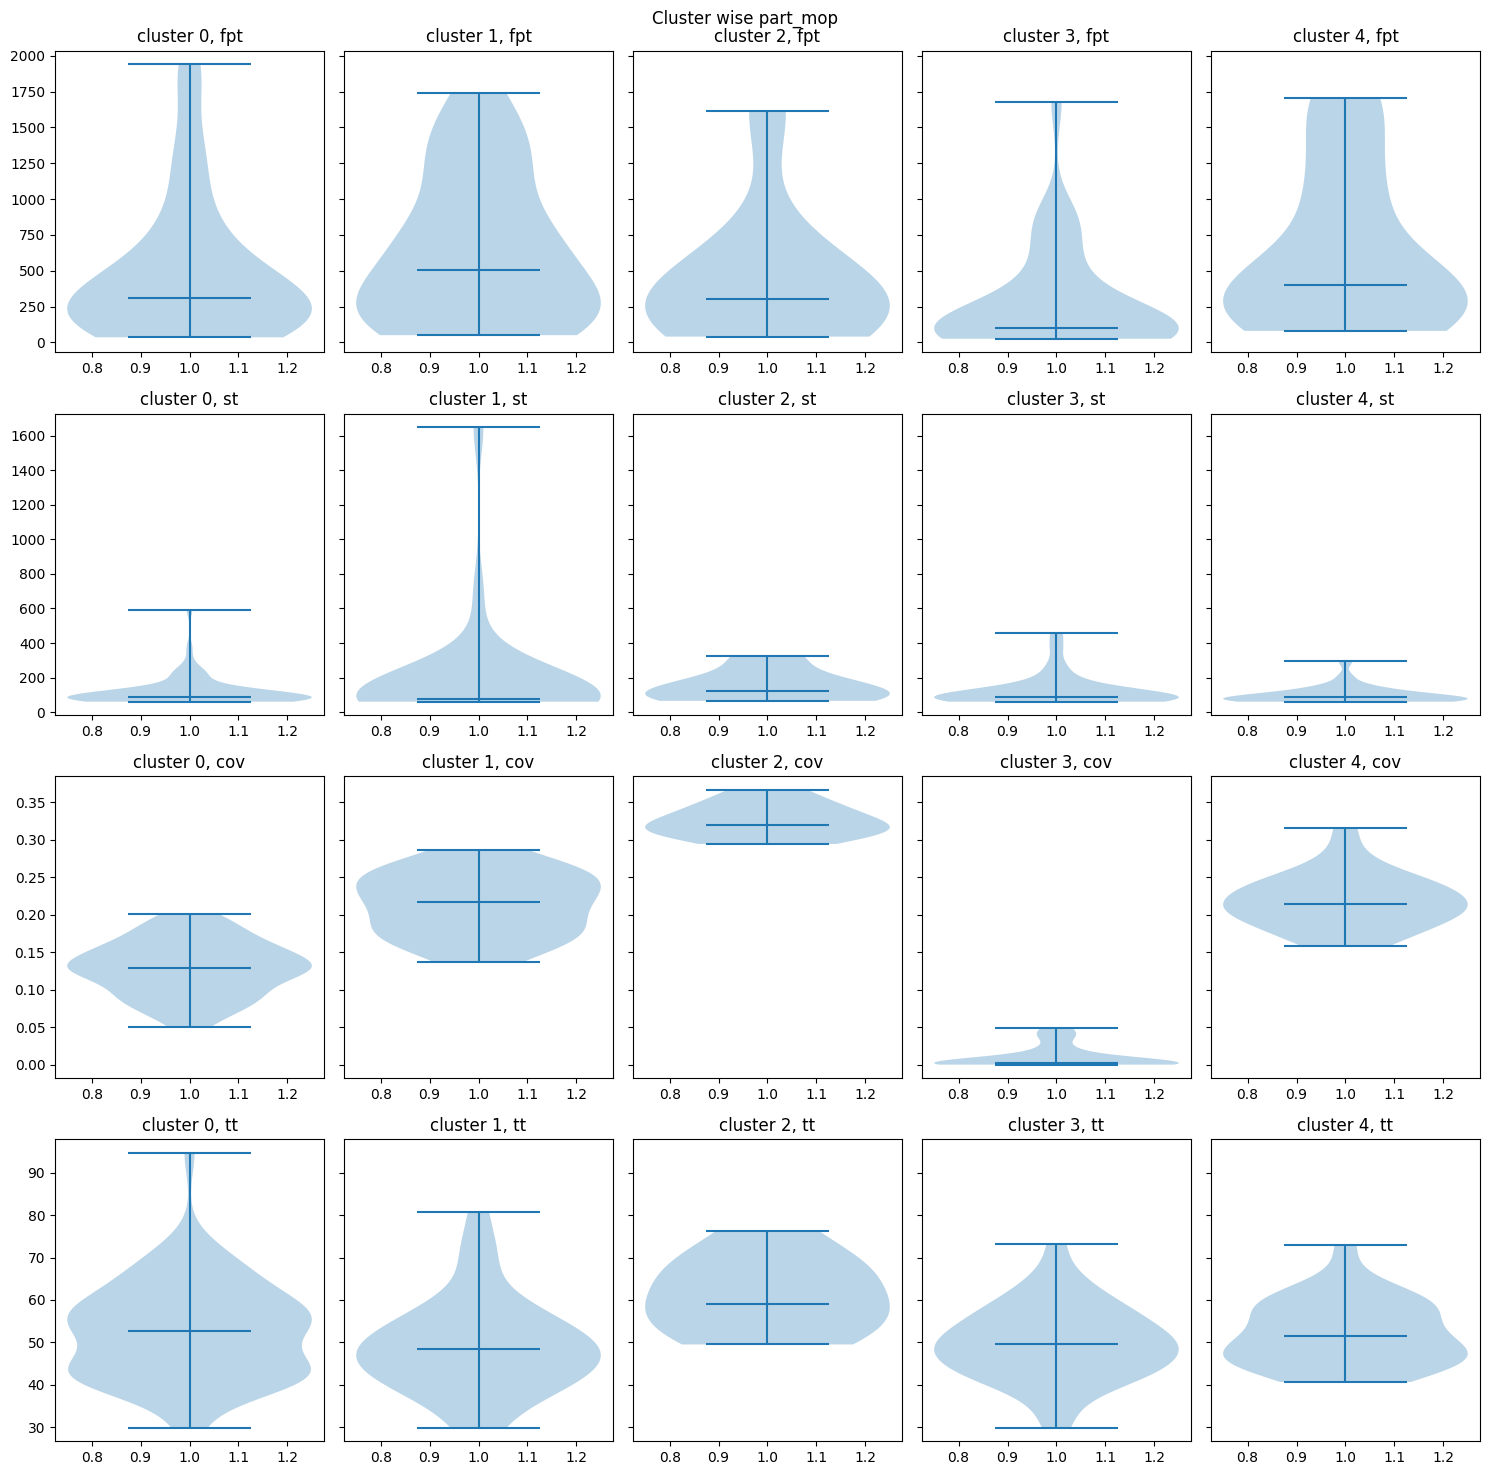

full_mop
full_mos


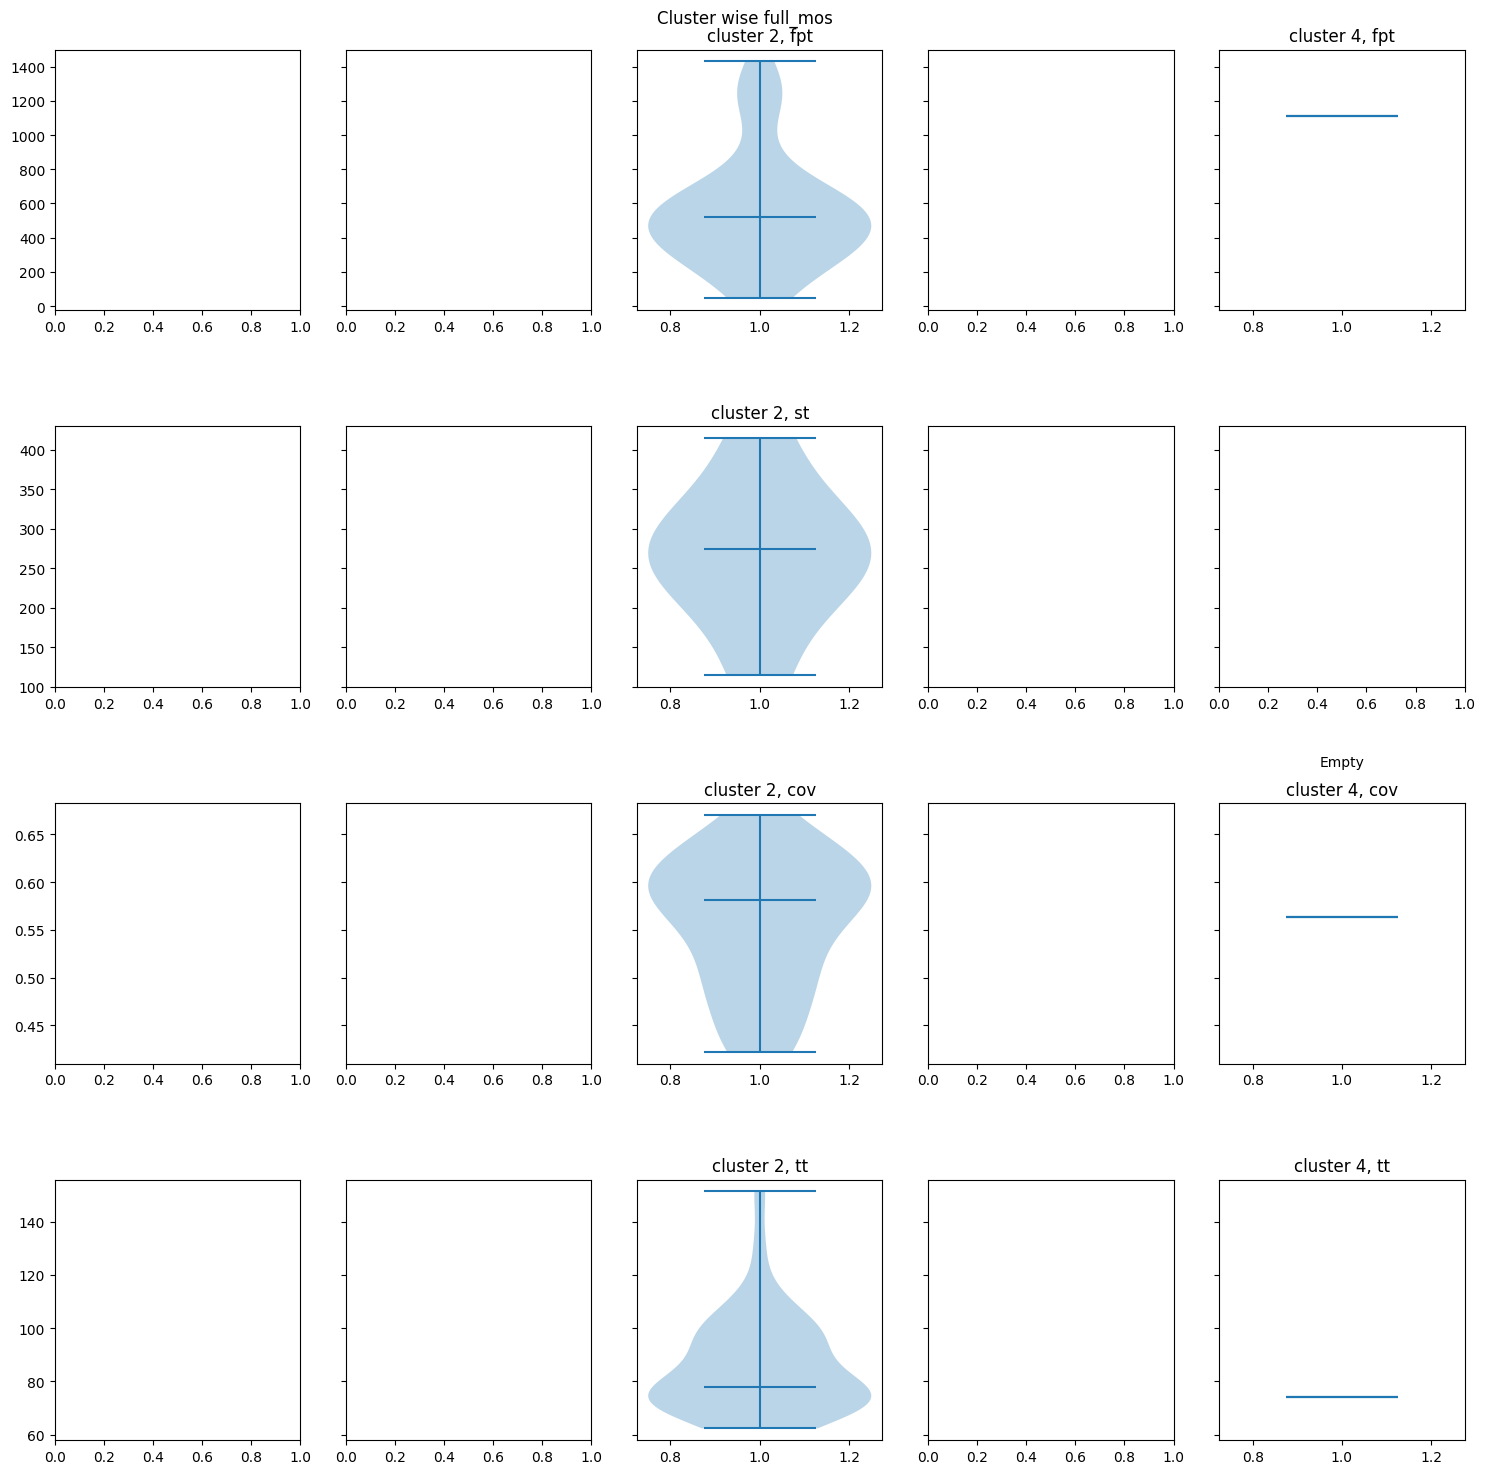

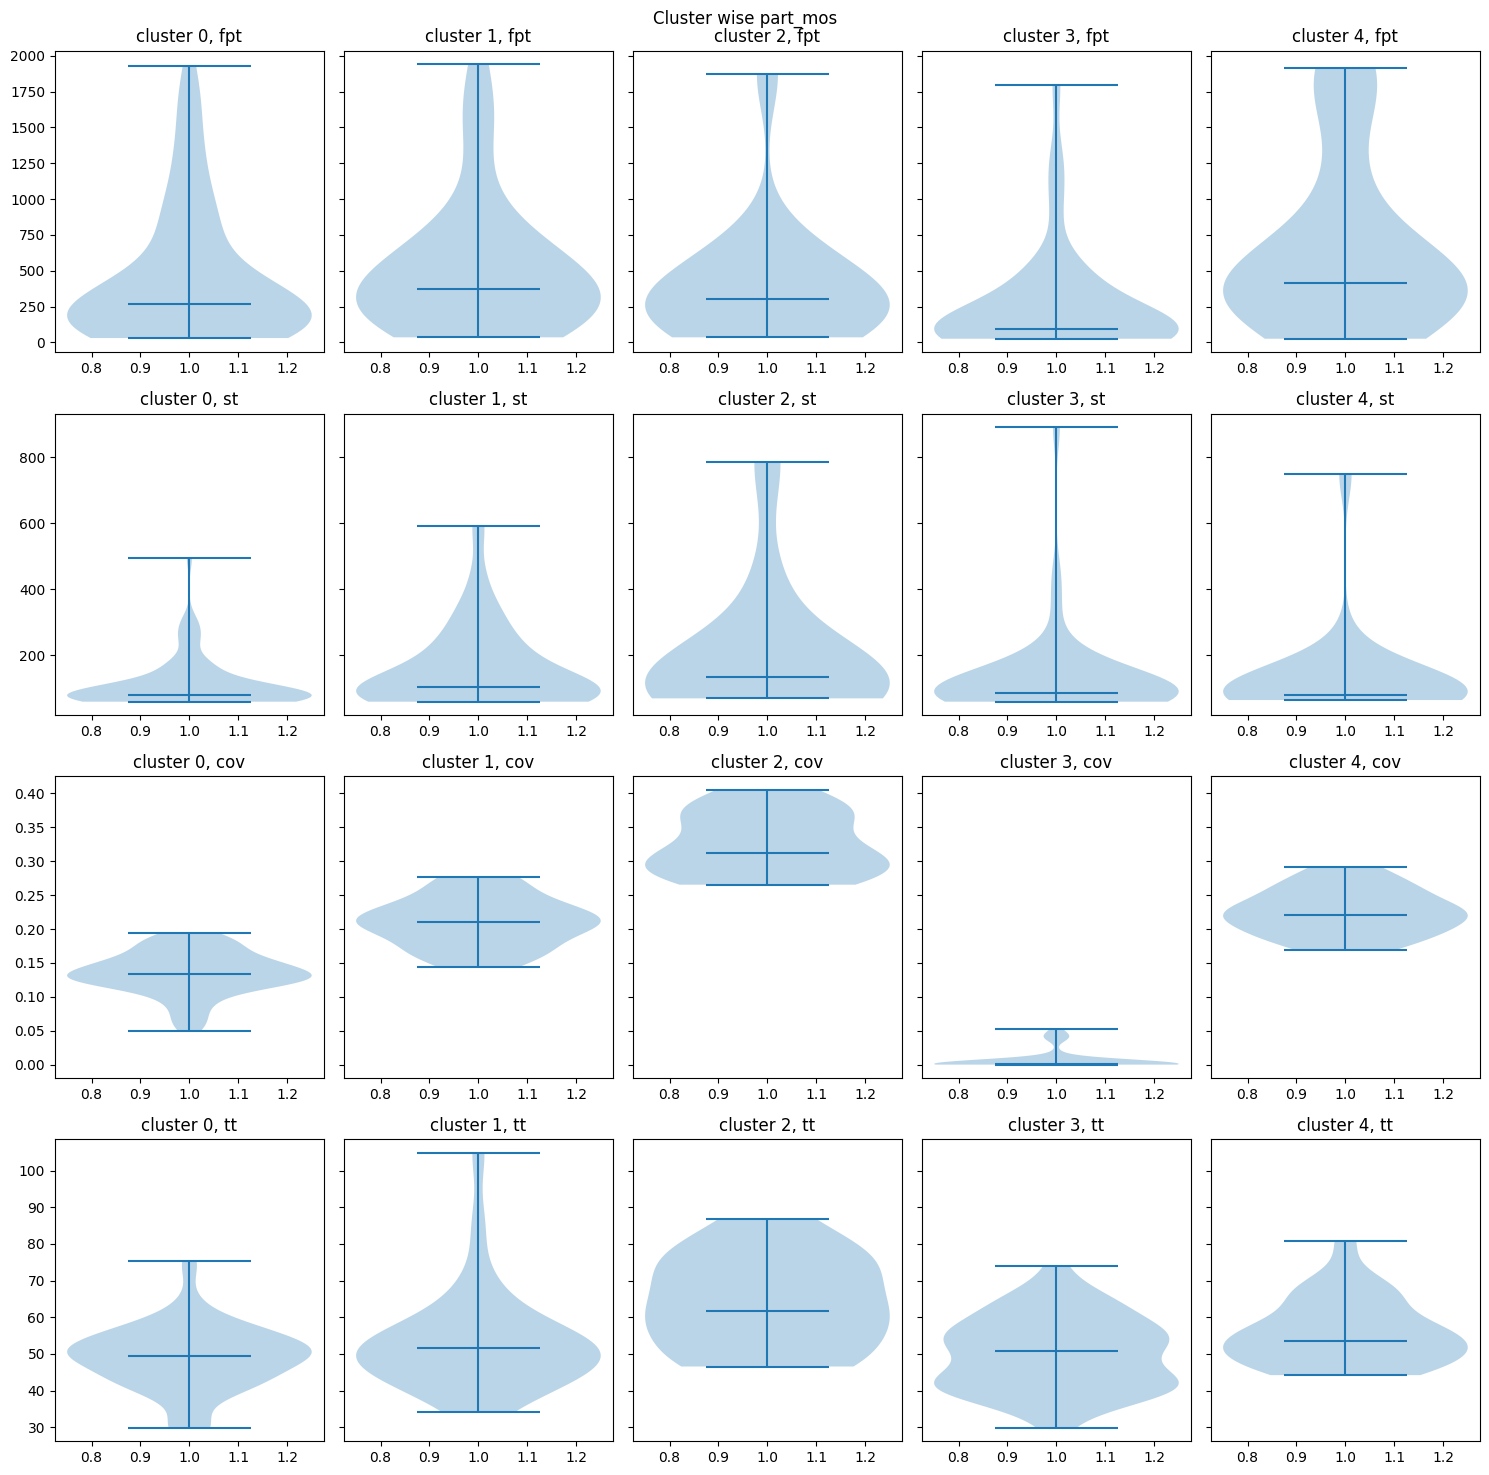

full_mos
full_mrn


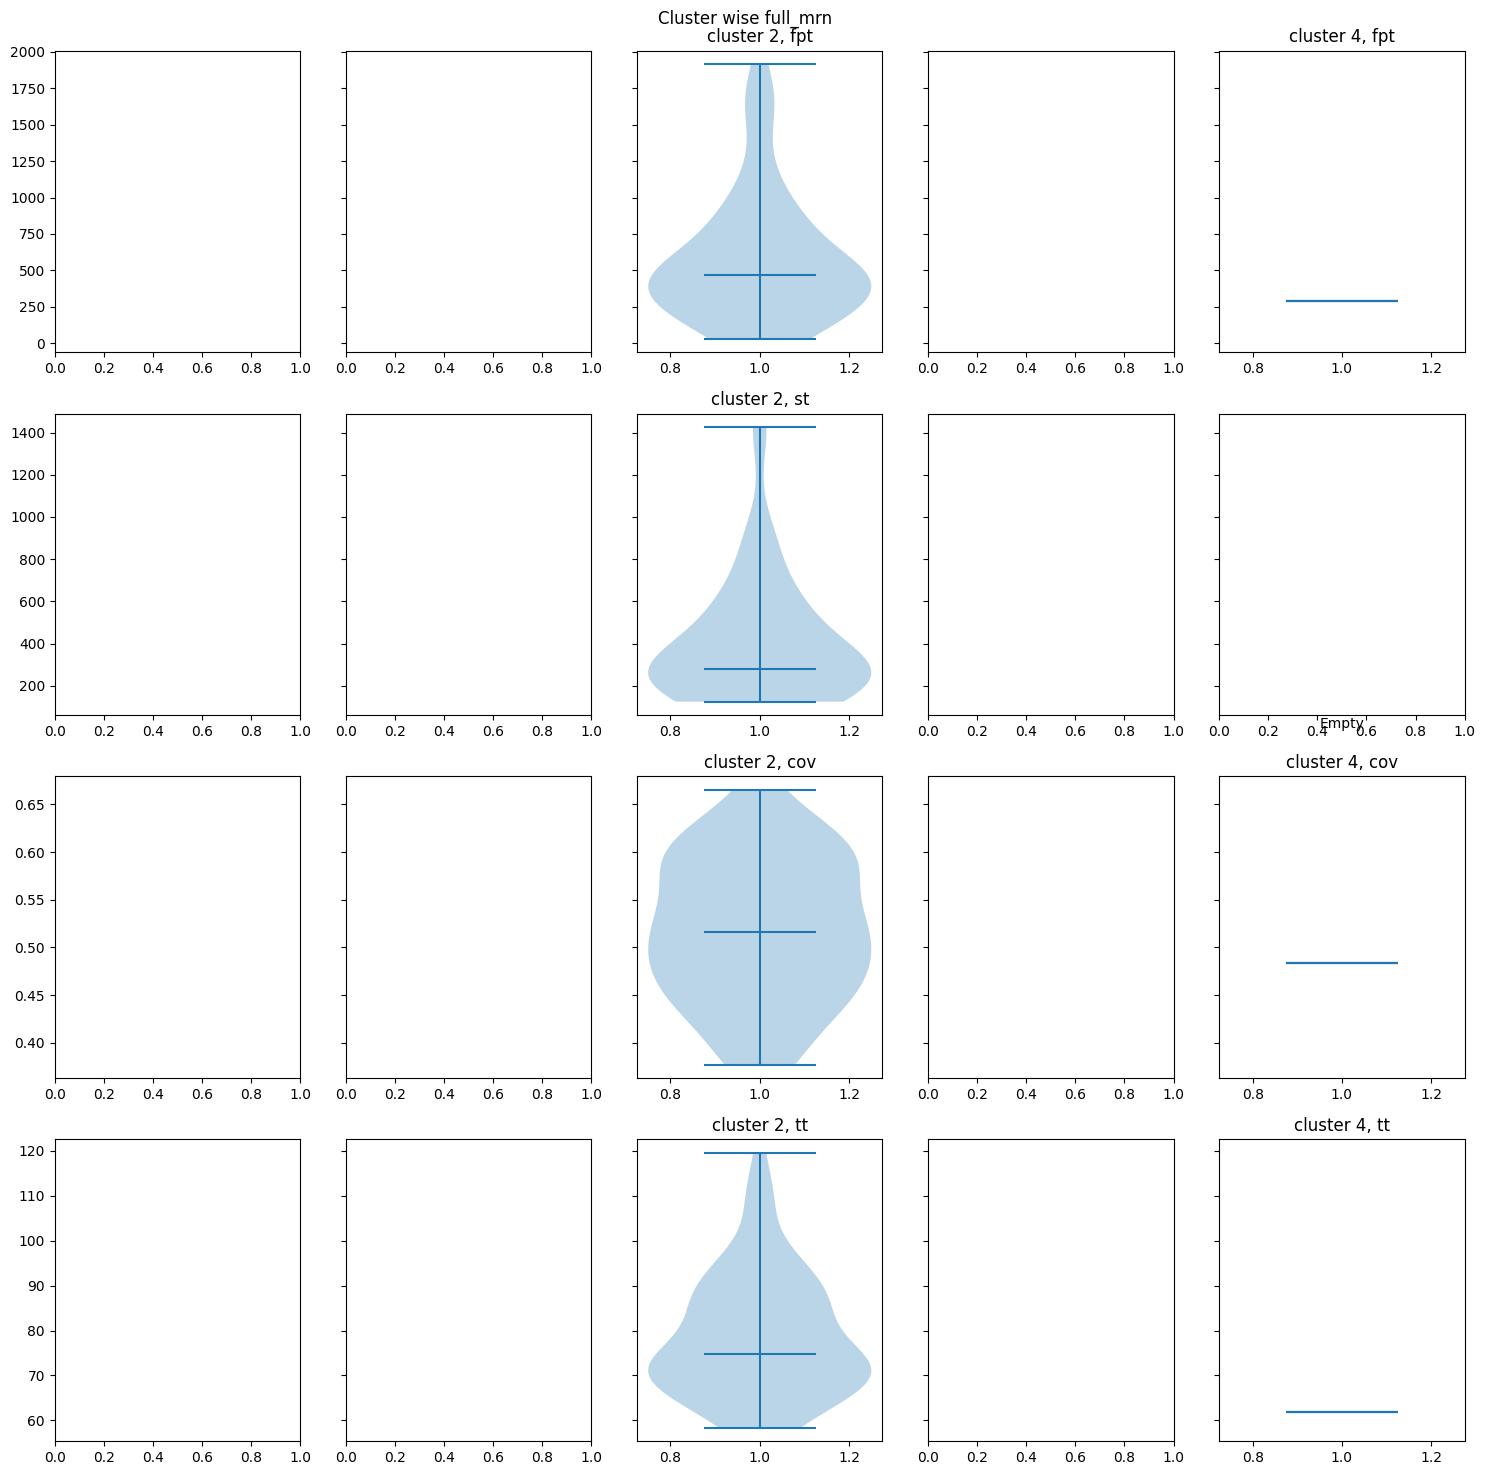

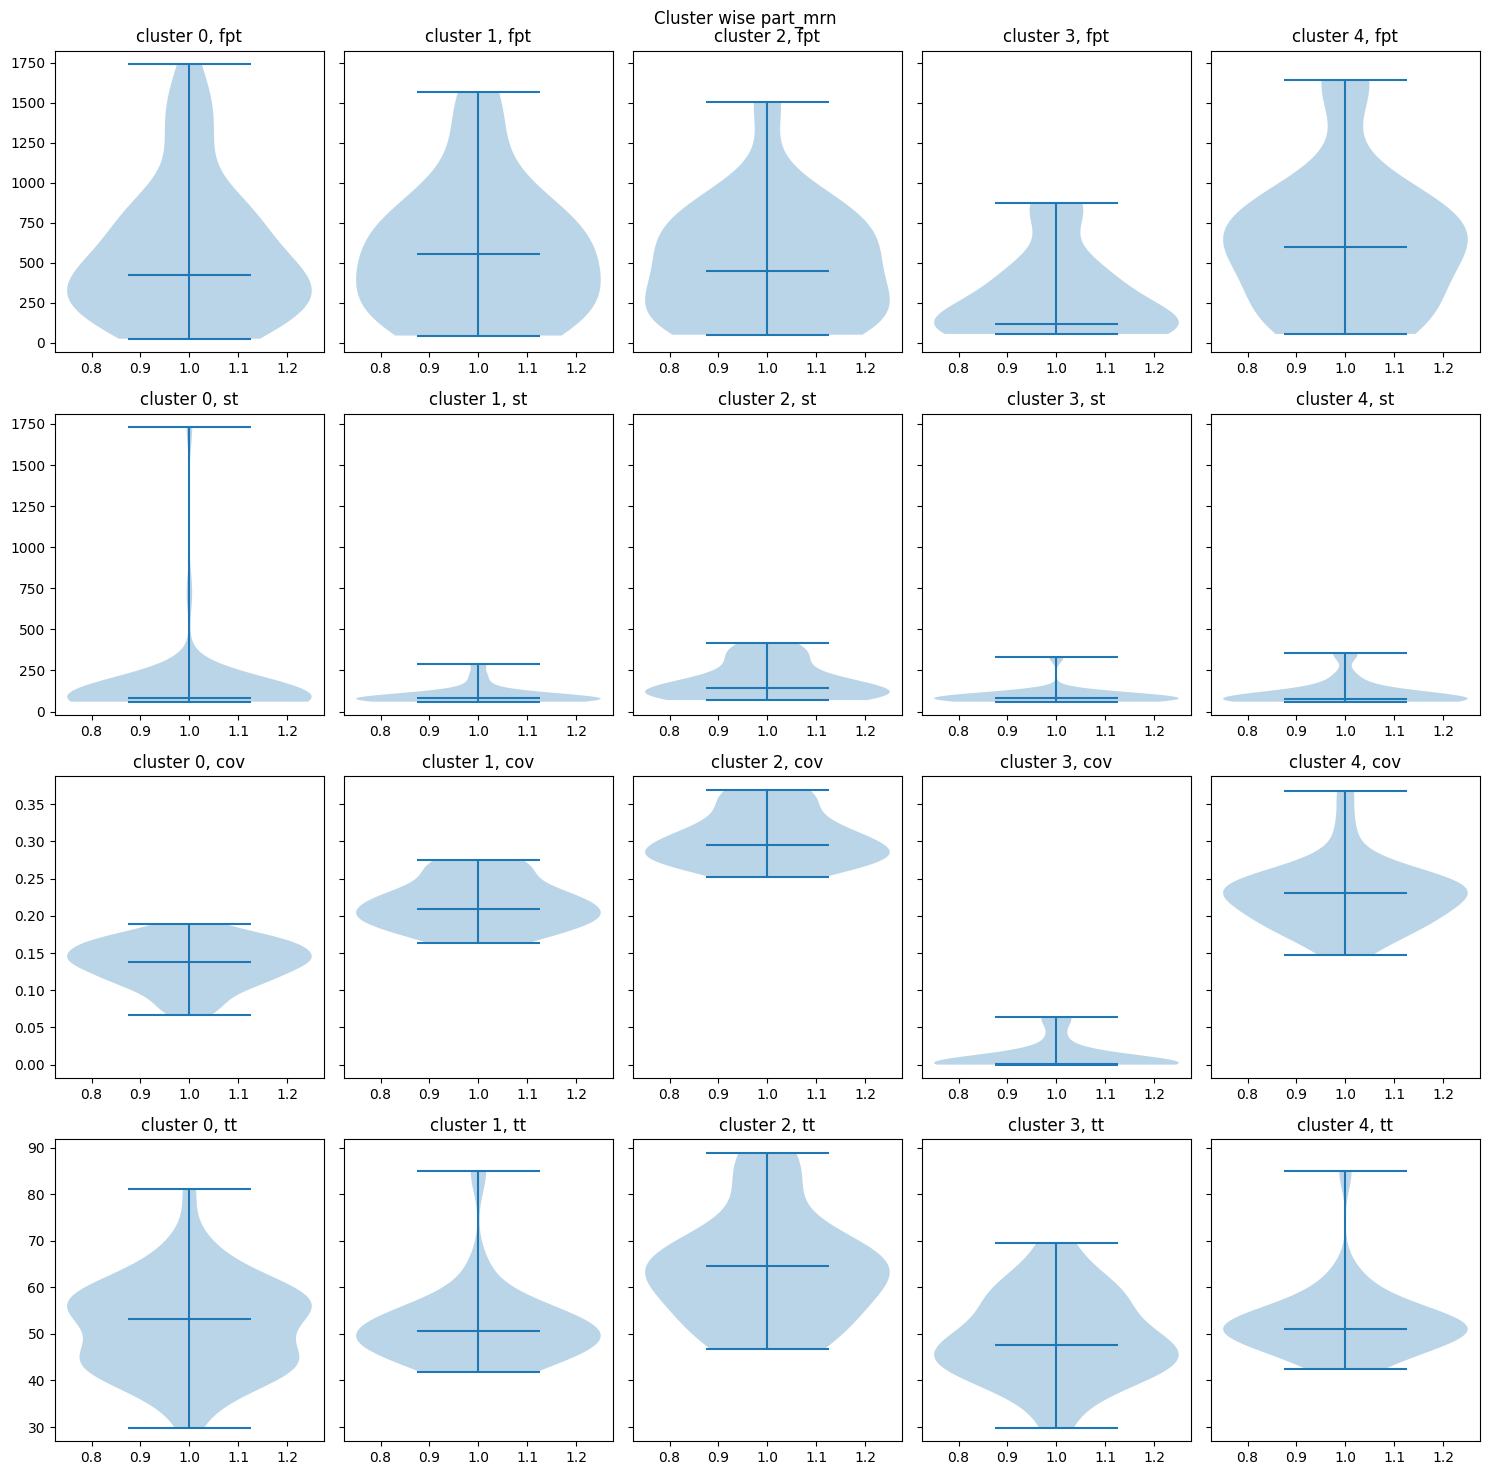

full_mrn
full_orb


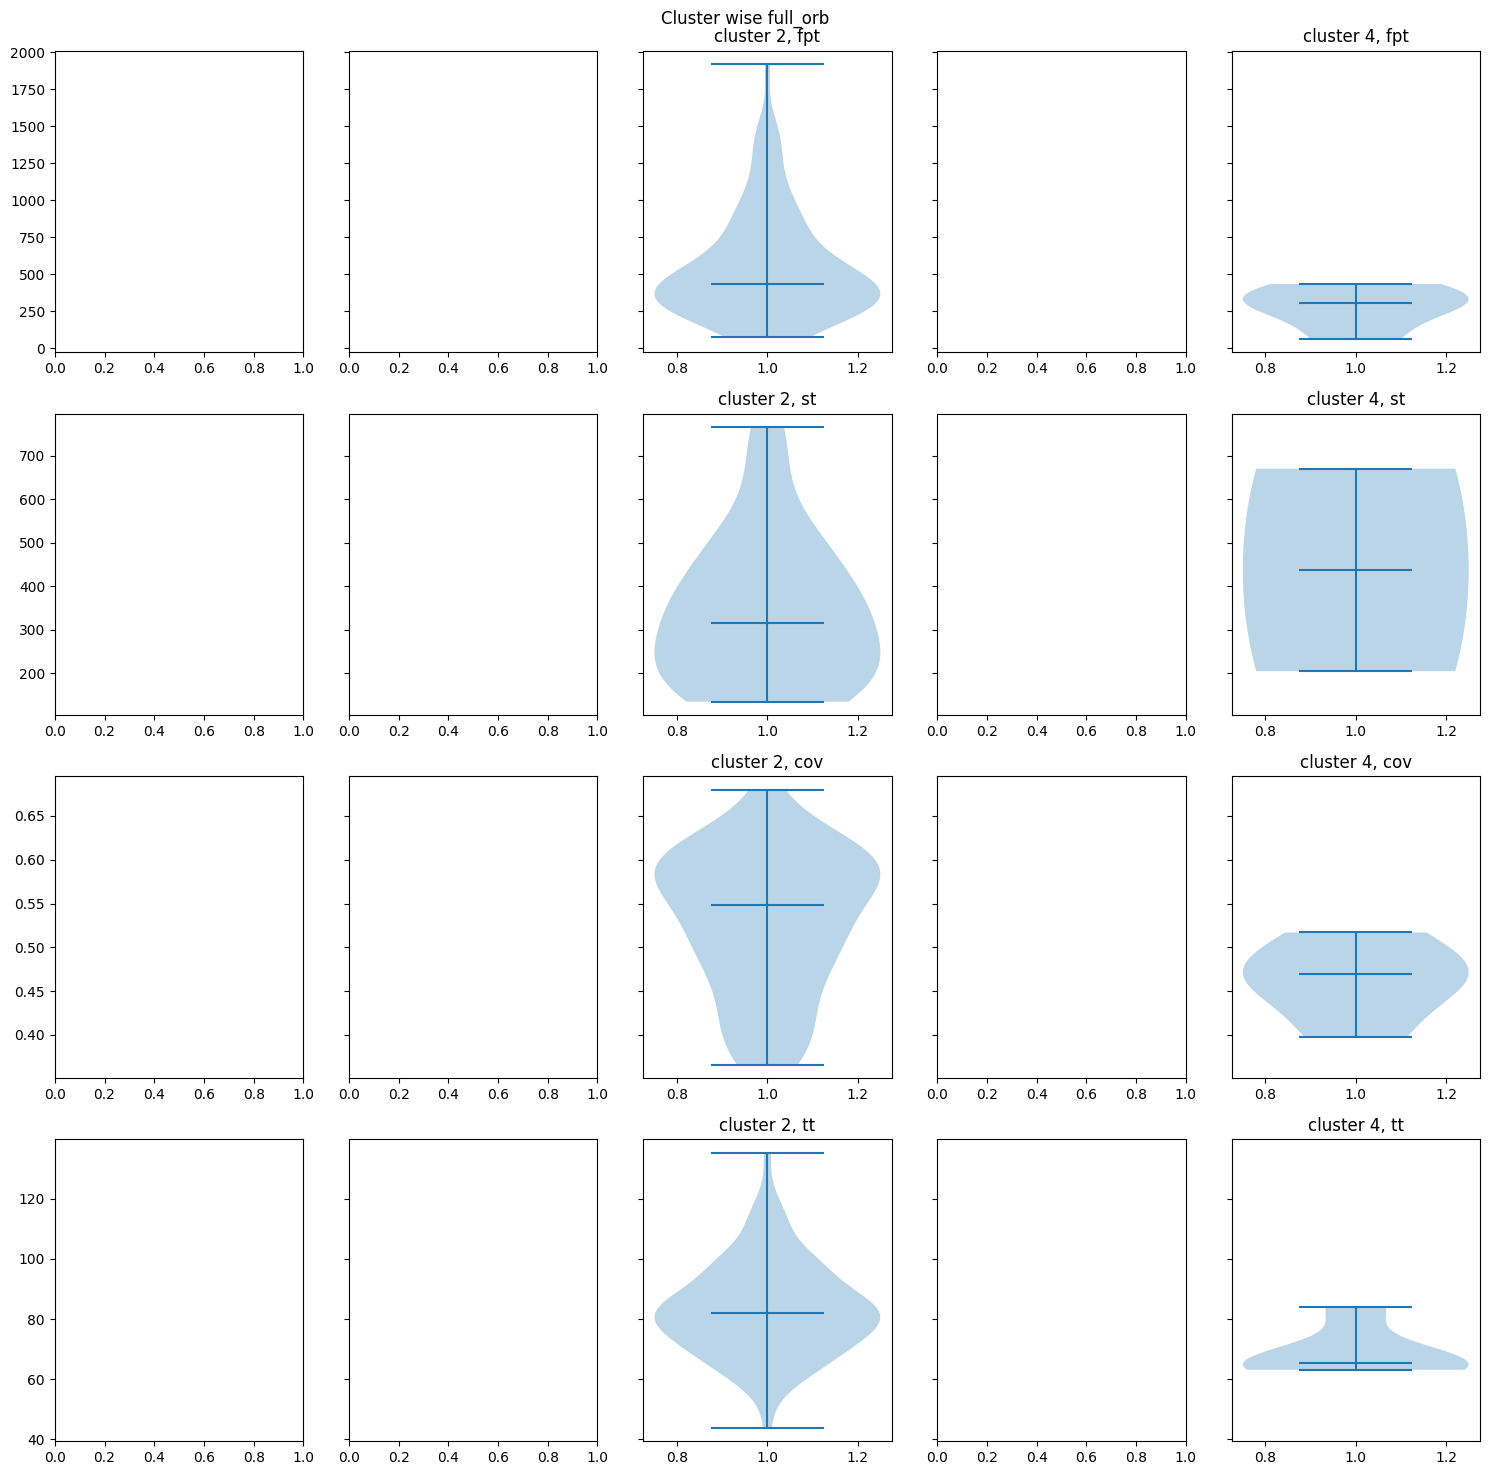

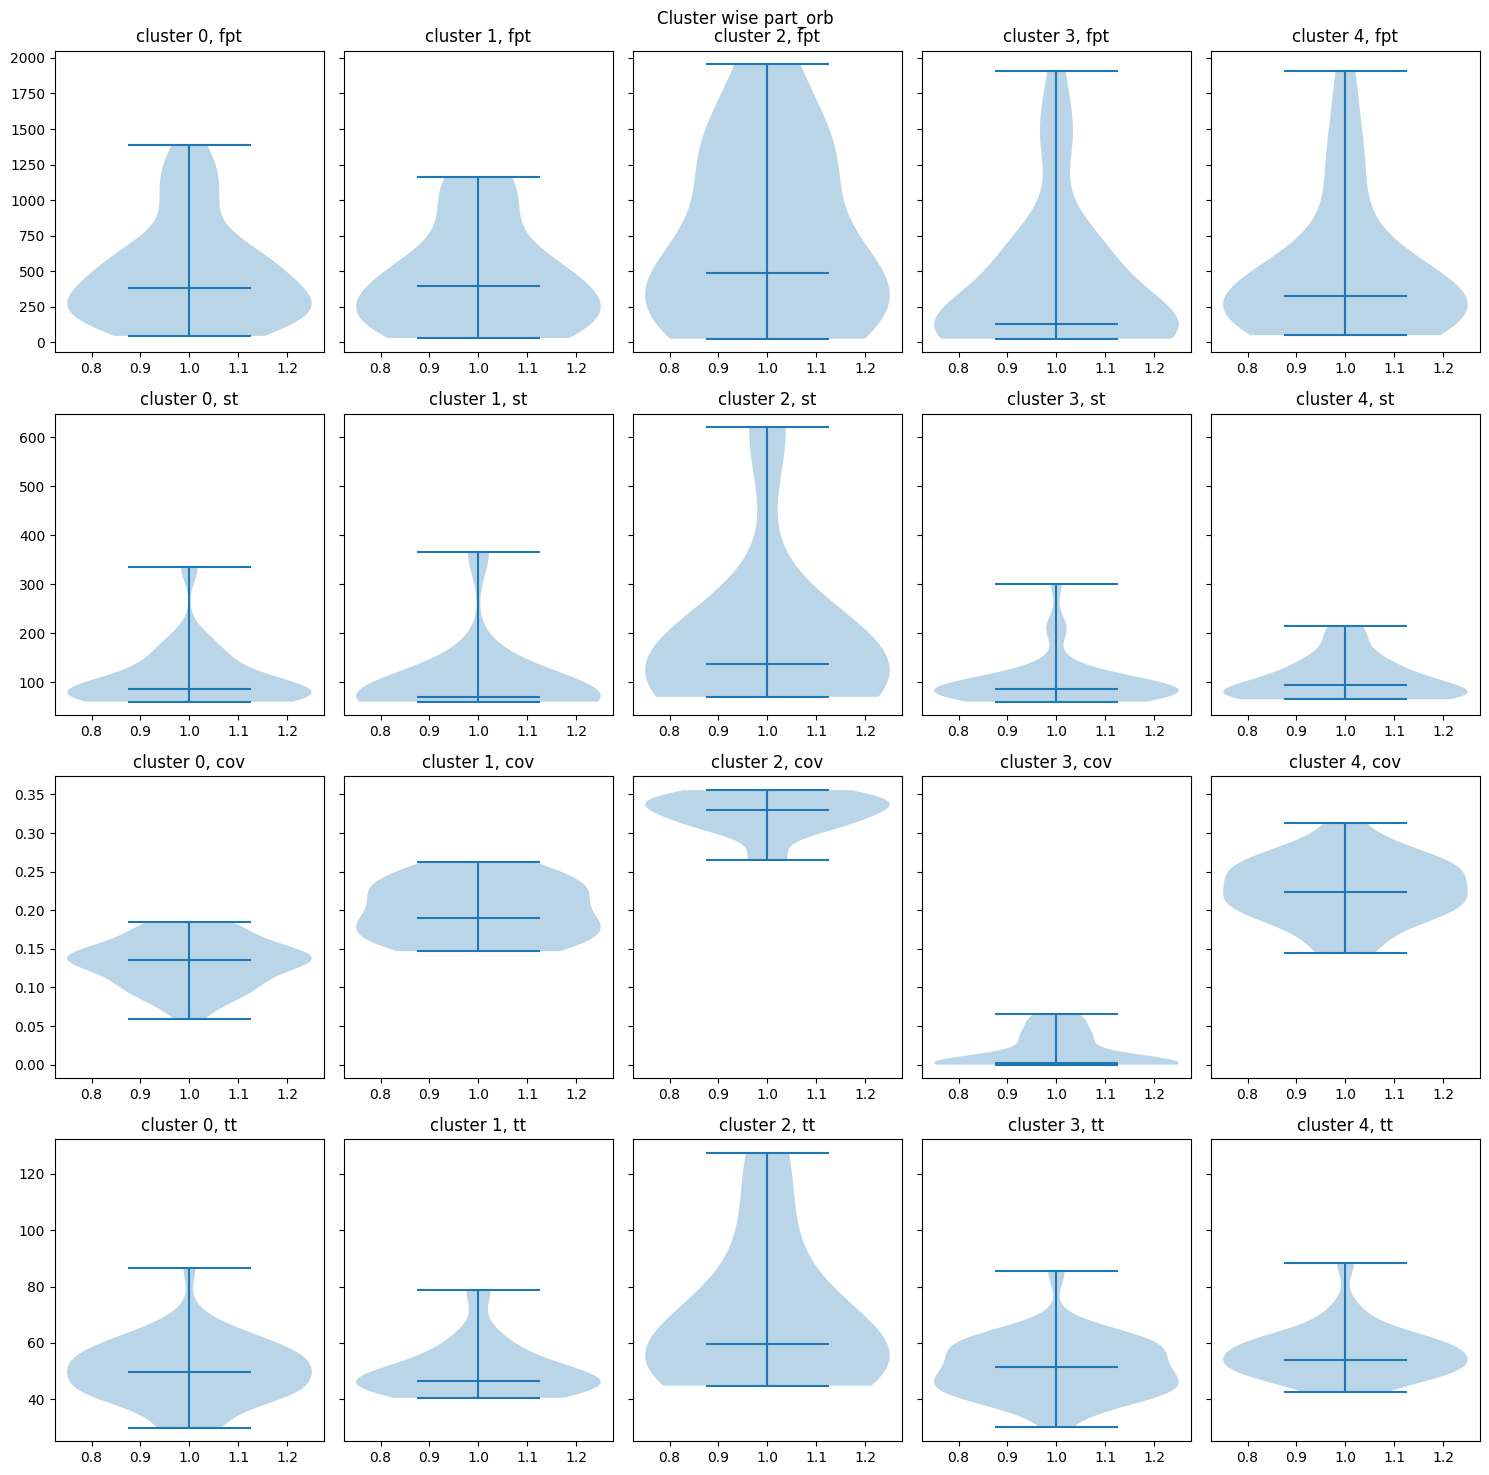

full_orb
full_peri


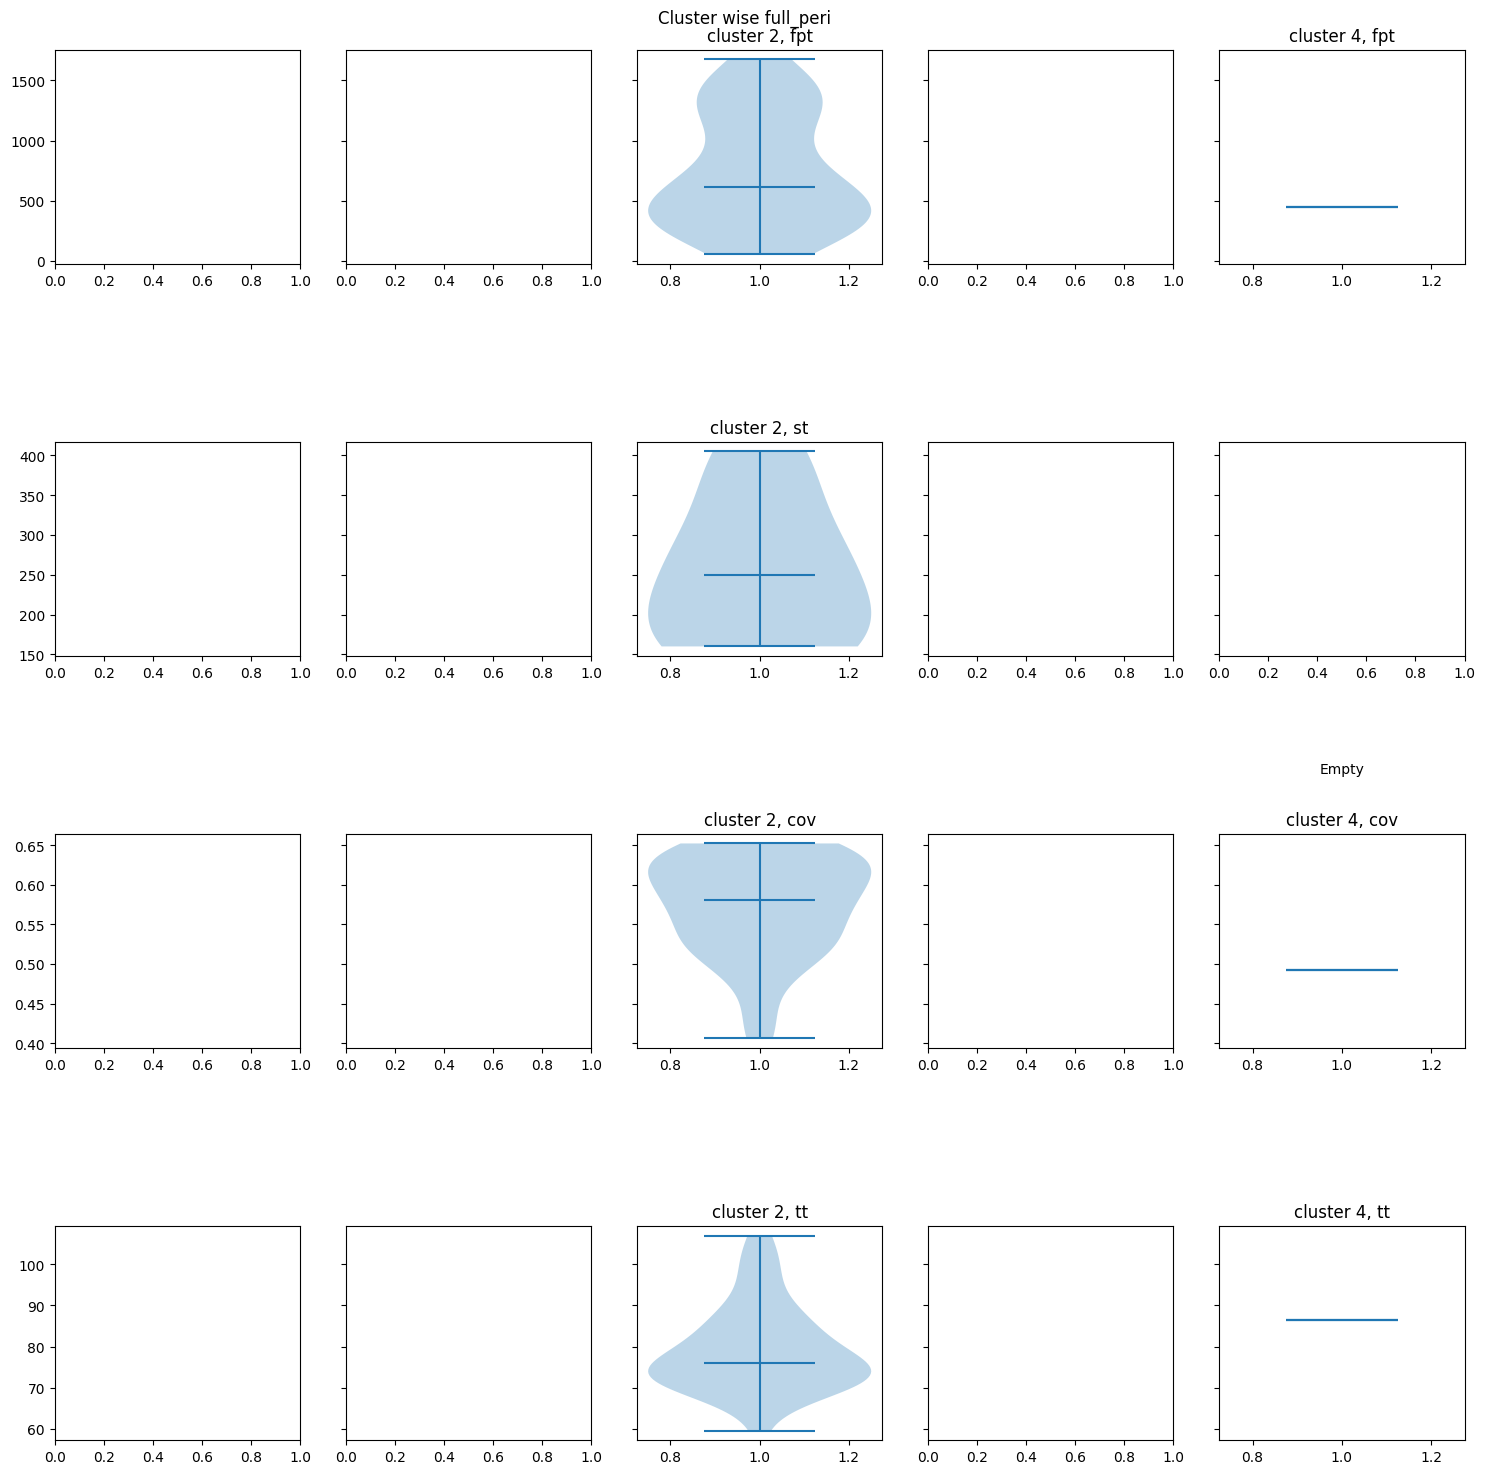

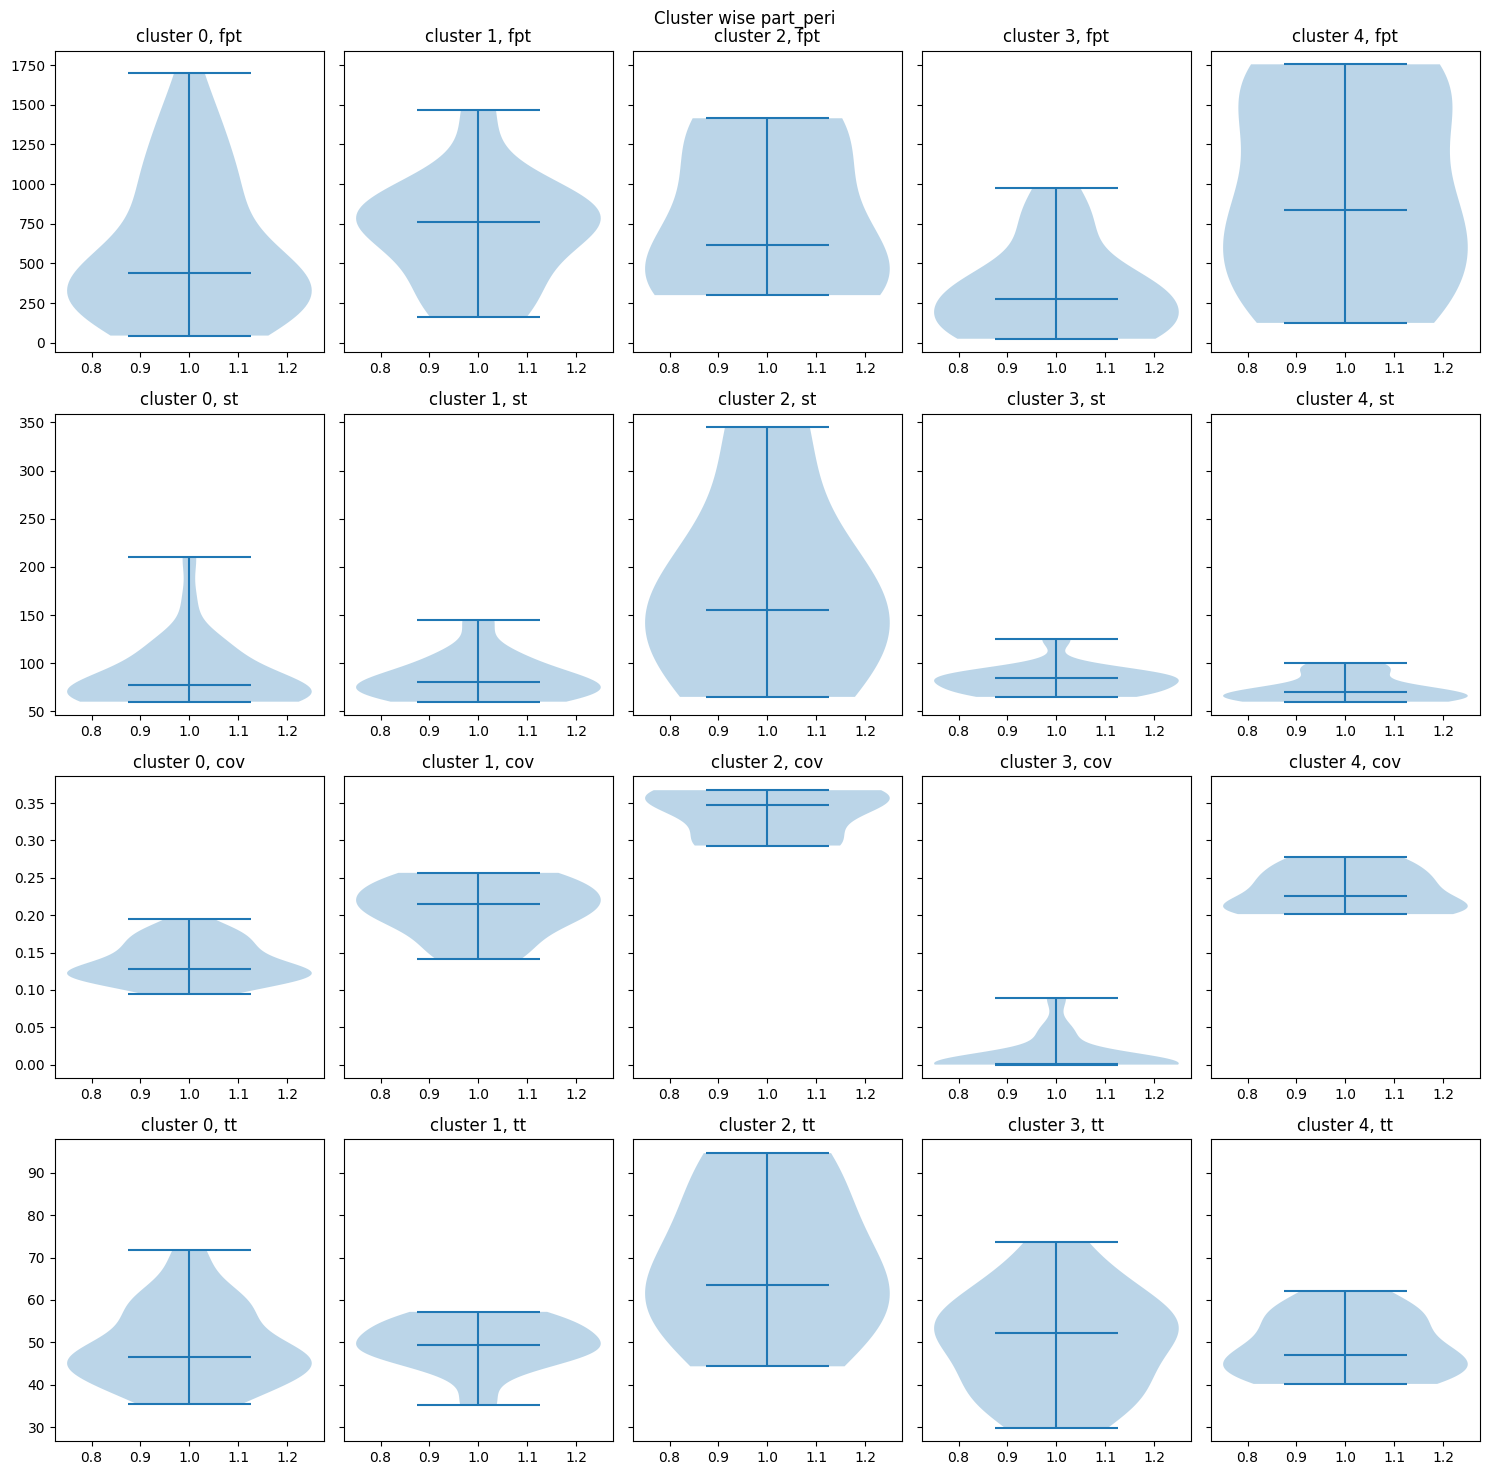

full_peri
full_pir


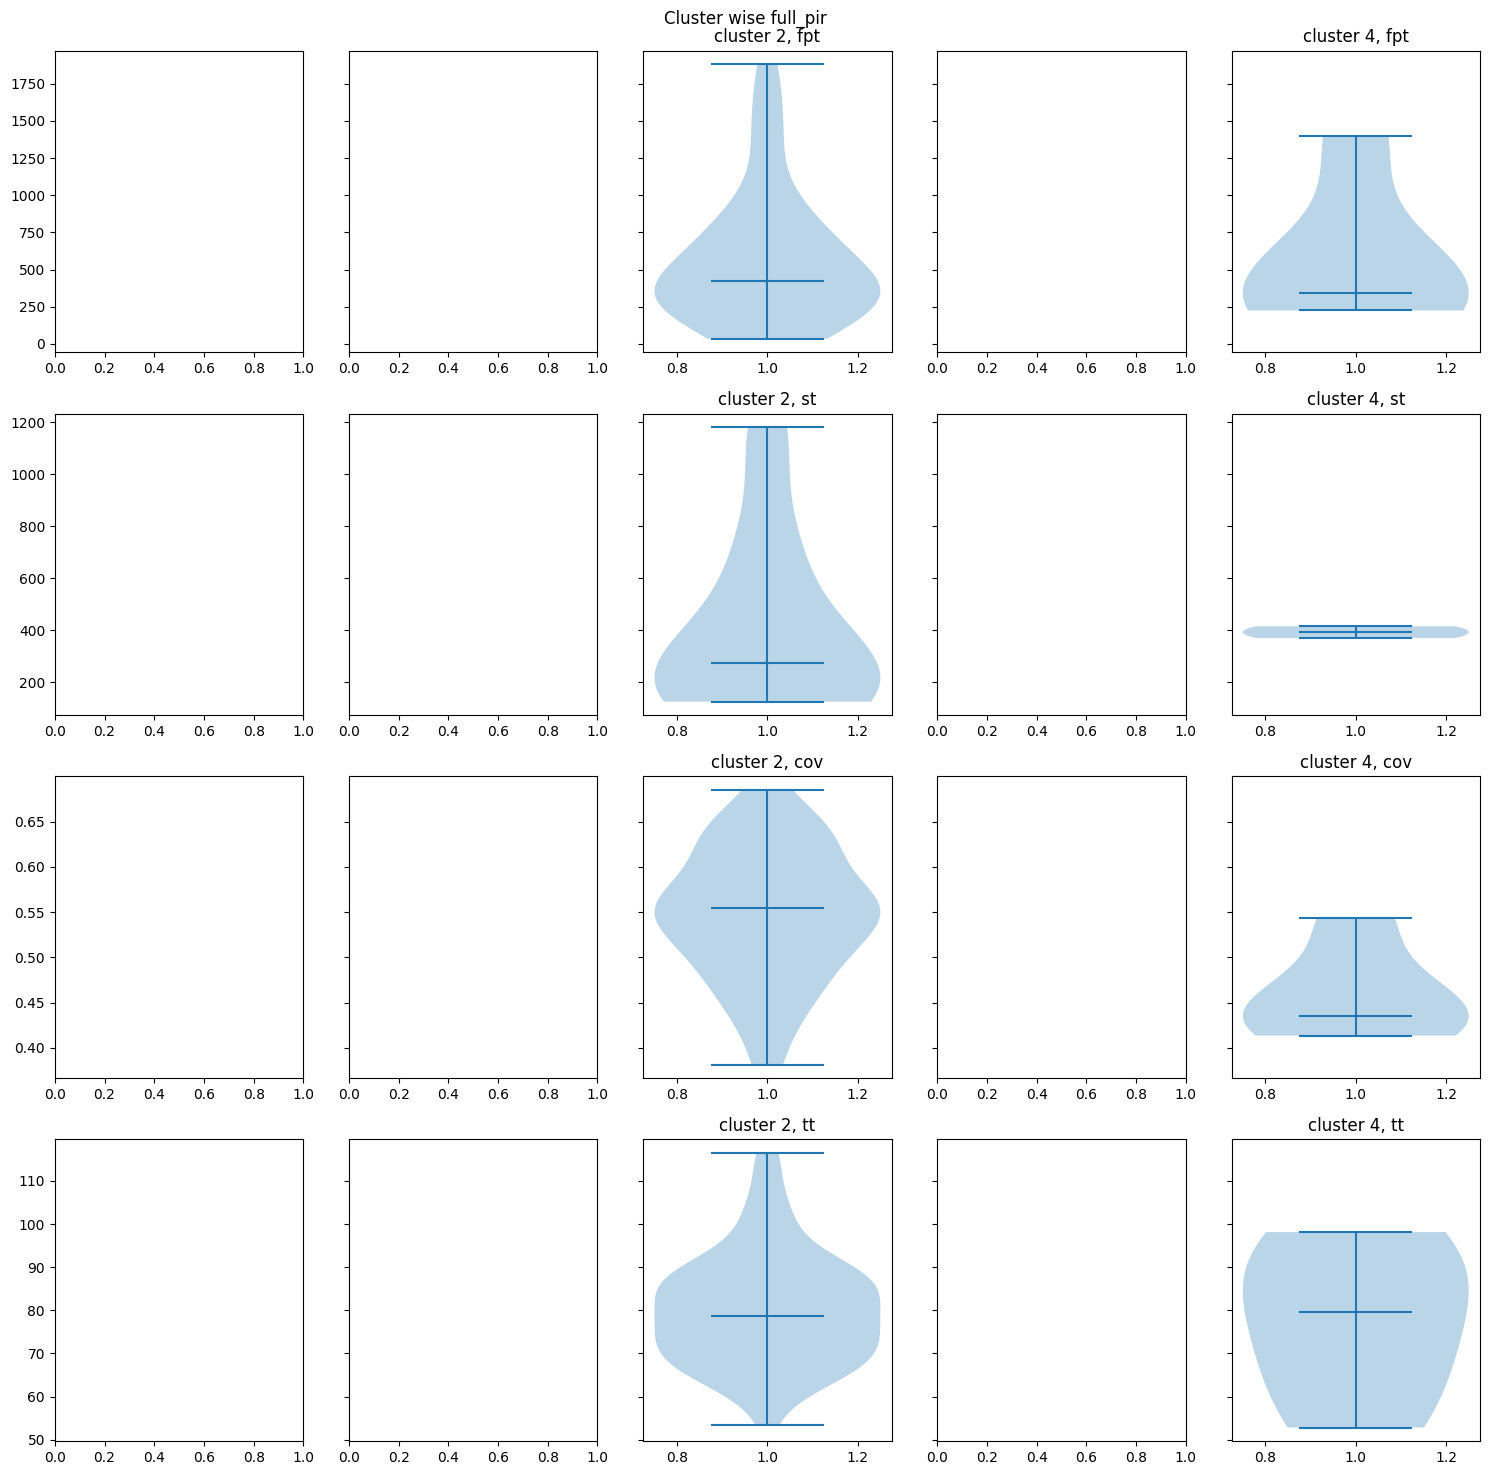

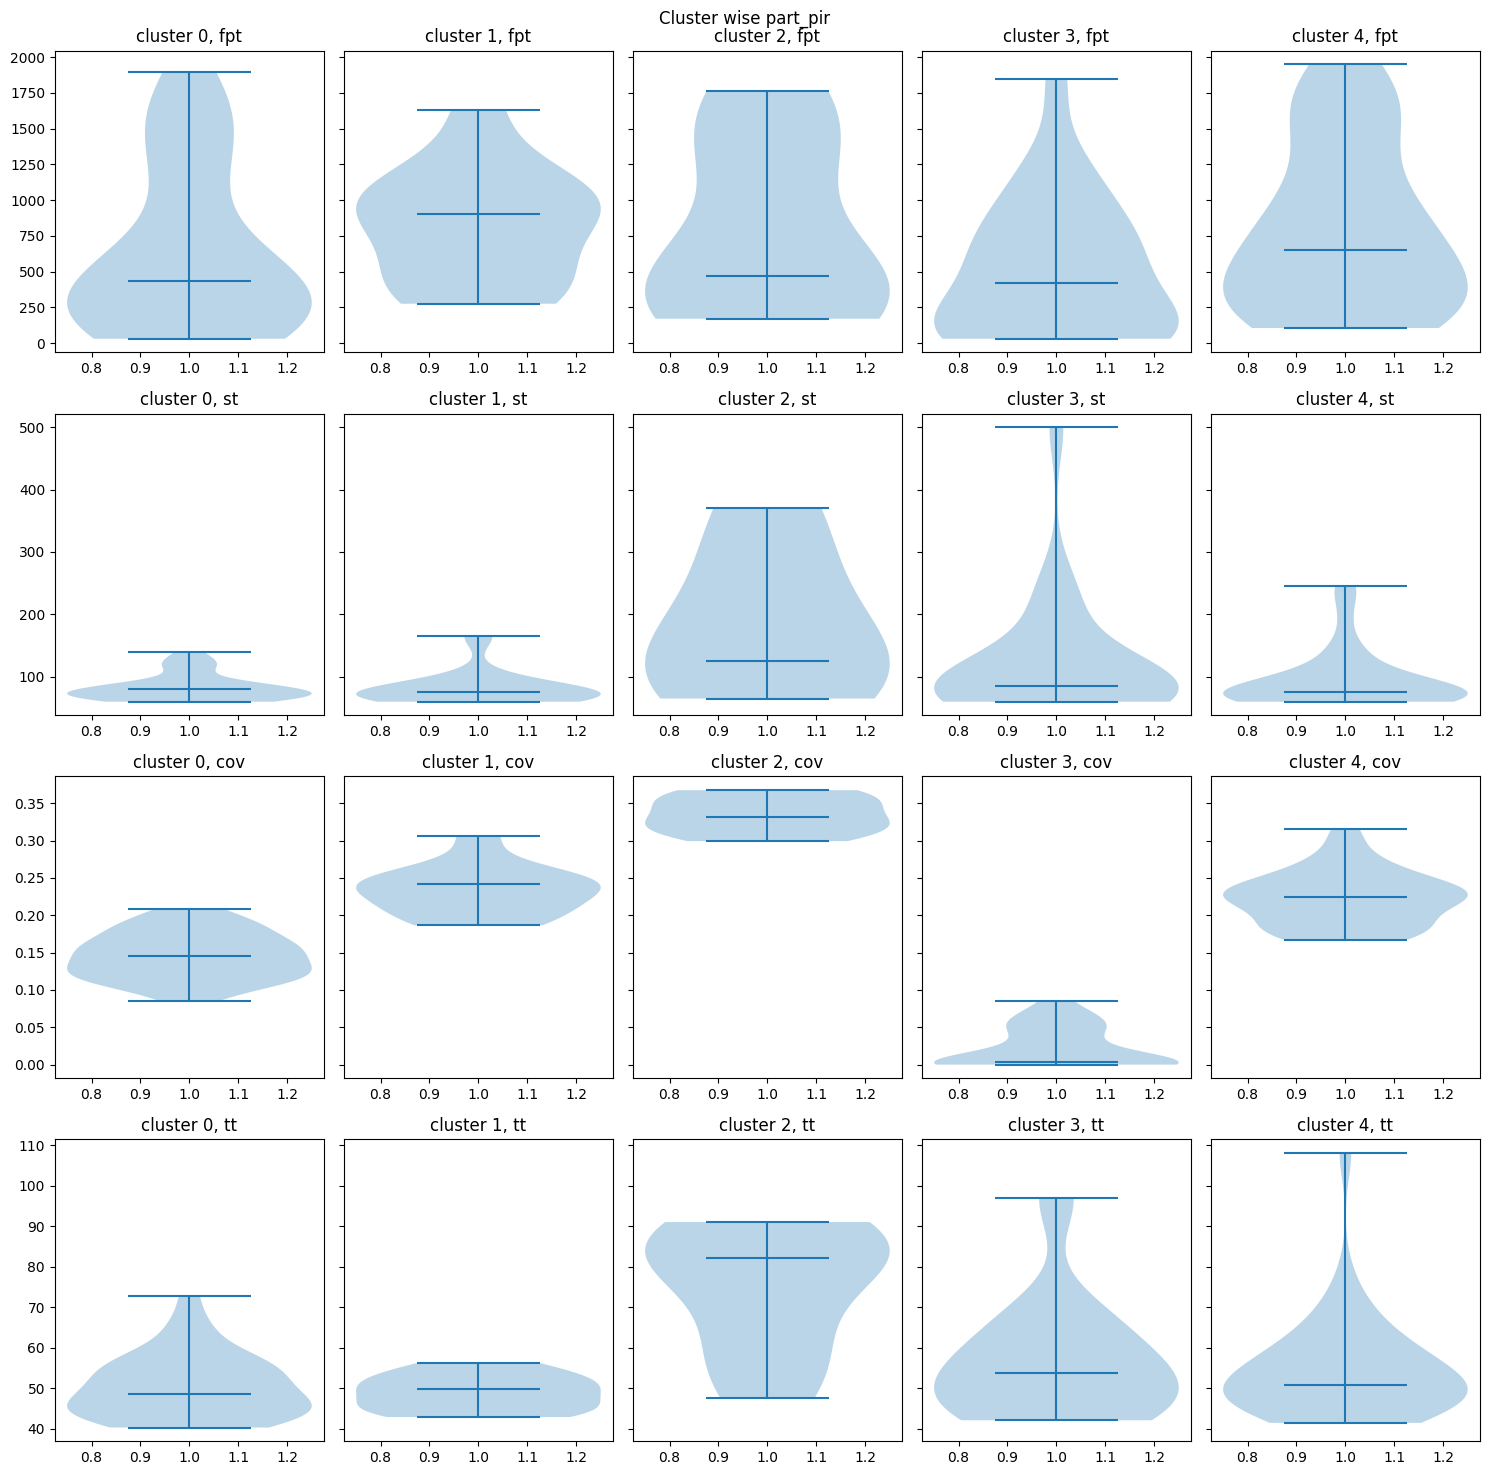

full_pir
full_re


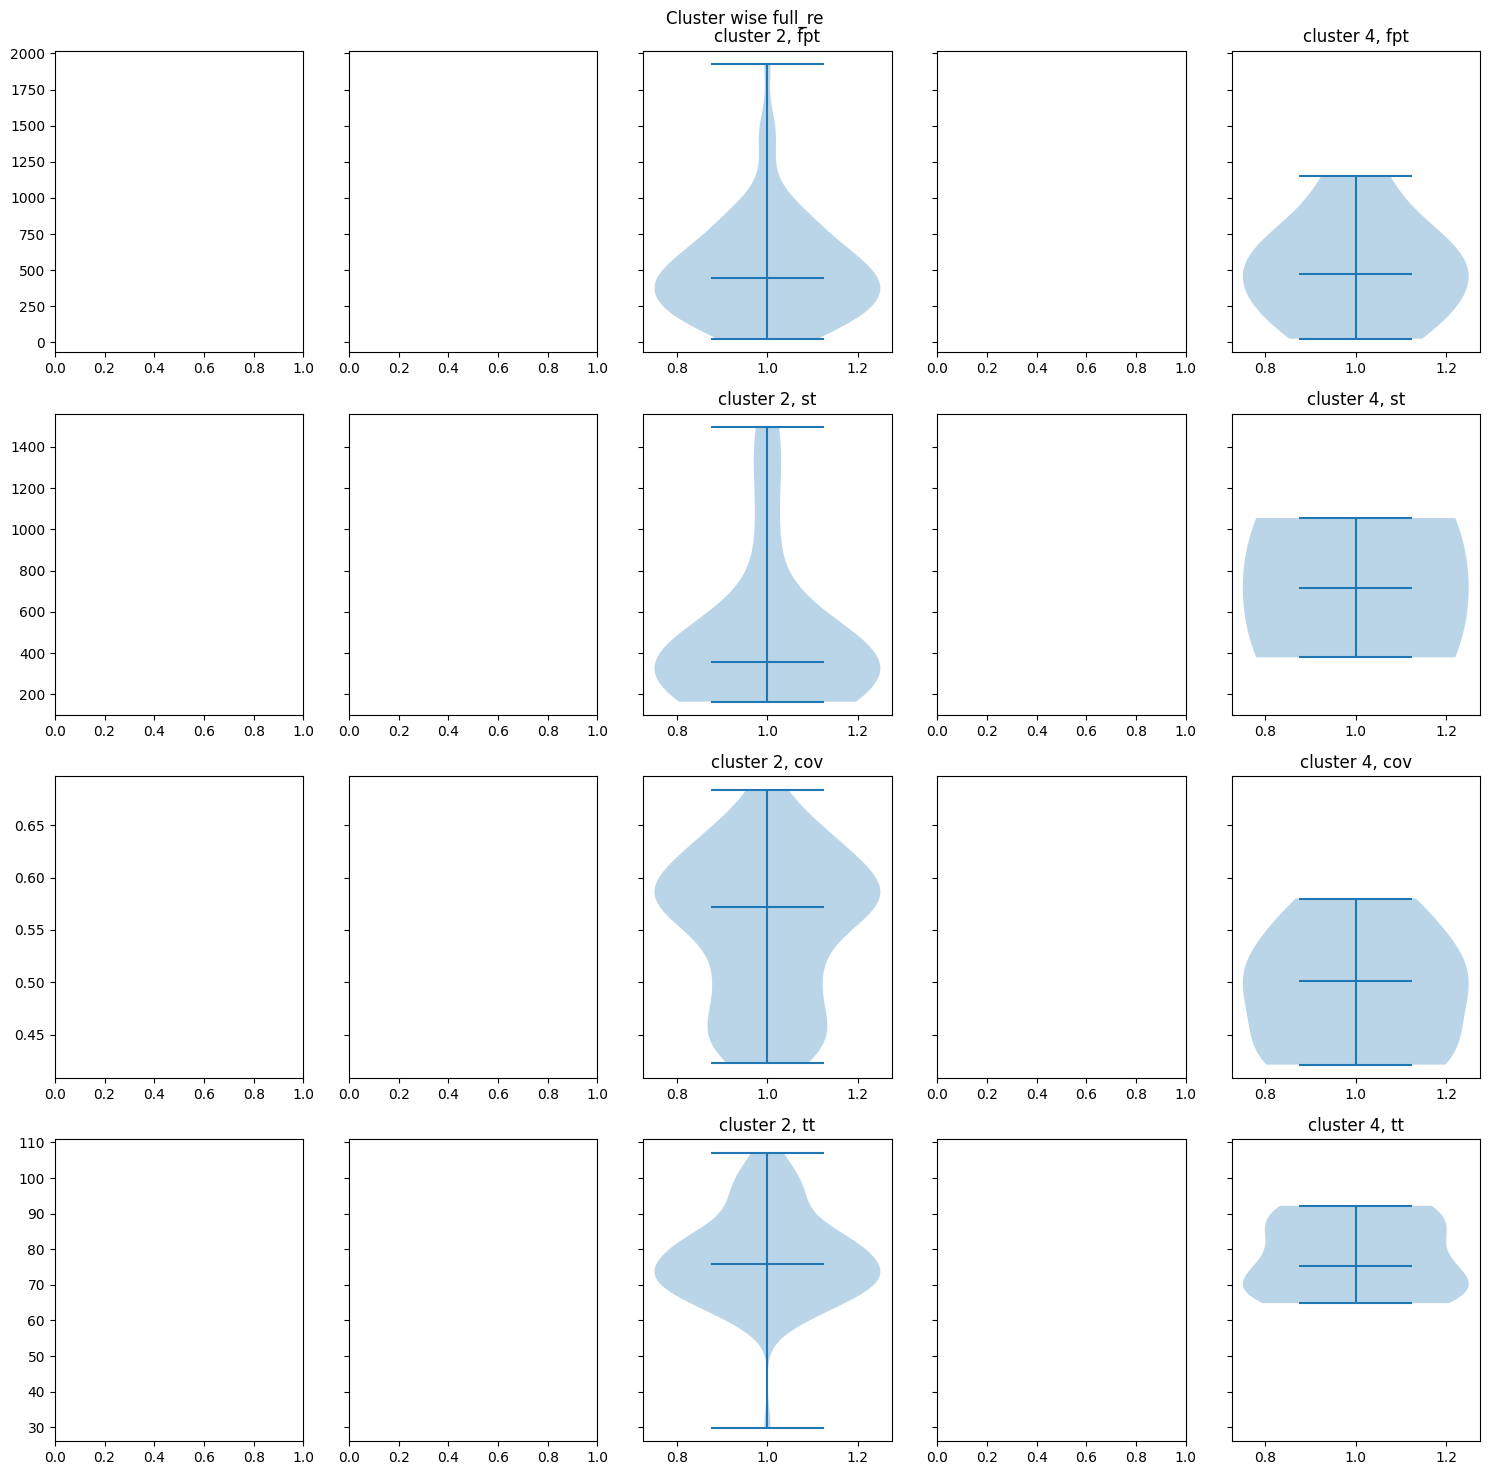

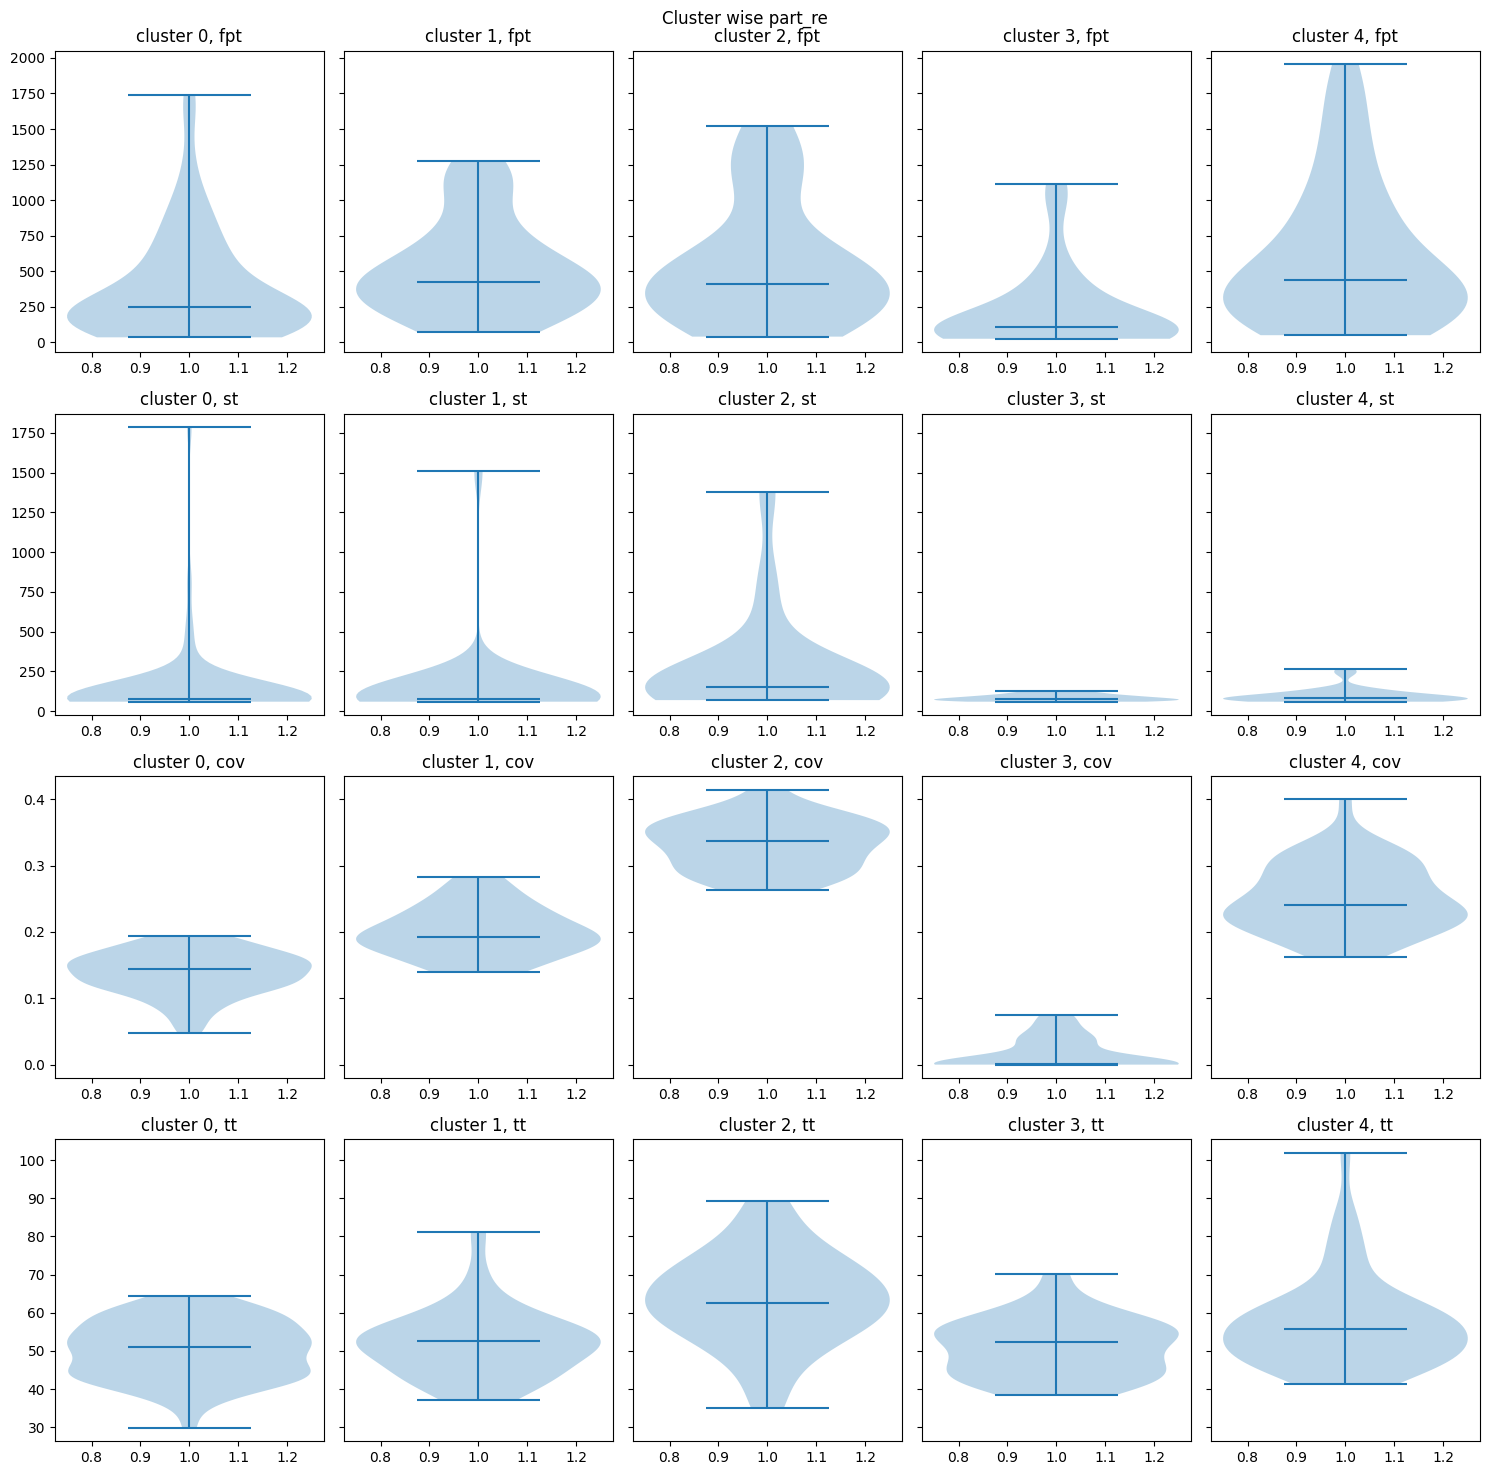

full_re


In [ ]:
for f_full, f_part in zip(file_full,file_part):
    print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    plot_params(pkl_full,f"full_{f_full.split('_')[-1]}")

    with open(f_part, "rb") as f:
        pkl_part = pickle.load(f)

    plot_params(pkl_part,f"part_{f_part.split('_')[-1]}")

    print(f"full_{f_full.split('_')[-1]}")

#### Fit st and fpt clusterwise

In [4]:
def fit_piecewiseLinear(data):
    intervals=data.copy()
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)
    # Fit piecewise linear with 3 segments
    x=intervals
    y=log_ccdf
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    # Predict
    y_hat = my_pwlf.predict(x)
    # comment out slopes and add to list if u need them
    slopes=my_pwlf.slopes

    return [x,y,y_hat,round(breaks[1]),slopes]

    
    # ax.scatter(x, y)
    # ax.plot(x, y_hat, 'r')
    # ax.set_ylabel("log P(T > t)")
    # ax.set_title(f"Log-CCDF {label} {round(breaks[1])} (2 fits)")
    # ax.legend()
    

Store data for fig5f

In [5]:
#for full transition
cl_t={}
c2=[]
c4=[]
for f_full, f_part in zip(file_full,file_part):
    print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)
    # compute t inertia i.e fit breakpoints
    # iterating over clusters
    for k in pkl_full.keys():
        data = pkl_full[k]['fpt']
        # limit between 0 to 600
        data=[x for x in data if 0<x<600]
        # check if it is empty
        if data is None or len(data)==0:
            print('empty')
            continue
        try:
            fit_params = fit_piecewiseLinear(data)[-1]
            cl_t[k]=fit_params
            if k==2:
                c2.append(cl_t[k])
            else:
                c4.append(cl_t[k])

        except Exception as e:
            print("can't fit")
            

full_bla
can't fit
full_enti
full_fn
full_lha


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\pwlf\pwlf.py:1248: RuntimeWarning: invalid value encountered in divide
  self.slopes = np.divide(


full_lsc
full_mob
can't fit
full_mop
full_mos
empty
full_mrn
can't fit
full_orb
full_peri
can't fit
full_pir
full_re


In [22]:
c2

[539, 362, 483, 420, 407, 390, 510, 530, 495, 415, 292, 328, 455]

In [23]:
c4

[232, 275, 375, 60, 485, 271, 279, 338]

Storing above T inertia data for cluster 2 and cluster 4 for full transitions

In [24]:
full_T_inertia ={'c2':c2,'c4':c4}

In [6]:
#for partial transition

c0=[]
c1=[]
c2=[]
c3=[]
c4=[]
for f_full, f_part in zip(file_full,file_part):
    print(f"part_{f_part.split('_')[-1]}")
    
    with open(f_part, "rb") as f:
        pkl_part = pickle.load(f)
    # compute t inertia i.e fit breakpoints
    # iterating over clusters
    for k in pkl_part.keys():
        data = pkl_part[k]['fpt']
        data=[x for x in data if 0<x<600]
        # check if it is empty
        if data is None or len(data)==0:
            print('empty')
            continue
        try:
            fit_params = fit_piecewiseLinear(data)[-1]
            if k==0:
                c0.append(fit_params)
            elif k==1:
                c1.append(fit_params)
            elif k==2:
                c2.append(fit_params)
            elif k==3:
                c3.append(fit_params)
            else:
                c4.append(fit_params)

        except Exception as e:
            print("can't fit")
            

part_bla
part_enti
part_fn
part_lha
part_lsc
part_mob
part_mop
part_mos
part_mrn
part_orb
part_peri
part_pir
part_re


In [26]:
part_T_inertia={'c0':c0,'c1':c1,'c2':c2,'c3':c3,'c4':c4}

Storing fig 5f data

In [28]:
reader.data_dump_pkl('results/figures/fig5f_data.pkl',{'part_fpt_tin':part_T_inertia,'full_fpt_tin':full_T_inertia})

Make data for fig 5i (early and late slopes clusterwise for partial only)

In [9]:
c0_s1=[]
c1_s1=[]
c2_s1=[]
c3_s1=[]
c4_s1=[]

c0_s2=[]
c1_s2=[]
c2_s2=[]
c3_s2=[]
c4_s2=[]

for f_full, f_part in zip(file_full,file_part):
    print(f"part_{f_part.split('_')[-1]}")
    
    with open(f_part, "rb") as f:
        pkl_part = pickle.load(f)
    # compute t inertia i.e fit breakpoints
    # iterating over clusters
    for k in pkl_part.keys():
        data = pkl_part[k]['st']
        data=[x for x in data if 0<x<250]
        # check if it is empty
        if data is None or len(data)==0:
            print('empty')
            continue
        try:
            fit_params = fit_piecewiseLinear(data)[-1]
            if k==0:
                c0_s1.append(fit_params[0])
                c0_s2.append(fit_params[1])
            elif k==1:
                c1_s1.append(fit_params[0])
                c1_s2.append(fit_params[1])
            elif k==2:
                c2_s1.append(fit_params[0])
                c2_s2.append(fit_params[1])
            elif k==3:
                c3_s1.append(fit_params[0])
                c3_s2.append(fit_params[1])
            else:
                c4_s1.append(fit_params[0])
                c4_s2.append(fit_params[1])

        except Exception as e:
            print("can't fit")
            

part_bla
part_enti
part_fn
part_lha
part_lsc
part_mob
part_mop
part_mos
part_mrn
part_orb
part_peri
part_pir
part_re


In [17]:
c1_s2

[-0.03326058892152976,
 -0.13861090764055686,
 -0.14103499776028278,
 -0.06925834392746033,
 -0.012368066495772139,
 -0.04619113272576459,
 -0.013294702505885343,
 -0.03375612661330469,
 -0.019429512169553,
 0.24259218362618262,
 -0.13602460235976077,
 0.005498625262371836,
 -0.02407048178766758]

Store above for fig 5i

In [18]:
reader.data_dump_pkl('results/figures/fig5i_data.pkl',{'early':[c0_s1,c1_s1,c2_s1,c3_s1,c4_s1],'late':[c0_s2,c1_s2,c2_s2,c3_s2,c4_s2]})


In [7]:

def is_empty(arr):
    if arr is None:
        return True
    if isinstance(arr, (list, tuple)):
        return len(arr) == 0
    if isinstance(arr, np.ndarray):
        return arr.size == 0
    if isinstance(arr, (pd.Series, pd.DataFrame)):
        return arr.empty
    return False


In [8]:
def plot_fit(data, label):
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    key_list = ['fpt', 'st', 'cov', 'tt']
    # colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}
    colors={0:'green',1:'red',2:'C0',3:'orange',4:'purple'}
    for j in range(2):  # two subplots
        for i in data.keys():  # loop over your 5 dictionaries
            plt_data = data[i][key_list[j]]
            # limit fpt from 20 to 600 i.e j = 0
            if j==0:
                plt_data=[x for x in plt_data if 0<x<600]
            else:
                # limit ST from 0 to 250 for partial data
                # plt_data=[x for x in plt_data if 0<x<250]
                # comment out for full
                plt_data=[x for x in plt_data if 0<x<600]
                
            
            # check emptiness
            if plt_data is None or len(plt_data) == 0:
                ax = axes[j]
                ax.text(0.5, 0.5, "Empty", ha='center')
                continue
            
            ax = axes[j]
            try:
                # attempt fit
                l = fit_piecewiseLinear(plt_data)
                x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
                
                # pick color based on i
                color = colors.get(i, "black")
                
                # scatter and line with chosen color
                ax.scatter(x, y, color=color, alpha=0.5, label=f"clust {i}")
                ax.plot(x, y_hat, color=color, alpha=0.5)
                
                ax.set_ylabel("log P(T > t)")
                ax.set_title(f"Log-CCDF {label} {key_list[j]}")
                ax.legend()
            
            except Exception as e:
                # if fit fails, skip gracefully
                ax.text(0.5, 0.5, f"Fit failed: cluster {i}", ha='center', fontsize=8)
    
    plt.tight_layout()
    return breaks
    

                
    # plt.savefig(f'../../data/results/comm_umap_results/comm_wise_params/cw_{key_list[j]}{label}.pdf', format='pdf')

  


Processed: full_bla
Processed: full_enti
Processed: full_fn
Processed: full_lha
Processed: full_lsc
Processed: full_mob
Processed: full_mop
Processed: full_mos
Processed: full_mrn
Processed: full_orb
Processed: full_peri
Processed: full_pir
Processed: full_re


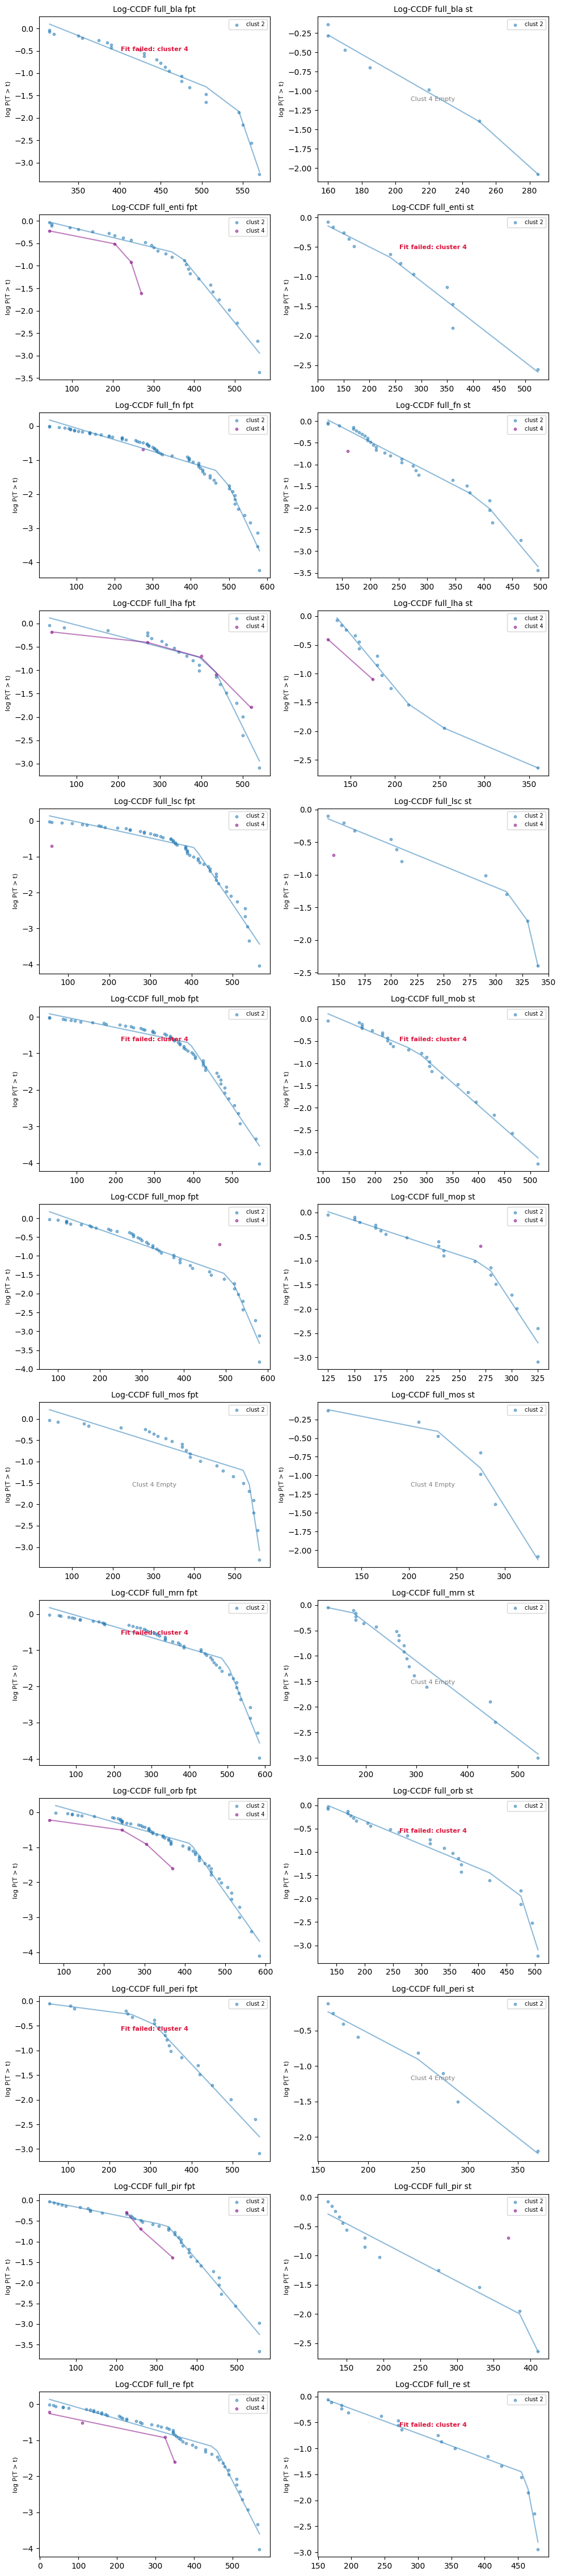

In [10]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

def plot_fit_on_axes(data, label, axes_row):
    """
    Plots the data onto a specific pre-allocated row of axes.
    axes_row: an array of 2 Axes objects [ax_fpt, ax_st]
    """
    key_list = ['fpt', 'st', 'cov', 'tt']
    colors = {0: 'green', 1: 'red', 2: 'C0', 3: 'orange', 4: 'purple'}
    
    # Track the last successfully computed break point if needed
    last_break = None 
    
    for j in range(2):  # Two subplots per network row: 0=fpt, 1=st
        ax = axes_row[j]
        ax.set_title(f"Log-CCDF {label} {key_list[j]}", fontsize=10)
        ax.set_ylabel("log P(T > t)", fontsize=8)
        
        # Loop over cluster dictionaries
        for i in data.keys():  
            plt_data = data[i][key_list[j]]
            
            # Apply thresholds
            if j == 0:
                plt_data = [x for x in plt_data if 0 < x < 600]
            else:
                plt_data = [x for x in plt_data if 0 < x < 600]
                
            # Check for emptiness
            if plt_data is None or len(plt_data) == 0:
                # Add text without clearing the plot so other clusters can still render
                ax.text(0.5, 0.5, f"Clust {i} Empty", ha='center', va='center', 
                        transform=ax.transAxes, color='gray', fontsize=8)
                continue
                
            try:
                # Attempt fit
                l = fit_piecewiseLinear(plt_data)
                x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
                last_break = breaks
                
                # Pick color and plot
                color = colors.get(i, "black")
                ax.scatter(x, y, color=color, alpha=0.5, s=10, label=f"clust {i}")
                ax.plot(x, y_hat, color=color, alpha=0.5)
                ax.legend(fontsize=7, loc='upper right')
                
            except Exception as e:
                # If fit fails for a cluster, write it clearly inside this specific subplot space
                ax.text(0.5, 0.2 + (i*0.15), f"Fit failed: cluster {i}", 
                        ha='center', va='center', transform=ax.transAxes, 
                        color='crimson', fontsize=8, weight='semibold')
                
    return last_break


# --- Main Execution Section ---

n_networks = len(file_full)  # Dynamically count how many files/rows we need

# Initialize ONE massive figure canvas 
# Each file gets a dedicated row (Height: 3.5 inches per row, Width: 10 inches total)
fig, all_axes = plt.subplots(n_networks, 2, figsize=(10, 3.5 * n_networks), squeeze=False)

for idx, f_full in enumerate(file_full):
    # Network name extractor
    network_label = f"full_{f_full.split('_')[-1]}"
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    # Pass the current row's axis pairs: all_axes[idx] -> [ax_fpt, ax_st]
    plot_fit_on_axes(pkl_full, network_label, all_axes[idx])
    
    print(f"Processed: {network_label}")

# Apply global formatting and layout constraints across the unified plot
plt.tight_layout()
plt.show()

# If you want to save the entire grid to one high-res document:
# fig.savefig('../../data/results/comm_umap_results/all_networks_fits.pdf', format='pdf', bbox_inches='tight')

Supplementary - Clusterwise only ST fit

Processed ST Fit for: bla
Processed ST Fit for: enti
Processed ST Fit for: fn
Processed ST Fit for: lha
Processed ST Fit for: lsc
Processed ST Fit for: mob
Processed ST Fit for: mop
Processed ST Fit for: mos
Processed ST Fit for: mrn
Processed ST Fit for: orb
Processed ST Fit for: peri
Processed ST Fit for: pir
Processed ST Fit for: re


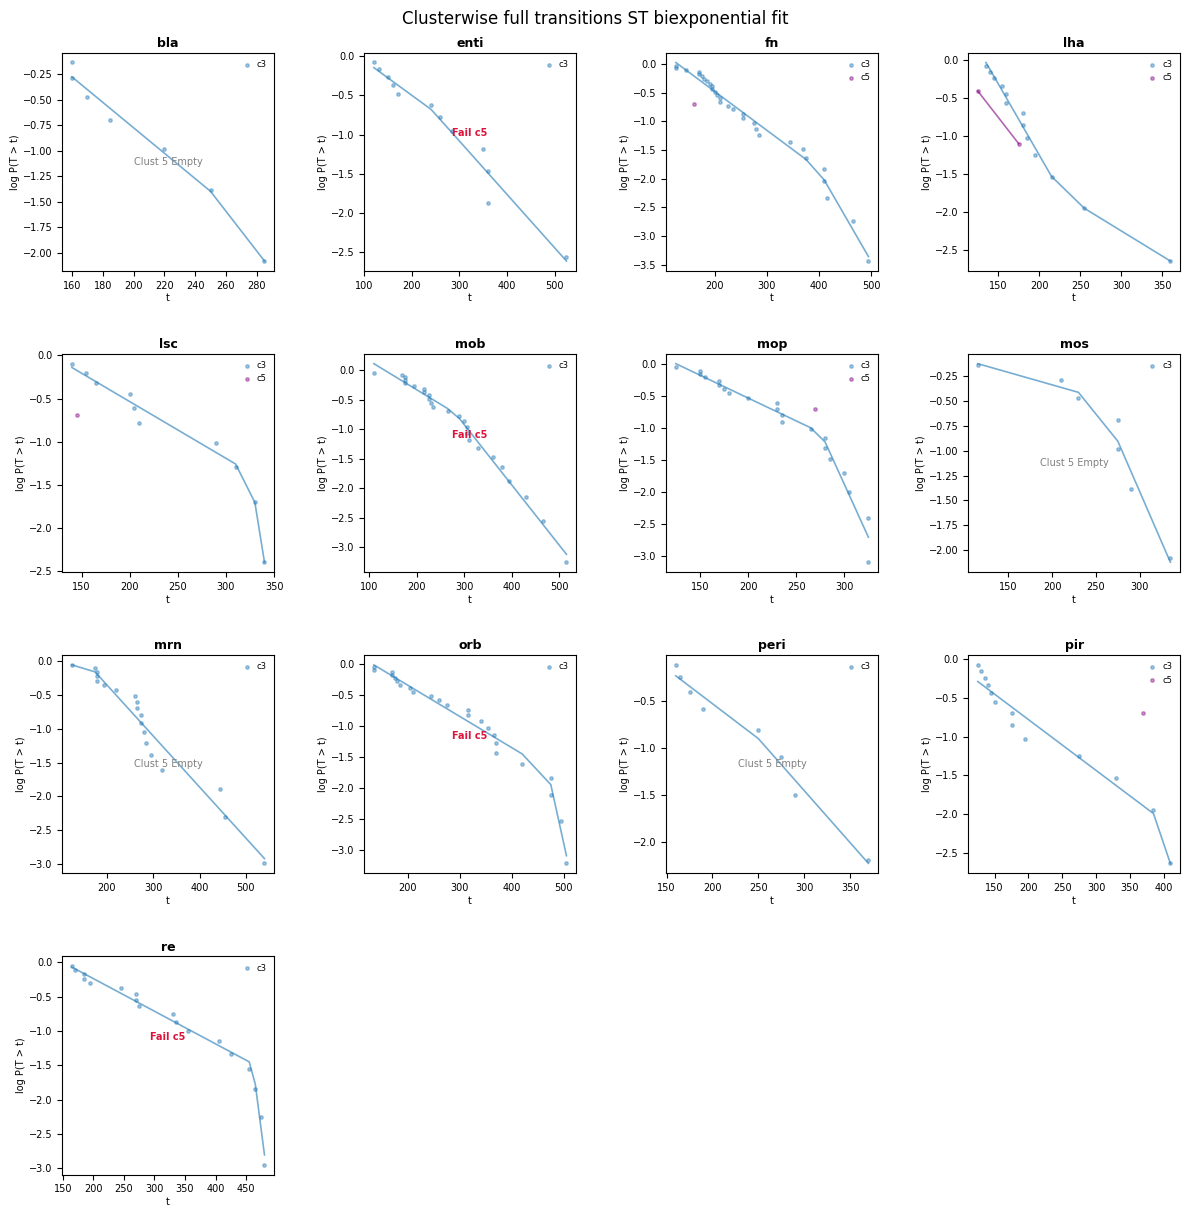

In [16]:
def plot_st_fit_on_axis(data, label, ax):
    """
    Plots ONLY the 'st' key data onto a single pre-allocated axis object.
    Clusters are remapped from 0-4 to 1-5 for labels and colors.
    """
    target_key = 'st'
    # Colors updated to map to keys 1 through 5
    colors = {1: 'green', 2: 'red', 3: 'C0', 4: 'orange', 5: 'purple'}
    last_break = None 
    
    # Clean, compact title for a 4x4 grid space
    ax.set_title(f"{label}", fontsize=9, fontweight='bold', pad=4)
    ax.set_ylabel("log P(T > t)", fontsize=7, labelpad=2)
    ax.set_xlabel("t", fontsize=7, labelpad=2)
    ax.tick_params(axis='both', labelsize=7)
    
    # Loop over your cluster dictionaries (0, 1, 2, 3, 4)
    for i in data.keys():  
        plt_data = data[i][target_key]
        
        # Remap the cluster ID from 0-4 to 1-5 for color matching and labeling
        display_id = i + 1
        
        # Limit ST from 0 to 600 for full data
        plt_data = [x for x in plt_data if 0 < x < 600]
            
        # Check for emptiness
        if plt_data is None or len(plt_data) == 0:
            ax.text(0.5, 0.5, f"Clust {display_id} Empty", ha='center', va='center', 
                    transform=ax.transAxes, color='gray', fontsize=7)
            continue
            
        try:
            # Attempt fit
            l = fit_piecewiseLinear(plt_data)
            x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
            last_break = breaks
            
            # Pick color based on the remapped display_id (1-5)
            color = colors.get(display_id, "black")
            ax.scatter(x, y, color=color, alpha=0.4, s=6, label=f"c{display_id}")
            ax.plot(x, y_hat, color=color, alpha=0.6, linewidth=1.2)
            
            # Use a very small, unobtrusive legend for the tight layout
            ax.legend(fontsize=6, loc='upper right', frameon=False, handletextpad=0.2)
            
        except Exception as e:
            # Stack error strings using the 1-5 cluster mapping
            ax.text(0.5, 0.15 + (i * 0.12), f"Fail c{display_id}", 
                    ha='center', va='center', transform=ax.transAxes, 
                    color='crimson', fontsize=7, weight='semibold')
                
    return last_break


# --- Main Execution Section ---

n_rows = 4
n_cols = 4

# Initialize a standard 4x4 figure matrix
fig, all_axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
axes_flat = all_axes.flatten()

# Keep track of how many subplots we actually fill
idx = 0
for idx, f_full in enumerate(file_full):
    # If there are more than 16 files, break to prevent an IndexError
    if idx >= len(axes_flat):
        break
        
    network_label = f_full.split('_')[-1] 
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    # Pass the individual flattened axis index directly
    plot_st_fit_on_axis(pkl_full, network_label, axes_flat[idx])
    
    print(f"Processed ST Fit for: {network_label}")

# Hide any remaining unused panels if you have less than 16 networks
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# Uniform, spacious padding so axes labels and titles don't collide
plt.tight_layout(h_pad=2.5, w_pad=2.5)
plt.suptitle('Clusterwise full transitions ST biexponential fit', y=1.01)
plt.show()

Supplementary for full fpt fit

Processed FPT Fit for: bla
Processed FPT Fit for: enti
Processed FPT Fit for: fn
Processed FPT Fit for: lha
Processed FPT Fit for: lsc
Processed FPT Fit for: mob
Processed FPT Fit for: mop
Processed FPT Fit for: mos
Processed FPT Fit for: mrn
Processed FPT Fit for: orb
Processed FPT Fit for: peri
Processed FPT Fit for: pir
Processed FPT Fit for: re


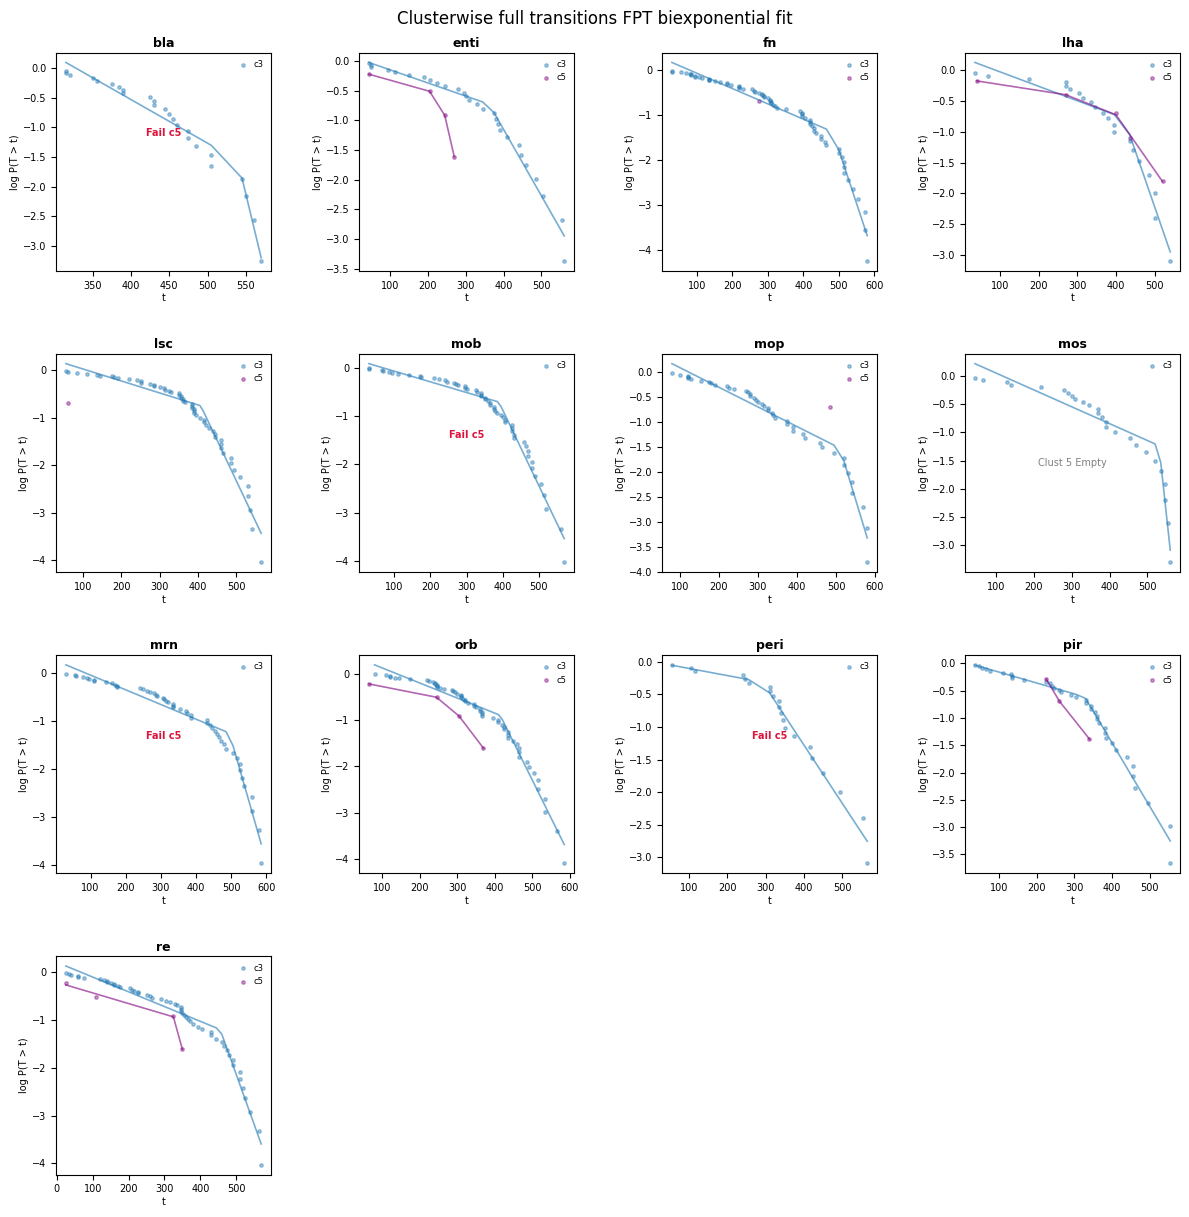

In [20]:

def plot_fpt_fit_on_axis(data, label, ax):
    """
    Plots ONLY the 'fpt' key data onto a single pre-allocated axis object.
    Clusters are remapped from 0-4 to 1-5 for labels and colors.
    """
    # TARGET KEY CHANGED TO FPT
    target_key = 'fpt' 
    colors = {1: 'green', 2: 'red', 3: 'C0', 4: 'orange', 5: 'purple'}
    last_break = None 
    
    # Clean, compact title for a 4x4 grid space
    ax.set_title(f"{label}", fontsize=9, fontweight='bold', pad=4)
    ax.set_ylabel("log P(T > t)", fontsize=7, labelpad=2)
    ax.set_xlabel("t", fontsize=7, labelpad=2)
    ax.tick_params(axis='both', labelsize=7)
    
    # Loop over your cluster dictionaries (0, 1, 2, 3, 4)
    for i in data.keys():  
        plt_data = data[i][target_key]
        
        # Remap the cluster ID from 0-4 to 1-5 for color matching and labeling
        display_id = i + 1
        
        # Limit FPT values (Adjust limits here if needed based on your FPT distribution)
        plt_data = [x for x in plt_data if 0 < x < 600]
            
        # Check for emptiness
        if plt_data is None or len(plt_data) == 0:
            ax.text(0.5, 0.5, f"Clust {display_id} Empty", ha='center', va='center', 
                    transform=ax.transAxes, color='gray', fontsize=7)
            continue
            
        try:
            # Attempt fit
            l = fit_piecewiseLinear(plt_data)
            x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
            last_break = breaks
            
            # Pick color based on the remapped display_id (1-5)
            color = colors.get(display_id, "black")
            ax.scatter(x, y, color=color, alpha=0.4, s=6, label=f"c{display_id}")
            ax.plot(x, y_hat, color=color, alpha=0.6, linewidth=1.2)
            
            # Use a very small, unobtrusive legend for the tight layout
            ax.legend(fontsize=6, loc='upper right', frameon=False, handletextpad=0.2)
            
        except Exception as e:
            # Stack error strings using the 1-5 cluster mapping
            ax.text(0.5, 0.15 + (i * 0.12), f"Fail c{display_id}", 
                    ha='center', va='center', transform=ax.transAxes, 
                    color='crimson', fontsize=7, weight='semibold')
                
    return last_break


# --- Main Execution Section ---

n_rows = 4
n_cols = 4

# Initialize a standard 4x4 figure matrix
fig, all_axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
axes_flat = all_axes.flatten()

# Keep track of how many subplots we actually fill
idx = 0
for idx, f_full in enumerate(file_full):
    # If there are more than 16 files, break to prevent an IndexError
    if idx >= len(axes_flat):
        break
        
    network_label = f_full.split('_')[-1] 
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    # Pass the individual flattened axis index directly to the FPT function
    plot_fpt_fit_on_axis(pkl_full, network_label, axes_flat[idx])
    
    print(f"Processed FPT Fit for: {network_label}")

# Hide any remaining unused panels if you have less than 16 networks
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# Uniform, spacious padding so axes labels and titles don't collide
plt.tight_layout(h_pad=2.5, w_pad=2.5)
plt.suptitle('Clusterwise full transitions FPT biexponential fit', y=1.01)
plt.show()

PArt FPT clusterwise fit

Processed Partial FPT Fit for: part_bla
Processed Partial FPT Fit for: part_enti
Processed Partial FPT Fit for: part_fn
Processed Partial FPT Fit for: part_lha
Processed Partial FPT Fit for: part_lsc
Processed Partial FPT Fit for: part_mob
Processed Partial FPT Fit for: part_mop
Processed Partial FPT Fit for: part_mos
Processed Partial FPT Fit for: part_mrn
Processed Partial FPT Fit for: part_orb
Processed Partial FPT Fit for: part_peri
Processed Partial FPT Fit for: part_pir
Processed Partial FPT Fit for: part_re


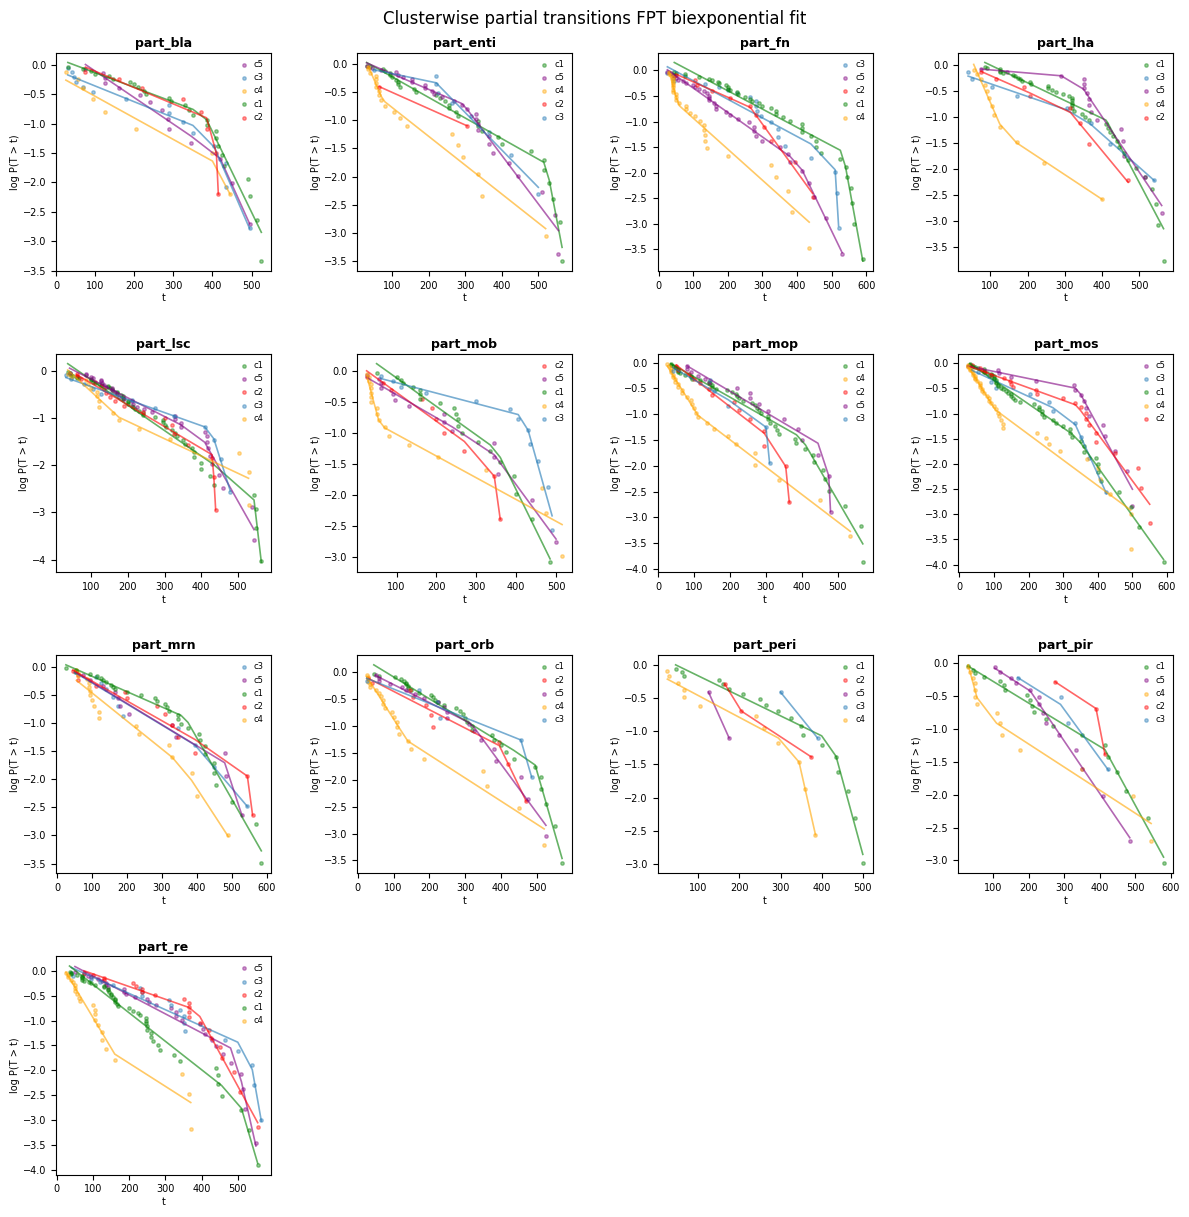

In [21]:
def plot_part_fpt_fit_on_axis(data, label, ax):
    """
    Plots ONLY the 'fpt' key data for partial files onto a single axis object.
    Clusters are remapped from 0-4 to 1-5 for labels and colors.
    """
    # Target key remains 'fpt'
    target_key = 'fpt' 
    colors = {1: 'green', 2: 'red', 3: 'C0', 4: 'orange', 5: 'purple'}
    last_break = None 
    
    # Clean, compact title configuration for 4x4 matrix
    ax.set_title(f"{label}", fontsize=9, fontweight='bold', pad=4)
    ax.set_ylabel("log P(T > t)", fontsize=7, labelpad=2)
    ax.set_xlabel("t", fontsize=7, labelpad=2)
    ax.tick_params(axis='both', labelsize=7)
    
    # Loop over cluster dictionaries (0, 1, 2, 3, 4)
    for i in data.keys():  
        plt_data = data[i][target_key]
        
        # Remap cluster IDs from 0-4 to 1-5
        display_id = i + 1
        
        # Limit FPT values for partial data (Keeping 0 < x < 600)
        plt_data = [x for x in plt_data if 0 < x < 600]
            
        # Check for emptiness
        if plt_data is None or len(plt_data) == 0:
            ax.text(0.5, 0.5, f"Clust {display_id} Empty", ha='center', va='center', 
                    transform=ax.transAxes, color='gray', fontsize=7)
            continue
            
        try:
            # Attempt piecewise linear fit
            l = fit_piecewiseLinear(plt_data)
            x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
            last_break = breaks
            
            # Scatter plot and fit line execution
            color = colors.get(display_id, "black")
            ax.scatter(x, y, color=color, alpha=0.4, s=6, label=f"c{display_id}")
            ax.plot(x, y_hat, color=color, alpha=0.6, linewidth=1.2)
            
            # Compact legend spacing
            ax.legend(fontsize=6, loc='upper right', frameon=False, handletextpad=0.2)
            
        except Exception as e:
            # Stack failures sequentially down the subplot space
            ax.text(0.5, 0.15 + (i * 0.12), f"Fail c{display_id}", 
                    ha='center', va='center', transform=ax.transAxes, 
                    color='crimson', fontsize=7, weight='semibold')
                
    return last_break


# --- Main Execution Section ---

n_rows = 4
n_cols = 4

# Initialize a standard 4x4 figure matrix (12x12 inches canvas scale)
fig, all_axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
axes_flat = all_axes.flatten()

# Keep track of how many subplots we actually fill
idx = 0
for idx, f_part in enumerate(file_part):
    # Prevent index crashes if file count goes beyond 16 available frames
    if idx >= len(axes_flat):
        break
        
    # Extracted network label prefixed with "part_"
    network_label = f"part_{f_part.split('_')[-1]}" 
    
    # UNCOMMENTED AND UPDATED: Read pkl_part from file_part paths
    with open(f_part, "rb") as f:
        pkl_part = pickle.load(f)

    # Pass individual axis to the partial FPT function
    plot_part_fpt_fit_on_axis(pkl_part, network_label, axes_flat[idx])
    
    print(f"Processed Partial FPT Fit for: {network_label}")

# Wipe clean any unused subplot boxes left over in the 4x4 matrix frame
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# Apply compact grid margin parameters
plt.tight_layout(h_pad=2.5, w_pad=2.5)
plt.suptitle('Clusterwise partial transitions FPT biexponential fit', y=1.01)
plt.show()

In [ ]:
pkl_full[2].keys()

dict_keys(['fpt', 'st', 'cov', 'tt'])

full_bla
full_enti


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\pwlf\pwlf.py:1248: RuntimeWarning: invalid value encountered in divide
  self.slopes = np.divide(


full_fn
full_lha
full_lsc
full_mob
full_mop
full_mos
full_mrn
full_orb
full_peri
full_pir
full_re


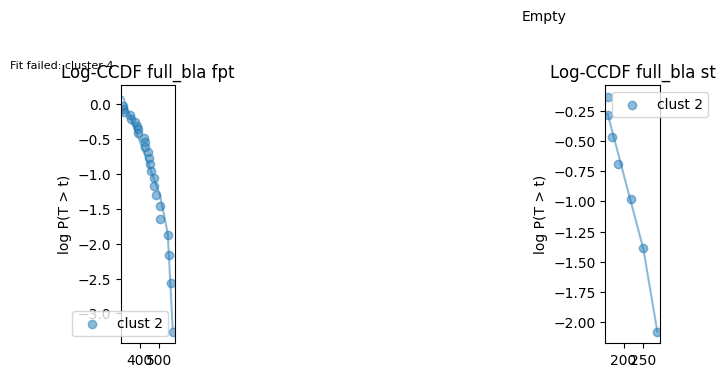

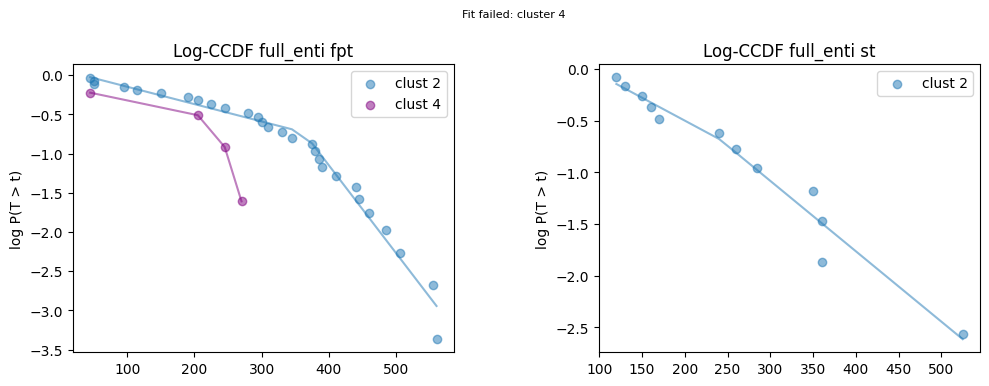

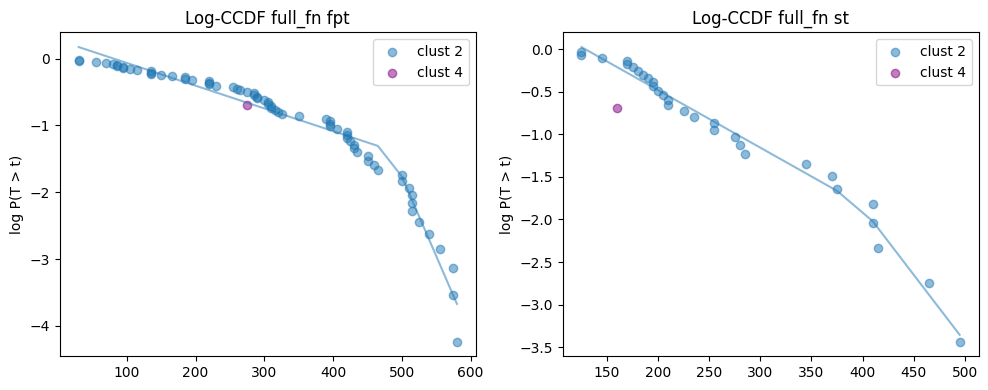

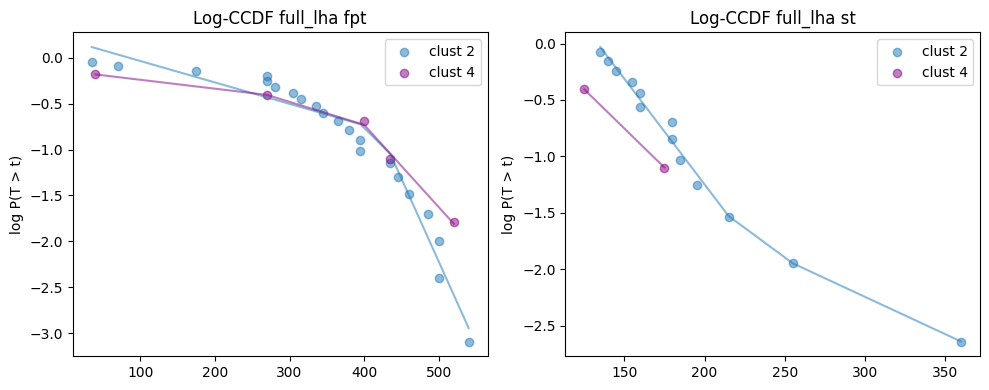

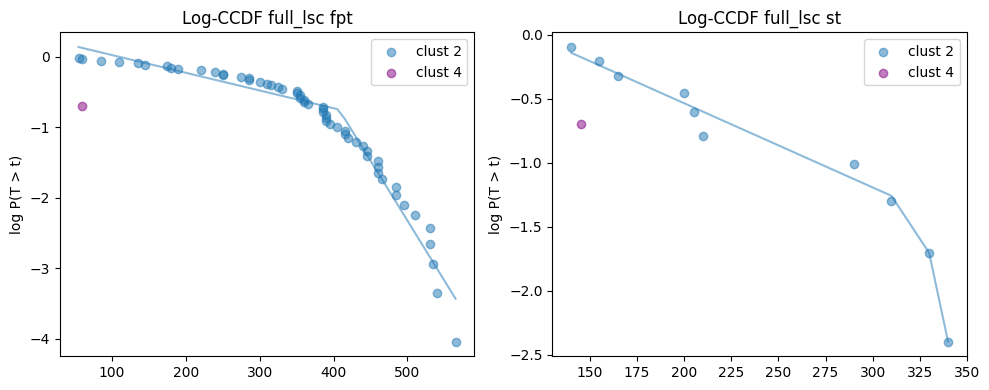

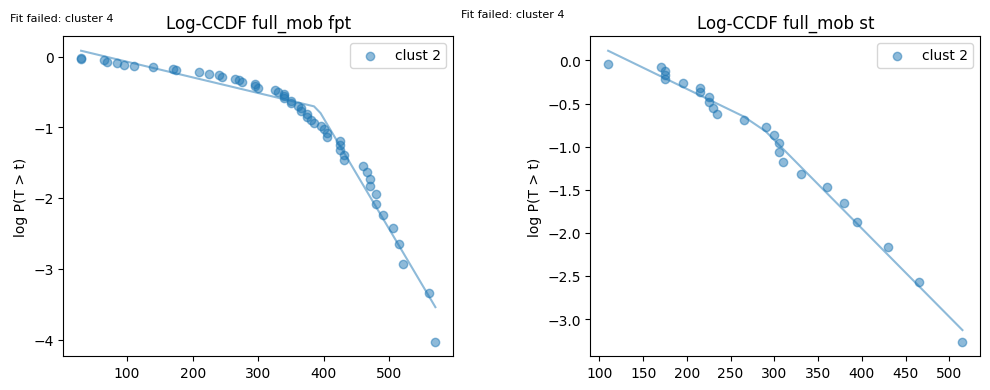

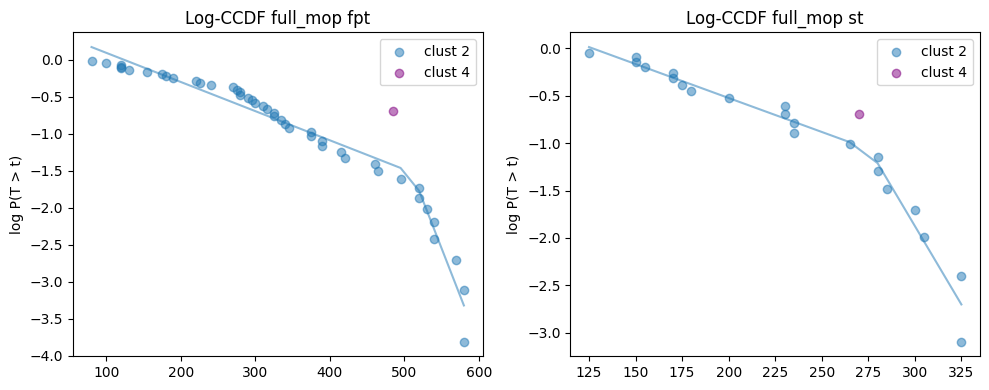

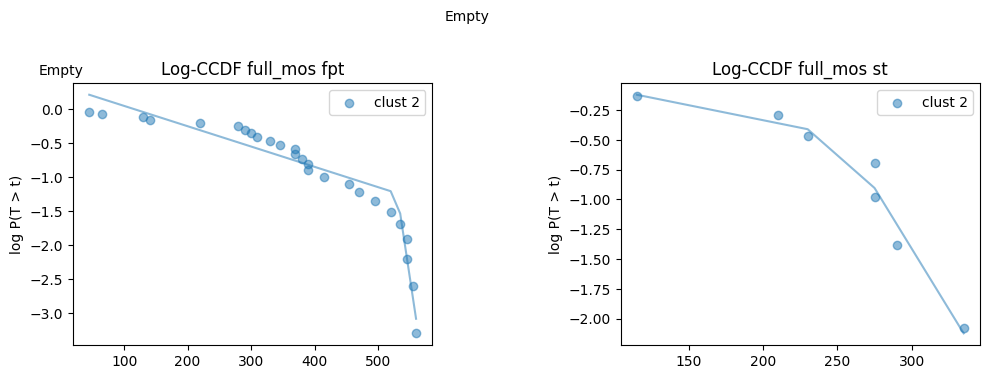

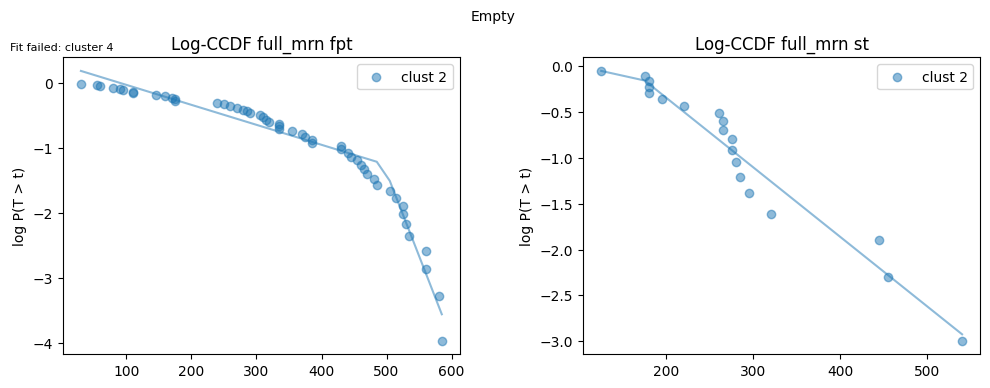

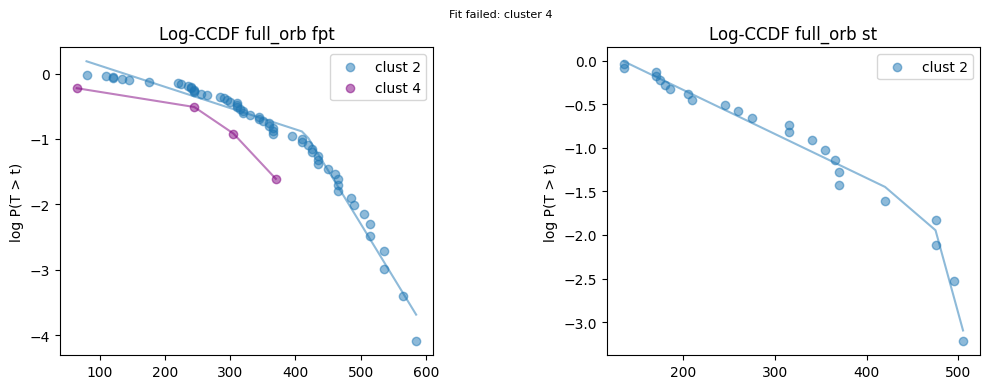

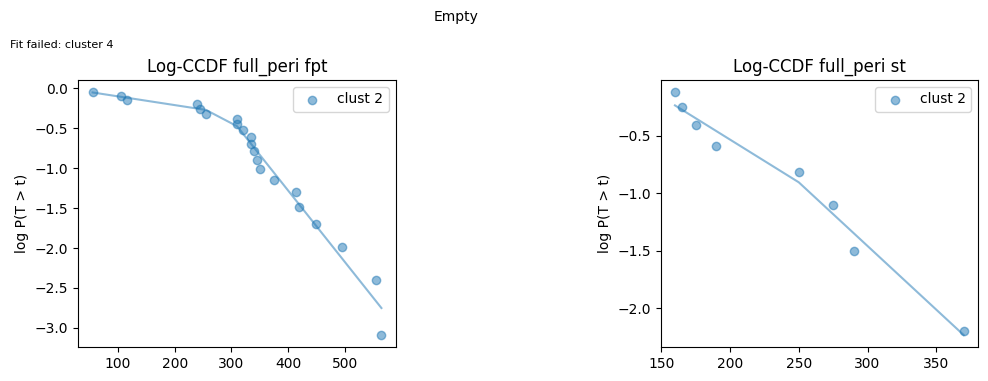

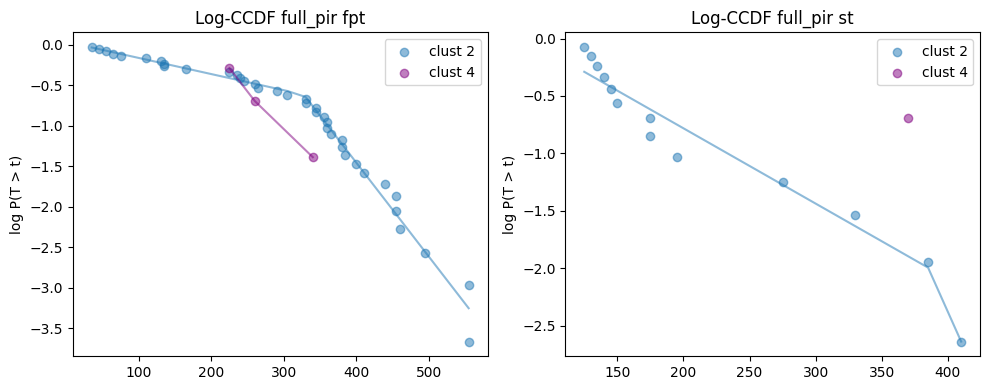

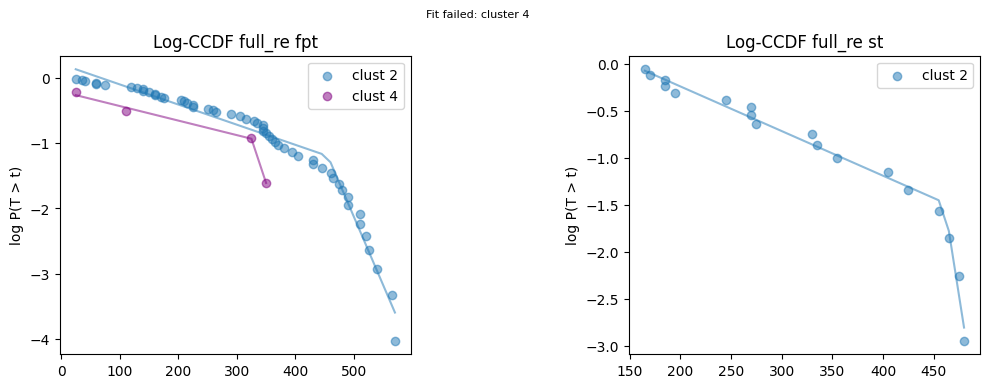

In [9]:
for f_full, f_part in zip(file_full,file_part):
    # print(f"full_{f_full.split('_')[-1]}")
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    plot_fit(pkl_full,f"full_{f_full.split('_')[-1]}")

    # with open(f_part, "rb") as f:
    #     pkl_part = pickle.load(f)

    # plot_fit(pkl_part,f"part_{f_part.split('_')[-1]}")

    print(f"full_{f_full.split('_')[-1]}")

#### Calculate the mean median of params clusterwise

In [ ]:
# read data
data_folder = Path('../../data/results/comm_umap_results/comm_wise_params')
file_full = glob.glob(str(data_folder/'full_*'))
file_part = glob.glob(str(data_folder/'part_*'))

In [ ]:
d_fn=reader.data_read_pkl('results\\comm_umap_results\\comm_wise_params\\part_enti')
d_fn.keys()

dict_keys([0, 4, 3, 1, 2])

In [ ]:
# function to calculate medians for a given cluster
def cal_med(clus_data):
    med=[]
    for p in clus_data.keys():
        md=np.median(clus_data[p])
        med.append(md)
        
    return med

In [ ]:
# take each cluster
def compute_clu_params(data):
    """
    Compute the median of clusterwise params

    Args:
        data (dictionary): Contains clusterwise params
    Return:
        dictionary: median for each cluster and cluster itself
    """
    fpt,st,cov,tt=[],[],[],[]
    cluster=[]
    for c in data.keys():
        cluster.append(c)
        med=cal_med(data[c])

        fpt.append(med[0])
        st.append(med[1])
        cov.append(med[2])
        tt.append(med[3])

    return {'cluster':cluster,'fpt':fpt,'st':st,'cov':cov,'tt':tt}

    


In [ ]:
compute_clu_params(d_fn)

{'cluster': [0, 4, 3, 1, 2],
 'fpt': [562.5, 397.5, 112.5, 630.0, 365.0],
 'st': [80.0, 80.0, 85.0, 75.0, 115.0],
 'cov': [0.1437029706221089,
  0.21608372544262877,
  0.0020277364863813823,
  0.21667366507473962,
  0.3220702731835921],
 'tt': [49.35,
  52.925000000000004,
  53.25,
  52.275000000000006,
  58.050000000000004]}

In [ ]:
l=compute_clu_params(d_fn)
df=pd.DataFrame(l)
df

,cluster,fpt,st,cov,tt
0,0,562.5,80.0,0.143703,49.350
1,4,397.5,80.0,0.216084,52.925
2,3,112.5,85.0,0.002028,53.250
3,1,630.0,75.0,0.216674,52.275
4,2,365.0,115.0,0.322070,58.050


In [ ]:
# Sort by cluster column
df_sorted = df.sort_values(by="cluster")

print(df_sorted)


   cluster    fpt     st       cov      tt
0        0  562.5   80.0  0.143703  49.350
3        1  630.0   75.0  0.216674  52.275
4        2  365.0  115.0  0.322070  58.050
2        3  112.5   85.0  0.002028  53.250
1        4  397.5   80.0  0.216084  52.925


In [ ]:
df=pd.DataFrame(l)
for c in l['cluster']:
    print(c)
    
    
clus2=df.loc[0].to_frame().T
clus2

# clus4=df.loc[1].to_frame().T
# df_dum = pd.DataFrame()
# df_=pd.concat([df_dum,clus2])
# df_dum


,cluster,fpt,st,cov,tt
0,0.0,562.5,80.0,0.143703,49.35


In [ ]:
file_full[1]

'..\\..\\data\\results\\comm_umap_results\\comm_wise_params\\full_enti'

Reading data of all networks

Plot cluster 2 and 4 full transition parameters 
- Taken mean of medians across all networks

In [ ]:
df_c2 = pd.DataFrame()
df_c4= pd.DataFrame()

# first doing for full transition files
for f in file_full:
    with open(f, "rb") as full:
        pkl = pickle.load(full)
    # compute clusterwise median params
    l = compute_clu_params(pkl)
    # store them separately in cluster
    df = pd.DataFrame(l)
    df_l = df.sort_values(by="cluster")
    clus2 = df_l.iloc[0].to_frame().T
    df_c2 = pd.concat([df_c2,clus2],ignore_index=True)

    clus4 = df_l.iloc[1].to_frame().T
    df_c4 = pd.concat([df_c4,clus4],ignore_index=True)



    

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: 

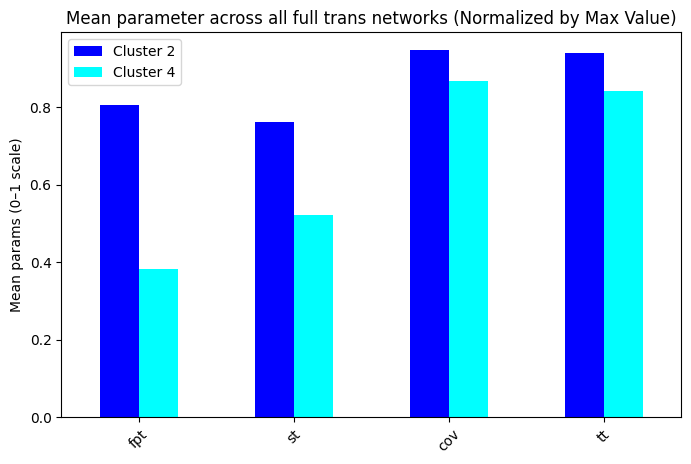

In [ ]:
import matplotlib.pyplot as plt

all_df = [df_c2, df_c4]
colors = ['blue', 'cyan']
labels = ['Cluster 2', 'Cluster 4']

# Collect means for each cluster
means_list = []
for df in all_df:
    df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()
    means_list.append(df_norm.mean())

# Combine into one DataFrame for plotting
means_df = pd.DataFrame(means_list, index=labels).T

# Plot grouped bar chart
means_df.plot(kind='bar', figsize=(8,5), color=colors)

plt.title("Mean parameter across all full trans networks (Normalized by Max Value)")
plt.ylabel("Mean params (0–1 scale)")
plt.xticks(rotation=45)
# plt.legend(title="Clusters")
plt.show()


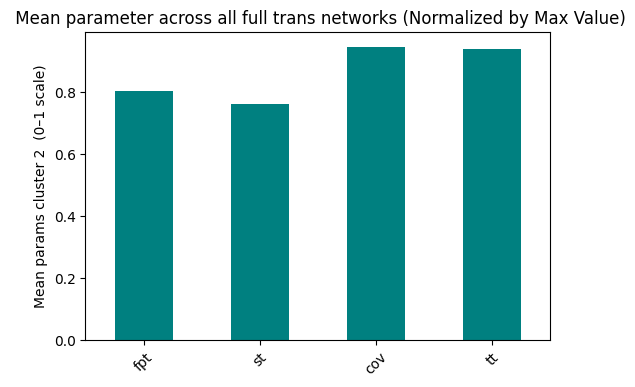

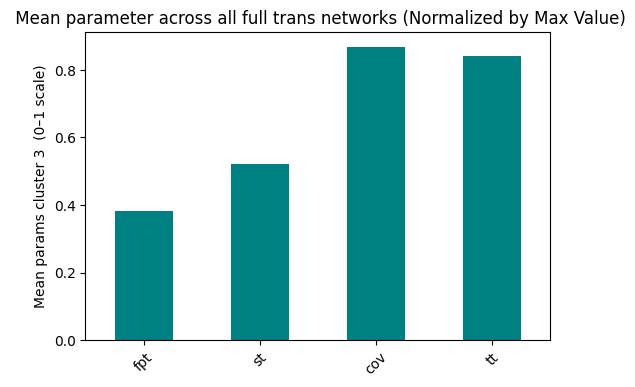

In [ ]:
all_df = [df_c2,df_c4]
for n,df in enumerate(all_df):
    # Drop cluster column if you don't want it included
    df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()

    # Compute mean of normalized columns
    means = df_norm.mean()

    # Plot bar chart
    plt.figure(figsize=(6,4))
    means.plot(kind='bar', color='teal')

    plt.title(" Mean parameter across all full trans networks (Normalized by Max Value)")
    plt.ylabel(f"Mean params cluster {n+2}  (0–1 scale)")
    plt.xticks(rotation=45)
    plt.show()



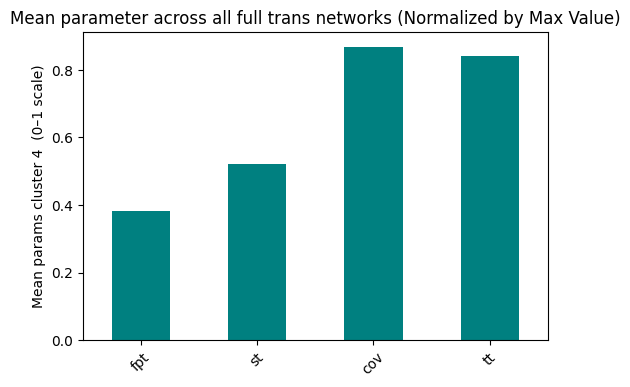

In [ ]:
df=df_c4.copy()
# Drop cluster column if you don't want it included
df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()

# Compute mean of normalized columns
means = df_norm.mean()

# Plot bar chart
plt.figure(figsize=(6,4))
means.plot(kind='bar', color='teal')

plt.title("Mean parameter across all full trans networks (Normalized by Max Value)")
plt.ylabel("Mean params cluster 4  (0–1 scale)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_c0 = pd.DataFrame()
df_c1 = pd.DataFrame()
df_c2 = pd.DataFrame()
df_c3= pd.DataFrame()
df_c4 = pd.DataFrame()

# first doing for full transition files
for f in file_part:
    with open(f, "rb") as part:
        pkl = pickle.load(part)
    # compute clusterwise median params
    l = compute_clu_params(pkl)
    # store them separately in cluster
    df = pd.DataFrame(l)
    df_l = df.sort_values(by="cluster")

    clus0 = df_l.iloc[0].to_frame().T
    df_c0= pd.concat([df_c0,clus0],ignore_index=True)

    clus1 = df_l.iloc[1].to_frame().T
    df_c1 = pd.concat([df_c1,clus1],ignore_index=True)

    clus2 = df_l.iloc[2].to_frame().T
    df_c2 = pd.concat([df_c2,clus2],ignore_index=True)

    clus3 = df_l.iloc[3].to_frame().T
    df_c3 = pd.concat([df_c3,clus3],ignore_index=True)

    clus4 = df_l.iloc[4].to_frame().T
    df_c4 = pd.concat([df_c4,clus4],ignore_index=True)


In [ ]:
df_c0

,cluster,fpt,st,cov,tt
0,0.0,410.0,75.0,0.139014,48.55
1,0.0,562.5,80.0,0.143703,49.35
2,0.0,415.0,85.0,0.133485,50.65
3,0.0,430.0,75.0,0.142664,49.40
4,0.0,300.0,80.0,0.143324,50.55
5,0.0,485.0,77.5,0.137608,51.35
6,0.0,307.5,87.5,0.128970,52.70
7,0.0,270.0,80.0,0.133412,49.50
8,0.0,425.0,85.0,0.138557,53.20
9,0.0,380.0,85.0,0.135239,49.65


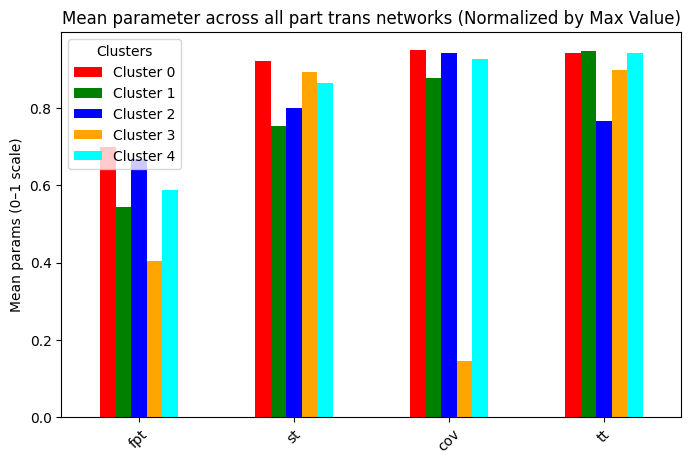

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

colors = {0: "red", 1: "green", 2: "blue", 3: "orange", 4: "cyan"}
all_df = [df_c0, df_c1, df_c2, df_c3, df_c4]

# Collect means for each cluster
means_list = []
labels = []
for n, df in enumerate(all_df):
    df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()
    means_list.append(df_norm.mean())
    labels.append(f"Cluster {n}")

# Combine into one DataFrame
means_df = pd.DataFrame(means_list, index=labels).T

# Plot grouped bar chart with custom colors
cluster_colors = [colors[i] for i in range(len(all_df))]
means_df.plot(kind='bar', figsize=(8,5), color=cluster_colors)

plt.title("Mean parameter across all part trans networks (Normalized by Max Value)")
plt.ylabel("Mean params (0–1 scale)")
plt.xticks(rotation=45)
plt.legend(title="Clusters")
plt.show()


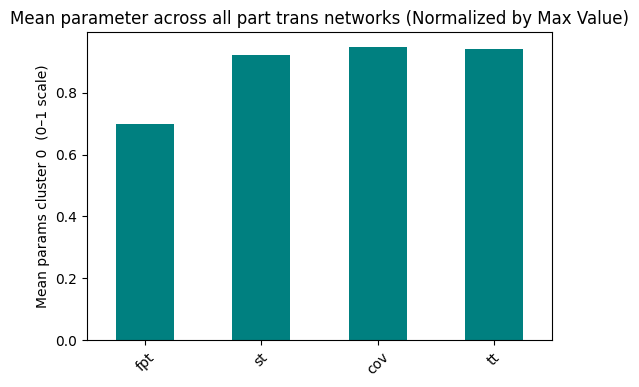

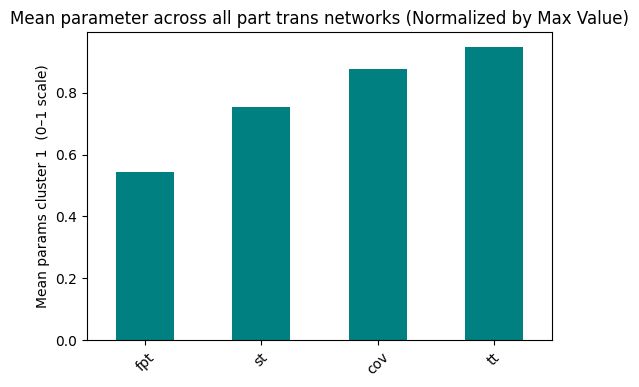

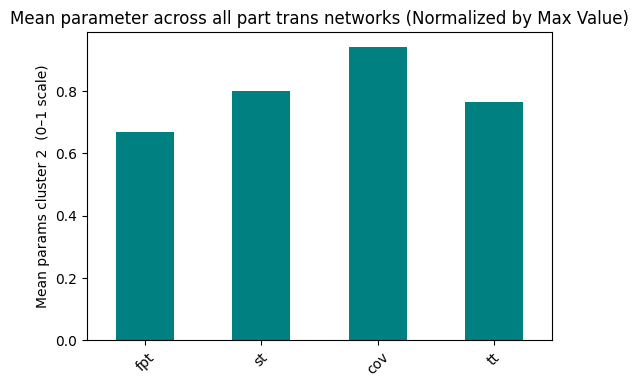

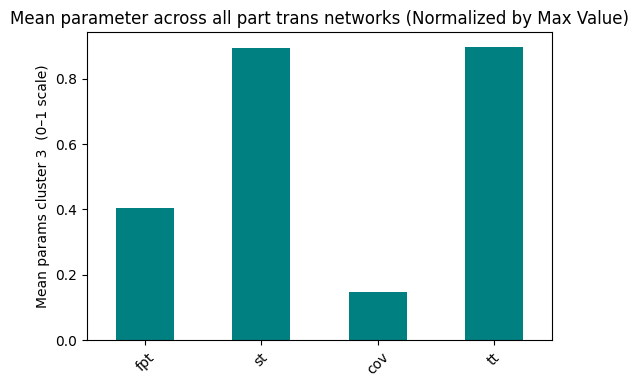

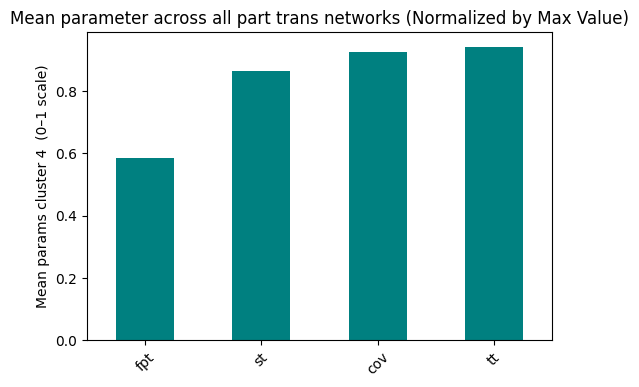

In [ ]:
all_df = [df_c0,df_c1,df_c2,df_c3,df_c4]
# Plot bar chart
plt.figure(figsize=(6,4))
for n,df in enumerate(all_df):
# Drop cluster column if you don't want it included
    df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()

    # Compute mean of normalized columns
    means = df_norm.mean()

    
    means.plot(kind='bar', color='teal')

    plt.title("Mean parameter across all part trans networks (Normalized by Max Value)")
    plt.ylabel(f"Mean params cluster {n}  (0–1 scale)")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
df=df_c0.copy()
# Drop cluster column if you don't want it included
df_norm = df.drop(columns=['cluster']) / df.drop(columns=['cluster']).max()

# Compute mean of normalized columns
means = df_norm.mean()

# Plot bar chart
plt.figure(figsize=(6,4))
means.plot(kind='bar', color='teal')

plt.title("Mean parameter across all part trans networks (Normalized by Max Value)")
plt.ylabel("Mean params cluster 0  (0–1 scale)")
plt.xticks(rotation=45)
plt.show()